# **Projeto Final MBA em Ciência de Dados e IA (Sprint 18)**
por Ana Paula Takezawa

### **Predição do Risco de Incêndios Florestais no Brasil utilizando Machine Learning**


## **1. Introdução**

Os incêndios florestais representam um importante desafio ambiental, econômico e social no Brasil. A ocorrência de queimadas está diretamente relacionada a fatores climáticos, características do solo e condições ambientais, tornando sua previsão uma ferramenta estratégica para órgãos públicos e instituições responsáveis pelo monitoramento e prevenção desses eventos.

Neste projeto será desenvolvida uma solução de Machine Learning capaz de estimar o nível de risco de incêndios para diferentes regiões e períodos, utilizando dados públicos disponibilizados pela TripleTen e provenientes da plataforma Base dos Dados.

## **2. Objetivo do Projeto**

O objetivo deste projeto é desenvolver uma pipeline completa de Ciência de Dados para prever o risco de incêndios florestais utilizando informações sobre queimadas, condições meteorológicas e uso do solo.

Ao longo do projeto serão realizadas as seguintes etapas:

- compreensão do problema de negócio;
- exploração e preparação dos dados;
- integração das bases de dados;
- treinamento e comparação de modelos de Machine Learning;
- otimização do modelo;
- análise de explicabilidade;
- avaliação dos resultados sob a perspectiva técnica e de negócio.


## **3. Problema de Negócio**

A previsão antecipada do risco de incêndios permite que órgãos ambientais direcionem recursos de forma mais eficiente, priorizem ações preventivas e reduzam impactos ambientais e econômicos.

Neste contexto, o modelo desenvolvido buscará classificar o risco de incêndio para uma determinada região com base em características ambientais e meteorológicas.

## **4. Indicadores de Desempenho (KPIs)**



Para avaliar o desempenho dos modelos de Machine Learning foram definidos indicadores técnicos de classificação. Como a variável-alvo apresenta distribuição desigual entre as classes, o **F1-score ponderado (Weighted F1-score)** foi adotado como principal indicador de desempenho, por representar o equilíbrio entre precisão e recall considerando a proporção de cada classe.

Além do F1-score, também foram utilizadas as seguintes métricas:

- **Acurácia:** percentual de classificações corretas realizadas pelo modelo;
- **Precisão:** capacidade do modelo de evitar classificações incorretas;
- **Recall (Sensibilidade):** capacidade de identificar corretamente cada classe;
- **F1-score:** média harmônica entre precisão e recall, utilizada como principal critério para comparação dos modelos e seleção da melhor solução.

Esses indicadores foram empregados durante todas as etapas de treinamento, comparação e otimização dos modelos.

## **5. Bases de dados**

Serão utilizadas quatro bases disponibilizadas pela TripleTen:

- Banco de Dados de Queimadas
- MapBiomas
- Cadastro de Estações Meteorológicas
- Medições Meteorológicas

Essas bases serão consolidadas para formar um conjunto de dados único, utilizado no treinamento dos modelos de Machine Learning.


## **6. Tecnologias utilizadas**

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-Learn
- Optuna
- SHAP

## **7. Instalação das Dependências**

Antes de iniciar o desenvolvimento do projeto, é necessário garantir que todas as bibliotecas utilizadas estejam disponíveis no ambiente de execução. Nesta etapa são instaladas as dependências que serão empregadas ao longo das diferentes fases do projeto, incluindo análise exploratória dos dados, modelagem preditiva, otimização de hiperparâmetros e explicabilidade do modelo. Essa prática contribui para a reprodutibilidade do projeto e facilita sua execução em outros ambientes.

In [2]:
# Instalação das bibliotecas necessárias
!pip install -q optuna
!pip install -q shap
!pip install -q lightgbm
!pip install -q xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 10.2 MB/s eta 0:00:00


## **8. Carregamento das Bases de Dados e Importação das bibliotecas**

Nesta etapa são carregadas as quatro bases de dados que servirão de suporte para o desenvolvimento do modelo de Machine Learning. Cada uma delas contribui com informações complementares sobre ocorrências de queimadas, condições meteorológicas, localização das estações e características do uso e cobertura do solo. A integração dessas bases permitirá construir um conjunto de dados mais completo para a previsão do risco de incêndios florestais.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import pandas as pd

# Banco de dados de queimadas
queimadas = pd.read_csv(
    "/content/drive/MyDrive/Projeto_Final_MBA/data/queimadas_2024_2025.csv",
    sep=";"
)

**Base de Queimadas**

Esta é a base principal do projeto e contém os registros de focos de calor detectados por satélites, incluindo informações sobre localização, data, bioma, precipitação, dias sem chuva e indicadores relacionados ao risco de fogo. Esses dados servirão como referência para a definição da variável alvo e para a construção do modelo preditivo.

In [5]:
# Banco de dados meteorológico
meteorologia = pd.read_csv(
    "/content/drive/MyDrive/Projeto_Final_MBA/data/BDMEP-2025.csv"
)

**Base Meteorológica**

Esta base reúne medições meteorológicas realizadas pelas estações do INMET, contendo variáveis climáticas como temperatura, umidade relativa do ar, precipitação, pressão atmosférica, radiação solar e velocidade do vento. Essas informações representam fatores ambientais que podem influenciar diretamente a ocorrência de incêndios.

In [6]:
# Banco de dados MapBiomas
mapbiomas = pd.read_csv(
    "/content/drive/MyDrive/Projeto_Final_MBA/data/MapBiomas.csv"
)

**Base MapBiomas**

Esta base apresenta informações sobre o uso e a cobertura do solo nos municípios brasileiros, permitindo identificar características ambientais que podem influenciar o comportamento e o risco de propagação de incêndios florestais.

In [7]:
# Banco de dados das estações meteorológicas
estacoes = pd.read_csv(
    "/content/drive/MyDrive/Projeto_Final_MBA/data/BDMEP-estacao.csv"
)

**Base das Estações Meteorológicas**

Esta base contém o cadastro das estações meteorológicas, incluindo sua localização geográfica, altitude e município correspondente. Ela será utilizada para relacionar as medições meteorológicas às respectivas regiões analisadas no estudo.

In [8]:
# Manipulação de dados
import numpy as np

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações
import warnings
warnings.filterwarnings("ignore")

# Estatística
from scipy import stats

# Pré-processamento
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Métricas
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Modelos de Machine Learning
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

# Gradient Boosting
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Otimização (será utilizada na Etapa 3)
import optuna

# Explicabilidade (será utilizada na Etapa 3)
import shap

# Data e hora e barra de progresso
from datetime import datetime
from tqdm import tqdm

In [9]:
# Configuração dos gráficos
plt.style.use("default")
sns.set_theme(style="whitegrid")

%matplotlib inline

## **9. Configuração do Ambiente**





Nesta seção são definidas configurações que serão utilizadas durante todo o projeto, garantindo padronização dos gráficos, melhor visualização dos dados e reprodutibilidade dos resultados.

In [10]:
# Configuração dos gráficos
plt.style.use("default")
sns.set_theme(style="whitegrid")

# Exibir gráficos no notebook
%matplotlib inline

# Configuração padrão das figuras
plt.rcParams["figure.figsize"] = (10, 6)

# Exibir todas as colunas quando necessário
pd.set_option("display.max_columns", None)

# Limite de linhas exibidas
pd.set_option("display.max_rows", 100)

# Formatação de números
pd.options.display.float_format = "{:.2f}".format

# Reprodutibilidade
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## **10. Conhecimento Inicial das Bases de Dados**

Nesta etapa será realizada uma inspeção inicial das bases de dados utilizadas no projeto. O objetivo é compreender sua estrutura, identificar o número de registros e variáveis, verificar os tipos de dados, detectar possíveis inconsistências e obter uma visão geral da qualidade das informações disponíveis. Esse primeiro contato é fundamental para orientar as etapas de limpeza, integração e preparação dos dados para a modelagem.

### **10.1 Base de Queimadas**

In [11]:
queimadas.head()

queimadas.info()

queimadas.describe(include="all")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8226944 entries, 0 to 8226943
Data columns (total 15 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   ano                      int64  
 1   mes                      int64  
 2   data_hora                object 
 3   bioma                    object 
 4   sigla_uf                 object 
 5   sigla_uf_nome            object 
 6   id_municipio             int64  
 7   id_municipio_nome        object 
 8   latitude                 float64
 9   longitude                float64
 10  satelite                 object 
 11  dias_sem_chuva           float64
 12  precipitacao             float64
 13  risco_fogo               float64
 14  potencia_radiativa_fogo  float64
dtypes: float64(6), int64(3), object(6)
memory usage: 941.5+ MB


,ano,mes,data_hora,bioma,sigla_uf,sigla_uf_nome,id_municipio,id_municipio_nome,latitude,longitude,satelite,dias_sem_chuva,precipitacao,risco_fogo,potencia_radiativa_fogo
count,8226944.00,8226944.00,8226944,8226943,8226944,8226944,8226944.00,8226944,8226944.00,8226944.00,8226944,8114274.00,8114274.00,8114274.00,7886220.00
unique,NaN,NaN,531163,6,27,27,NaN,5245,NaN,NaN,12,NaN,NaN,NaN,NaN
top,NaN,NaN,2024-09-06 04:57:00,Amazônia,PA,Pará,NaN,São Félix do Xingu,NaN,NaN,NOAA-20,NaN,NaN,NaN,NaN
freq,NaN,NaN,14513,4457826,1830663,1830663,NaN,267515,NaN,NaN,1983819,NaN,NaN,NaN,NaN
mean,2024.01,8.28,NaN,NaN,NaN,NaN,2779643.98,NaN,-10.05,-53.36,NaN,29.46,0.45,-10.21,33.95
std,0.10,2.17,NaN,NaN,NaN,NaN,1584145.81,NaN,5.99,6.96,NaN,99.78,2.63,104.59,64.43
min,2024.00,1.00,NaN,NaN,NaN,NaN,1100015.00,NaN,-33.72,-73.72,NaN,-999.00,0.00,-999.00,-3.80
25%,2024.00,8.00,NaN,NaN,NaN,NaN,1503101.00,NaN,-13.86,-57.77,NaN,6.00,0.00,0.82,3.40
50%,2024.00,9.00,NaN,NaN,NaN,NaN,2102705.00,NaN,-9.16,-53.56,NaN,20.00,0.00,1.00,9.10
75%,2024.00,9.00,NaN,NaN,NaN,NaN,5003488.00,NaN,-6.48,-48.15,NaN,63.00,0.00,1.00,43.80


**Interpretação dos resultados**

A base de queimadas é composta por 8.226.944 registros distribuídos em 15 variáveis, representando informações sobre ocorrências de focos de calor em diferentes regiões do Brasil entre os anos de 2024 e 2025. A estrutura dos dados apresenta variáveis numéricas e categóricas relacionadas à localização geográfica, condições meteorológicas e características dos incêndios.

A inspeção inicial revelou alguns pontos que serão tratados nas próximas etapas do projeto. A variável data_hora encontra-se no formato object e deverá ser convertida para o tipo datetime. Além disso, foram identificados valores ausentes em variáveis importantes, como dias_sem_chuva, precipitacao, risco_fogo e potencia_radiativa_fogo, que serão analisados durante o processo de limpeza dos dados.

Também foi observado que algumas variáveis apresentam o valor -999, indicando um possível código utilizado para representar dados indisponíveis ou inválidos. Essa hipótese será investigada antes da etapa de modelagem para garantir a qualidade da base utilizada no treinamento dos modelos.

### **10.2 Base Meteorológica (BDMEP-2025)**

In [12]:
meteorologia.head()

meteorologia.info()

meteorologia.describe(include="all")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4891176 entries, 0 to 4891175
Data columns (total 21 columns):
 #   Column                    Dtype  
---  ------                    -----  
 0   ano                       int64  
 1   data                      object 
 2   hora                      object 
 3   id_estacao                object 
 4   precipitacao_total        float64
 5   pressao_atm_hora          float64
 6   pressao_atm_max           float64
 7   pressao_atm_min           float64
 8   radiacao_global           float64
 9   temperatura_bulbo_hora    float64
 10  temperatura_orvalho_hora  float64
 11  temperatura_max           float64
 12  temperatura_min           float64
 13  temperatura_orvalho_max   float64
 14  temperatura_orvalho_min   float64
 15  umidade_rel_max           float64
 16  umidade_rel_min           float64
 17  umidade_rel_hora          float64
 18  vento_direcao             float64
 19  vento_rajada_max          float64
 20  vento_velocidade        

,ano,data,hora,id_estacao,precipitacao_total,pressao_atm_hora,pressao_atm_max,pressao_atm_min,radiacao_global,temperatura_bulbo_hora,temperatura_orvalho_hora,temperatura_max,temperatura_min,temperatura_orvalho_max,temperatura_orvalho_min,umidade_rel_max,umidade_rel_min,umidade_rel_hora,vento_direcao,vento_rajada_max,vento_velocidade
count,4891176.00,4891176,4891176,4891176,3025727.00,3583473.00,3577968.00,3577616.00,2191198.00,3546397.00,3252689.00,3539566.00,3539534.00,3241745.00,3240283.00,3264847.00,3267467.00,3276803.00,3268680.00,3256632.00,3264283.00
unique,NaN,181,24,567,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,2025-05-29,13:00:00,A706,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,27144,203799,8688,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,2025.00,NaN,NaN,NaN,0.18,963.77,964.03,963.46,1190.19,23.63,18.59,24.28,23.01,19.14,18.05,78.45,72.60,75.59,156.25,4.41,1.68
std,0.00,NaN,NaN,NaN,1.41,37.68,37.71,37.67,1125.17,5.27,4.20,5.42,5.11,4.19,4.23,16.90,18.84,17.97,98.07,2.76,1.44
min,2025.00,NaN,NaN,NaN,0.00,821.50,821.80,821.50,0.00,-7.70,-18.00,-7.30,-7.80,-16.10,-19.40,7.00,7.00,7.00,1.00,0.00,0.00
25%,2025.00,NaN,NaN,NaN,0.00,936.60,936.90,936.30,89.60,20.60,16.20,21.10,20.10,16.80,15.70,67.00,59.00,63.00,78.00,2.30,0.60
50%,2025.00,NaN,NaN,NaN,0.00,967.00,967.30,966.70,914.30,23.80,19.30,24.30,23.30,19.80,18.70,82.00,76.00,79.00,135.00,4.10,1.40
75%,2025.00,NaN,NaN,NaN,0.00,995.90,996.20,995.60,2101.30,27.10,21.70,28.00,26.30,22.20,21.20,92.00,89.00,91.00,233.00,6.10,2.50


**Interpretação dos resultados**

A base meteorológica é composta por 4.891.176 registros e 21 variáveis, contendo medições horárias provenientes de 567 estações meteorológicas distribuídas pelo território brasileiro. As informações incluem variáveis climáticas relevantes, como temperatura, precipitação, umidade relativa, pressão atmosférica, radiação solar e velocidade do vento, que representam fatores importantes para a previsão do risco de incêndios florestais.

A análise inicial mostrou que as variáveis data e hora encontram-se armazenadas como texto (object) e deverão ser convertidas para formatos apropriados durante a etapa de preparação dos dados. Também foram identificados valores ausentes em diversas variáveis meteorológicas, especialmente em radiacao_global, precipitacao_total e variáveis relacionadas à umidade e ao vento, indicando a necessidade de tratamento antes da construção dos modelos de Machine Learning.

De modo geral, a base apresenta boa diversidade de informações climáticas e tende a contribuir significativamente para o enriquecimento da base consolidada utilizada na modelagem.

### **10.3 Base das Estações Meteorológicas (BDMEP-estacao)**

In [13]:
estacoes.head()

estacoes.info()

estacoes.describe(include="all")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 612 entries, 0 to 611
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id_municipio       610 non-null    float64
 1   id_municipio_nome  610 non-null    object 
 2   id_estacao         612 non-null    object 
 3   estacao            612 non-null    object 
 4   data_fundacao      612 non-null    object 
 5   latitude           612 non-null    float64
 6   longitude          612 non-null    float64
 7   altitude           595 non-null    float64
dtypes: float64(4), object(4)
memory usage: 38.4+ KB


,id_municipio,id_municipio_nome,id_estacao,estacao,data_fundacao,latitude,longitude,altitude
count,610.00,610,612,612,612,612.00,612.00,595.00
unique,NaN,585,612,609,487,NaN,NaN,NaN
top,NaN,Brasília,A338,Valenca,2016-12-01,NaN,NaN,NaN
freq,NaN,5,1,2,17,NaN,NaN,NaN
mean,3282992.10,NaN,NaN,NaN,NaN,-15.71,-48.40,417.52
std,1226355.09,NaN,NaN,NaN,NaN,8.75,7.37,345.55
min,1100023.00,NaN,NaN,NaN,NaN,-84.00,-79.49,1.00
25%,2307207.50,NaN,NaN,NaN,NaN,-22.25,-52.94,131.06
50%,3156956.50,NaN,NaN,NaN,NaN,-16.12,-48.23,365.79
75%,4303830.75,NaN,NaN,NaN,NaN,-8.65,-42.79,629.44


**Interpretação dos resultados**

A base das estações meteorológicas é composta por 612 registros e 8 variáveis, contendo informações cadastrais das estações utilizadas para a coleta das medições climáticas. Entre os atributos disponíveis estão o identificador da estação, município de localização, coordenadas geográficas, altitude e data de fundação.

A inspeção inicial mostrou que a base apresenta boa qualidade, com poucos valores ausentes concentrados nas variáveis id_municipio e altitude. Também foi identificado que a variável data_fundacao encontra-se armazenada como texto (object), sendo necessária sua conversão para o tipo datetime durante a etapa de preparação dos dados.

Essa base desempenhará um papel importante na integração das informações meteorológicas, permitindo relacionar cada medição climática à sua respectiva estação e localização geográfica.

### **10.4 Base MapBiomas**

In [14]:
mapbiomas.head()

mapbiomas.info()

mapbiomas.describe(include="all")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2286656 entries, 0 to 2286655
Data columns (total 7 columns):
 #   Column             Dtype  
---  ------             -----  
 0   ano                int64  
 1   sigla_uf           object 
 2   sigla_uf_nome      object 
 3   id_municipio       int64  
 4   id_municipio_nome  object 
 5   id_classe          int64  
 6   area               float64
dtypes: float64(1), int64(3), object(3)
memory usage: 122.1+ MB


,ano,sigla_uf,sigla_uf_nome,id_municipio,id_municipio_nome,id_classe,area
count,2286656.00,2286656,2286656,2286656.00,2286656,2286656.00,2286656.00
unique,NaN,27,27,NaN,5294,NaN,NaN
top,NaN,MG,Minas Gerais,NaN,São Domingos,NaN,NaN
freq,NaN,385610,385610,NaN,1832,NaN,NaN
mean,2003.43,NaN,NaN,3324157.11,NaN,21.26,137.43
std,10.68,NaN,NaN,966804.56,NaN,13.45,1561.97
min,1985.00,NaN,NaN,1100015.00,NaN,0.00,0.00
25%,1994.00,NaN,NaN,2612505.00,NaN,11.00,0.37
50%,2004.00,NaN,NaN,3162609.00,NaN,21.00,3.97
75%,2013.00,NaN,NaN,4123204.00,NaN,33.00,40.54


**Interpretação dos resultados**

A base MapBiomas é composta por 2.286.656 registros e 7 variáveis, contendo informações históricas sobre o uso e a cobertura do solo nos municípios brasileiros entre os anos de 1985 e 2021. Os dados abrangem todas as unidades federativas e praticamente todos os municípios do país, oferecendo uma importante caracterização ambiental das regiões analisadas.

A inspeção inicial mostrou que a base apresenta excelente qualidade estrutural, sem registros de valores ausentes nas variáveis disponíveis. Além disso, a variável id_classe representa diferentes categorias de uso e cobertura do solo, enquanto a variável area quantifica a extensão territorial correspondente a cada classe. Essas informações poderão contribuir para enriquecer o conjunto de dados utilizado na modelagem do risco de incêndios florestais.

### **10.5 Teste de Hipótese Estatístico**

### **10.5.1 Definição da Hipótese**



Como parte da análise exploratória, foi realizado um teste de hipótese estatístico para verificar se existe associação entre o número de dias sem chuva e o índice de risco de incêndio (`risco_fogo`).

Foram definidas as seguintes hipóteses:

- **Hipótese nula (H₀):** não existe correlação estatisticamente significativa entre as variáveis `dias_sem_chuva` e `risco_fogo`.
- **Hipótese alternativa (H₁):** existe correlação estatisticamente significativa entre as variáveis `dias_sem_chuva` e `risco_fogo`.

Foi adotado um nível de significância de **5% (α = 0,05)**.

### **10.5.2 Aplicação do Teste**

In [23]:
print("=" * 70)
print("TESTE DE HIPÓTESE - CORRELAÇÃO DE SPEARMAN")
print("=" * 70)

# Seleciona apenas registros válidos
dados = queimadas[["dias_sem_chuva", "risco_fogo"]].dropna()

# Correlação
coeficiente, p_valor = spearmanr(
    dados["dias_sem_chuva"],
    dados["risco_fogo"]
)

print(f"Coeficiente de Spearman : {coeficiente:.4f}")
print(f"P-valor                : {p_valor:.6f}")

if p_valor < 0.05:
    print("\nResultado: Rejeitamos H₀.")
    print("Existe correlação estatisticamente significativa entre as variáveis.")
else:
    print("\nResultado: Não rejeitamos H₀.")
    print("Não foi encontrada correlação estatisticamente significativa.")

TESTE DE HIPÓTESE - CORRELAÇÃO DE SPEARMAN
Coeficiente de Spearman : 0.5495
P-valor                : 0.000000

Resultado: Rejeitamos H₀.
Existe correlação estatisticamente significativa entre as variáveis.


**Interpretação dos Resultados**

O teste de correlação de Spearman indicou um coeficiente de **0,5495**, evidenciando uma correlação positiva moderada entre o número de dias sem chuva e o índice de risco de incêndio (`risco_fogo`). Além disso, o p-valor obtido foi inferior ao nível de significância adotado (α = 0,05), permitindo rejeitar a hipótese nula.

Esses resultados indicam que existe uma associação estatisticamente significativa entre as variáveis analisadas, sugerindo que períodos mais prolongados sem precipitação tendem a estar associados ao aumento do risco de incêndios. Essa evidência reforça a relevância da variável `dias_sem_chuva`, posteriormente utilizada na construção do modelo preditivo.

## **11. Limpeza e Preparação dos Dados**

Após a inspeção inicial das quatro bases de dados, inicia-se a etapa de limpeza e preparação dos dados. O objetivo é identificar e corrigir inconsistências que possam comprometer a qualidade das análises e o desempenho dos modelos de Machine Learning.

Nesta etapa serão realizadas atividades como conversão de tipos de dados, identificação e tratamento de valores ausentes, verificação de registros duplicados, análise de inconsistências e padronização das informações. Ao final desse processo, as bases estarão preparadas para a etapa de integração e para a construção do conjunto de dados utilizado na modelagem preditiva.

### **11.1 Verificação das Dimensões e Estrutura das Bases**

Antes de iniciar o processo de limpeza dos dados, é importante verificar a estrutura geral das bases utilizadas no projeto. Nesta etapa serão conferidas as dimensões de cada conjunto de dados, bem como sua organização, permitindo confirmar se as informações foram carregadas corretamente e estabelecer uma referência para as próximas etapas de preparação e integração dos dados

In [33]:
# Verificação das dimensões das bases

print("Base de Queimadas:", queimadas.shape)
print("Base Meteorológica:", meteorologia.shape)
print("Base Estações:", estacoes.shape)
print("Base MapBiomas:", mapbiomas.shape)

Base de Queimadas: (8226944, 15)
Base Meteorológica: (4891176, 21)
Base Estações: (612, 8)
Base MapBiomas: (2286656, 7)


**Interpretação dos Resultados**

A verificação das dimensões confirma que as quatro bases de dados foram carregadas corretamente e estão disponíveis para as próximas etapas do projeto. A base de queimadas apresenta 8.226.944 registros e 15 variáveis, sendo a maior fonte de informações do estudo. A base meteorológica contém 4.891.176 registros e 21 variáveis, reunindo medições climáticas horárias provenientes de diversas estações. A base das estações meteorológicas possui 612 registros e 8 variáveis, funcionando como um cadastro das estações e de suas localizações. Por fim, a base MapBiomas apresenta 2.286.656 registros e 7 variáveis, contendo informações históricas sobre uso e cobertura do solo. As diferenças de tamanho entre as bases são esperadas devido às suas finalidades distintas e serão consideradas durante a etapa de integração dos dados.

### **11.2 Conversão dos Tipos de Dados**

Nesta etapa serão convertidas as variáveis que apresentam tipos incompatíveis com seu conteúdo. A conversão adequada dos tipos de dados é essencial para permitir análises temporais, facilitar a integração entre as bases e garantir o correto funcionamento dos algoritmos de Machine Learning. Todas as alterações realizadas serão justificadas com base na inspeção inicial das bases de dados.

### **11.2.1 Base de Queimadas**

In [34]:
# Conversão da variável de data e hora (ser datetime)
queimadas["data_hora"] = pd.to_datetime(queimadas["data_hora"])

In [35]:
queimadas["data_hora"].dtype

dtype('<M8[ns]')

In [36]:
# Verificação da conversão
print(queimadas["data_hora"].dtype)

queimadas[["data_hora"]].head()

datetime64[ns]


,data_hora
0,2024-09-13 04:29:00
1,2024-09-13 04:29:00
2,2024-09-13 04:29:00
3,2024-09-13 04:29:00
4,2024-09-13 04:29:00


A variável data_hora da base de queimadas foi convertida com sucesso do tipo object para datetime, preservando as informações de data e horário registradas em cada ocorrência. Essa conversão permitirá realizar análises temporais, filtros por período e futuras integrações com as demais bases de dados.

### **11.2.2 Base Meteorológica**

In [37]:
# Conversão da data
meteorologia["data"] = pd.to_datetime(meteorologia["data"])

# Conversão da hora
meteorologia["hora"] = pd.to_datetime(
    meteorologia["hora"],
    format="%H:%M:%S"
).dt.time

In [38]:
meteorologia[["data", "hora"]].dtypes

,0
data,datetime64[ns]
hora,object


In [39]:
# A coluna "hora" foi mantida no formato original, pois as medições
# serão avaliadas posteriormente durante a consolidação diária da base.
meteorologia["hora"].head(10)

,hora
0,13:00:00
1,16:00:00
2,18:00:00
3,16:00:00
4,19:00:00
5,18:00:00
6,17:00:00
7,17:00:00
8,18:00:00
9,21:00:00


A variável data da base meteorológica foi convertida para o tipo datetime, possibilitando análises temporais e futuras integrações com as demais bases do projeto. A coluna hora foi mantida temporariamente no formato original, uma vez que as medições meteorológicas poderão ser consolidadas por dia durante a etapa de integração dos dados, tornando essa informação menos relevante para a modelagem final.

### **11.2.3 Base das Estações**

In [40]:
# Conversão da data de fundação
estacoes["data_fundacao"] = pd.to_datetime(estacoes["data_fundacao"])

In [41]:
estacoes["data_fundacao"].dtype

dtype('<M8[ns]')

In [42]:
# Verificação da conversão
print(estacoes["data_fundacao"].dtype)

estacoes[["data_fundacao"]].head()

datetime64[ns]


,data_fundacao
0,2000-05-07
1,2017-07-19
2,2008-10-03
3,2014-10-01
4,2017-02-07


A variável data_fundacao da base das estações meteorológicas foi convertida para o tipo datetime, permitindo que informações relacionadas à data de implantação das estações possam ser utilizadas em futuras análises temporais, caso necessário. A conversão foi realizada com sucesso, preservando a integridade dos registros.

### **11.2.4 Base MapBiomas**

A base MapBiomas já apresenta os tipos de dados compatíveis com o conteúdo das variáveis, não sendo necessária a realização de conversões nesta etapa.

## **Conclusão da Etapa**

A etapa de conversão dos tipos de dados permitiu adequar as variáveis temporais das bases de queimadas, meteorológica e de estações meteorológicas aos formatos apropriados para análise. As conversões realizadas preservaram a integridade das informações e facilitarão operações envolvendo datas, filtros temporais e integração entre as bases. A base MapBiomas não necessitou de alterações, pois seus tipos de dados já estavam consistentes com a natureza das variáveis.

### **11.3 Identificação de Valores Ausentes**

Nesta etapa será realizada a identificação dos valores ausentes presentes nas bases de dados. Além da quantidade de registros faltantes, também será calculado o percentual de ausência em cada variável. Esse diagnóstico permitirá definir, nas próximas etapas, a estratégia mais adequada para tratamento dos dados, evitando perdas desnecessárias de informação e reduzindo possíveis impactos na modelagem.

### **11.3.1 Base de Queimadas**

In [43]:
# Valores ausentes na base de queimadas

print("=" * 60)
print("BASE DE QUEIMADAS")
print("=" * 60)

print(f"Total de registros: {len(queimadas):,}\n")

ausentes_queimadas = pd.DataFrame({
    "Valores Ausentes": queimadas.isnull().sum(),
    "Percentual (%)": (queimadas.isnull().mean() * 100).round(2)
})

ausentes_queimadas = ausentes_queimadas[
    ausentes_queimadas["Valores Ausentes"] > 0
].sort_values(by="Percentual (%)", ascending=False)

display(ausentes_queimadas)

BASE DE QUEIMADAS
Total de registros: 8,226,944



,Valores Ausentes,Percentual (%)
potencia_radiativa_fogo,340724,4.14
precipitacao,112670,1.37
dias_sem_chuva,112670,1.37
risco_fogo,112670,1.37
bioma,1,0.00


**Interpretação dos Resultados**

A análise dos valores ausentes da base de queimadas mostrou que apenas cinco variáveis apresentam registros faltantes. A variável potencia_radiativa_fogo possui o maior percentual de dados ausentes (4,14%), seguida pelas variáveis precipitacao, dias_sem_chuva e risco_fogo, cada uma com 1,37% de valores ausentes. A variável bioma apresenta apenas um registro ausente, representando um percentual praticamente nulo em relação ao total da base. De forma geral, a base apresenta boa qualidade, uma vez que os percentuais de ausência são baixos quando comparados ao volume total de registros.

### **11.3.2 Base Meteorológica**

In [44]:
print("=" * 60)
print("BASE METEOROLÓGICA")
print("=" * 60)

print(f"Total de registros: {len(meteorologia):,}\n")

ausentes_meteorologia = pd.DataFrame({
    "Valores Ausentes": meteorologia.isnull().sum(),
    "Percentual (%)": (meteorologia.isnull().mean() * 100).round(2)
})

ausentes_meteorologia = ausentes_meteorologia[
    ausentes_meteorologia["Valores Ausentes"] > 0
].sort_values(by="Percentual (%)", ascending=False)

display(ausentes_meteorologia)

BASE METEOROLÓGICA
Total de registros: 4,891,176



,Valores Ausentes,Percentual (%)
radiacao_global,2699978,55.20
precipitacao_total,1865449,38.14
temperatura_orvalho_min,1650893,33.75
temperatura_orvalho_max,1649431,33.72
temperatura_orvalho_hora,1638487,33.50
vento_rajada_max,1634544,33.42
vento_velocidade,1626893,33.26
umidade_rel_max,1626329,33.25
umidade_rel_min,1623709,33.20
vento_direcao,1622496,33.17


**Interpretação dos Resultados**

A análise dos valores ausentes da base meteorológica revelou uma quantidade significativamente maior de dados faltantes quando comparada à base de queimadas. A variável radiacao_global apresentou o maior percentual de ausência (55,20%), seguida por precipitacao_total (38,14%). As demais variáveis meteorológicas relacionadas à temperatura, umidade, vento e pressão atmosférica apresentaram percentuais de ausência entre aproximadamente 26% e 34%.

Esses resultados são esperados em bases meteorológicas de grande porte, uma vez que as medições dependem da disponibilidade e do funcionamento das estações meteorológicas, podendo ocorrer falhas de coleta, manutenção dos equipamentos ou ausência de determinados sensores em algumas estações. Dessa forma, antes da construção dos modelos de Machine Learning, será necessária uma análise criteriosa para definir a estratégia mais adequada de tratamento dos valores ausentes, buscando preservar o maior volume possível de informações sem comprometer a qualidade dos dados.

### **11.3.3 Base das Estações Meteorológicas**

In [45]:
print("=" * 60)
print("BASE DAS ESTAÇÕES METEOROLÓGICAS")
print("=" * 60)

print(f"Total de registros: {len(estacoes):,}\n")

ausentes_estacoes = pd.DataFrame({
    "Valores Ausentes": estacoes.isnull().sum(),
    "Percentual (%)": (estacoes.isnull().mean() * 100).round(2)
})

ausentes_estacoes = ausentes_estacoes[
    ausentes_estacoes["Valores Ausentes"] > 0
].sort_values(by="Percentual (%)", ascending=False)

display(ausentes_estacoes)

BASE DAS ESTAÇÕES METEOROLÓGICAS
Total de registros: 612



,Valores Ausentes,Percentual (%)
altitude,17,2.78
id_municipio,2,0.33
id_municipio_nome,2,0.33


**Interpretação dos Resultados**

A análise dos valores ausentes da base das estações meteorológicas mostrou que o conjunto de dados apresenta excelente qualidade. Apenas três variáveis possuem registros faltantes: altitude, com 17 valores ausentes (2,78%), e id_municipio e id_municipio_nome, ambas com 2 registros ausentes (0,33%). Considerando que a base possui apenas 612 registros, os percentuais de ausência são baixos e não representam um comprometimento significativo da qualidade dos dados. Dessa forma, a base encontra-se adequada para ser utilizada na integração com as demais bases do projeto, sendo necessária apenas a definição da estratégia de tratamento desses poucos registros ausentes na etapa de preparação dos dados.

### **11.3.4 Base MapBiomas**

In [46]:
print("=" * 60)
print("BASE MAPBIOMAS")
print("=" * 60)

print(f"Total de registros: {len(mapbiomas):,}\n")

ausentes_mapbiomas = pd.DataFrame({
    "Valores Ausentes": mapbiomas.isnull().sum(),
    "Percentual (%)": (mapbiomas.isnull().mean() * 100).round(2)
})

ausentes_mapbiomas = ausentes_mapbiomas[
    ausentes_mapbiomas["Valores Ausentes"] > 0
].sort_values(by="Percentual (%)", ascending=False)

display(ausentes_mapbiomas)

BASE MAPBIOMAS
Total de registros: 2,286,656



,Valores Ausentes,Percentual (%)


**Interpretação dos Resultados**

A análise dos valores ausentes da base MapBiomas não identificou registros faltantes em nenhuma das variáveis. Esse resultado demonstra que a base apresenta excelente qualidade estrutural, não sendo necessário realizar tratamentos relacionados à ausência de dados nesta etapa. Dessa forma, a base encontra-se pronta para ser utilizada no processo de integração com as demais fontes de dados do projeto.

## **Conclusão da Etapa**

A análise dos valores ausentes permitiu avaliar a qualidade das quatro bases de dados utilizadas no projeto. A base MapBiomas apresentou a melhor qualidade, sem registros faltantes. A base das estações meteorológicas apresentou poucos valores ausentes, concentrados em apenas três variáveis. A base de queimadas também apresentou boa qualidade, com percentuais reduzidos de dados faltantes, inferiores a 5% em todas as variáveis. Já a base meteorológica concentrou a maior quantidade de valores ausentes, característica esperada devido à natureza das medições realizadas por diferentes estações ao longo do tempo.

Com esse diagnóstico, será possível definir estratégias de tratamento adequadas para cada base durante as próximas etapas da preparação dos dados, preservando a maior quantidade possível de informações relevantes para a construção dos modelos de Machine Learning.

### **11.4 Identificação de Registros Duplicados**

Nesta etapa será verificada a existência de registros duplicados nas bases de dados utilizadas no projeto. A identificação de duplicidades é importante para evitar que informações repetidas influenciem as análises estatísticas e o treinamento dos modelos de Machine Learning. Caso sejam encontrados registros duplicados, será avaliada a melhor estratégia para seu tratamento, preservando a consistência das informações.

### **11.4.1 Base de Queimadas**

In [47]:
print("=" * 60)
print("BASE DE QUEIMADAS")
print("=" * 60)

duplicados_queimadas = queimadas.duplicated().sum()

print(f"Total de registros: {len(queimadas):,}")
print(f"Registros duplicados: {duplicados_queimadas:,}")

BASE DE QUEIMADAS
Total de registros: 8,226,944
Registros duplicados: 0


**Interpretação dos Resultados**

A verificação de registros duplicados na base de queimadas não identificou ocorrências de linhas repetidas. Esse resultado indica que cada registro representa uma observação única, preservando a integridade da base de dados e eliminando a necessidade de remoção de duplicidades nesta etapa do projeto.

### **11.4.2 Base Meteorológica**

In [48]:
print("=" * 60)
print("BASE METEOROLÓGICA")
print("=" * 60)

duplicados_meteorologia = meteorologia.duplicated().sum()

print(f"Total de registros: {len(meteorologia):,}")
print(f"Registros duplicados: {duplicados_meteorologia:,}")

BASE METEOROLÓGICA
Total de registros: 4,891,176
Registros duplicados: 2,427,992


In [49]:
meteorologia[meteorologia.duplicated(keep=False)].head(10)

,ano,data,hora,id_estacao,precipitacao_total,pressao_atm_hora,pressao_atm_max,pressao_atm_min,radiacao_global,temperatura_bulbo_hora,temperatura_orvalho_hora,temperatura_max,temperatura_min,temperatura_orvalho_max,temperatura_orvalho_min,umidade_rel_max,umidade_rel_min,umidade_rel_hora,vento_direcao,vento_rajada_max,vento_velocidade
0,2025,2025-05-29,13:00:00,A316,0.00,997.60,997.90,997.50,2523.70,30.70,16.00,31.10,28.80,18.50,15.90,53.00,41.00,41.00,106.00,9.10,4.20
1,2025,2025-01-21,16:00:00,A867,0.00,1007.70,1008.40,1007.70,3896.80,32.60,17.60,32.80,31.60,18.60,14.80,46.00,34.00,41.00,256.00,8.80,4.50
2,2025,2025-05-14,18:00:00,A366,0.00,958.90,959.30,958.70,2227.90,30.30,11.80,31.20,29.50,13.70,11.80,36.00,31.00,32.00,119.00,11.70,5.50
3,2025,2025-05-27,16:00:00,A849,0.00,971.30,972.20,971.30,2279.00,29.80,15.30,29.80,27.90,15.40,14.50,45.00,41.00,41.00,NaN,10.30,5.50
4,2025,2025-04-01,19:00:00,A349,0.00,959.80,959.90,959.70,1831.70,33.60,16.20,34.30,33.30,16.30,15.40,35.00,33.00,35.00,165.00,10.70,5.20
5,2025,2025-06-12,18:00:00,A366,0.00,958.70,959.40,958.70,2208.50,32.10,12.00,32.80,31.80,12.60,11.10,31.00,27.00,29.00,145.00,10.10,4.20
6,2025,2025-02-27,17:00:00,A012,NaN,903.60,904.50,903.60,3466.50,30.50,12.60,31.80,28.70,13.70,11.70,37.00,32.00,33.00,80.00,10.00,4.20
7,2025,2025-05-14,17:00:00,A349,0.00,961.90,962.70,961.90,2340.90,30.40,15.90,31.90,30.20,16.40,15.40,42.00,38.00,41.00,155.00,10.00,4.60
8,2025,2025-01-02,18:00:00,A833,0.00,962.50,963.10,962.50,NaN,34.40,15.10,35.20,32.90,15.90,14.20,36.00,29.00,32.00,271.00,10.30,4.40
9,2025,2025-01-12,21:00:00,A881,0.00,992.90,992.90,992.80,1567.00,29.50,10.70,30.60,29.50,10.80,9.60,31.00,28.00,31.00,119.00,9.70,6.30


In [50]:
duplicados = meteorologia[meteorologia.duplicated(keep=False)]

duplicados.sort_values(
    by=["data", "hora", "id_estacao"]
).head(20)

,ano,data,hora,id_estacao,precipitacao_total,pressao_atm_hora,pressao_atm_max,pressao_atm_min,radiacao_global,temperatura_bulbo_hora,temperatura_orvalho_hora,temperatura_max,temperatura_min,temperatura_orvalho_max,temperatura_orvalho_min,umidade_rel_max,umidade_rel_min,umidade_rel_hora,vento_direcao,vento_rajada_max,vento_velocidade
1419564,2025,2025-01-01,00:00:00,A001,0.00,886.10,886.10,885.50,NaN,20.80,19.50,20.90,20.70,19.50,19.20,92.00,90.00,92.00,8.00,3.60,1.80
3720508,2025,2025-01-01,00:00:00,A001,0.00,886.10,886.10,885.50,NaN,20.80,19.50,20.90,20.70,19.50,19.20,92.00,90.00,92.00,8.00,3.60,1.80
3875763,2025,2025-01-01,00:00:00,A002,1.00,931.20,931.20,930.40,NaN,22.00,20.40,22.20,21.90,20.50,20.20,91.00,89.00,91.00,170.00,5.20,1.10
4093279,2025,2025-01-01,00:00:00,A002,1.00,931.20,931.20,930.40,NaN,22.00,20.40,22.20,21.90,20.50,20.20,91.00,89.00,91.00,170.00,5.20,1.10
747643,2025,2025-01-01,00:00:00,A003,0.00,928.50,928.50,927.50,NaN,22.70,20.20,23.30,22.70,20.70,20.20,86.00,85.00,86.00,51.00,3.20,0.00
4116537,2025,2025-01-01,00:00:00,A003,0.00,928.50,928.50,927.50,NaN,22.70,20.20,23.30,22.70,20.70,20.20,86.00,85.00,86.00,51.00,3.20,0.00
2195733,2025,2025-01-01,00:00:00,A005,0.00,968.90,968.90,968.10,NaN,25.80,23.30,25.90,25.60,23.90,23.20,90.00,85.00,86.00,353.00,1.50,0.00
4007802,2025,2025-01-01,00:00:00,A005,0.00,968.90,968.90,968.10,NaN,25.80,23.30,25.90,25.60,23.90,23.20,90.00,85.00,86.00,353.00,1.50,0.00
388491,2025,2025-01-01,00:00:00,A009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3456227,2025,2025-01-01,00:00:00,A009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Interpretação dos Resultados**

A base meteorológica apresentou 2.427.992 registros duplicados, representando aproximadamente metade do conjunto de dados. A inspeção de uma amostra confirmou que se tratam de duplicatas completas, ou seja, registros idênticos em todas as variáveis. Esse comportamento indica uma repetição de informações na base original e não diferentes observações meteorológicas. Dessa forma, a remoção dessas duplicatas será realizada durante a etapa de limpeza dos dados, preservando apenas uma ocorrência de cada registro e evitando redundâncias nas análises e no treinamento dos modelos de Machine Learning.

### **11.4.3 Base das Estações Meteorológicas**

In [51]:
print("=" * 60)
print("BASE DAS ESTAÇÕES METEOROLÓGICAS")
print("=" * 60)

duplicados_estacoes = estacoes.duplicated().sum()

print(f"Total de registros: {len(estacoes):,}")
print(f"Registros duplicados: {duplicados_estacoes:,}")

BASE DAS ESTAÇÕES METEOROLÓGICAS
Total de registros: 612
Registros duplicados: 0


**Interpretação dos Resultados**

A verificação de registros duplicados na base das estações meteorológicas não identificou ocorrências de linhas repetidas. Esse resultado demonstra que cada estação meteorológica está representada por um único registro, garantindo a consistência das informações cadastrais e dispensando a necessidade de tratamento de duplicidades nesta etapa do projeto.

### **11.4.4 Base MapBiomas**

In [52]:
print("=" * 60)
print("BASE MAPBIOMAS")
print("=" * 60)

duplicados_mapbiomas = mapbiomas.duplicated().sum()

print(f"Total de registros: {len(mapbiomas):,}")
print(f"Registros duplicados: {duplicados_mapbiomas:,}")

BASE MAPBIOMAS
Total de registros: 2,286,656
Registros duplicados: 0


**Interpretação dos Resultados**

A análise da base MapBiomas não identificou registros duplicados. Esse resultado demonstra que cada combinação de informações presente na base é única, garantindo a consistência dos dados e eliminando a necessidade de remoção de duplicidades nesta etapa do projeto.

## **Conclusão da Etapa**

A verificação de registros duplicados demonstrou que três das quatro bases analisadas apresentaram excelente consistência, sem ocorrência de linhas repetidas. As bases Queimadas, Estações Meteorológicas e MapBiomas não possuem registros duplicados, indicando boa qualidade estrutural.

A única exceção foi a Base Meteorológica, que apresentou 2.427.992 registros duplicados. A inspeção realizada confirmou que essas duplicidades correspondem a registros completamente idênticos em todas as variáveis, caracterizando redundâncias na base original. Dessa forma, esses registros serão removidos durante a etapa de limpeza dos dados, preservando apenas uma ocorrência de cada observação.

Com essa análise, conclui-se que as bases apresentam boa qualidade geral e que a principal ação corretiva relacionada à duplicidade será aplicada exclusivamente à base meteorológica.

### **11.5 Identificação de Valores Inconsistentes**

Nesta etapa serão investigados possíveis valores inconsistentes nas quatro bases de dados. O objetivo é identificar registros que estejam fora do domínio esperado das variáveis, como códigos utilizados para representar dados ausentes, valores impossíveis ou inconsistências decorrentes da coleta das informações. Essa análise permitirá definir quais registros deverão ser corrigidos, tratados ou removidos antes da construção dos modelos de Machine Learning.

### **11.5.1 Base de Queimadas**

In [53]:
print("=" * 60)
print("BASE DE QUEIMADAS")
print("=" * 60)

colunas = [
    "dias_sem_chuva",
    "precipitacao",
    "risco_fogo",
    "potencia_radiativa_fogo"
]

for coluna in colunas:
    qtd = (queimadas[coluna] == -999).sum()
    print(f"{coluna}: {qtd:,} registros com valor -999")

BASE DE QUEIMADAS
dias_sem_chuva: 64,106 registros com valor -999
precipitacao: 0 registros com valor -999
risco_fogo: 89,779 registros com valor -999
potencia_radiativa_fogo: 0 registros com valor -999


In [54]:
print("Valores negativos em potencia_radiativa_fogo:")

(queimadas["potencia_radiativa_fogo"] < 0).sum()

Valores negativos em potencia_radiativa_fogo:


np.int64(37)

**Interpretação dos Resultados**

A análise identificou 37 registros com valores negativos na variável potencia_radiativa_fogo. Como essa variável representa a potência radiativa emitida pelo fogo, valores negativos não possuem significado físico e indicam inconsistências na base de dados. Considerando que esses registros representam uma parcela extremamente pequena do conjunto de dados, eles serão tratados durante a etapa de limpeza, garantindo maior consistência para as análises e para o treinamento dos modelos de Machine Learning.

### **11.5.2 Base Meteorológica**

In [55]:
# Umidade relativa
meteorologia["umidade_rel_hora"].describe()

# Velocidade do vento
meteorologia["vento_velocidade"].describe()

# Precipitação
meteorologia["precipitacao_total"].describe()

# Temperatura
meteorologia["temperatura_bulbo_hora"].describe()

,temperatura_bulbo_hora
count,3546397.00
mean,23.63
std,5.27
min,-7.70
25%,20.60
50%,23.80
75%,27.10
max,45.00


In [56]:
# 1. Umidade relativa (não pode ultrapassar 100%)

meteorologia["umidade_rel_hora"].describe()

,umidade_rel_hora
count,3276803.00
mean,75.59
std,17.97
min,7.00
25%,63.00
50%,79.00
75%,91.00
max,100.00


In [57]:
# 2. Velocidade do vento (não pode ser negativa)

meteorologia["vento_velocidade"].describe()

,vento_velocidade
count,3264283.00
mean,1.68
std,1.44
min,0.00
25%,0.60
50%,1.40
75%,2.50
max,17.60


In [58]:
# 3. Precipitação (não pode ser negativa)

meteorologia["precipitacao_total"].describe()

,precipitacao_total
count,3025727.00
mean,0.18
std,1.41
min,0.00
25%,0.00
50%,0.00
75%,0.00
max,87.80


**Interpretação dos Resultados**

Foram analisadas variáveis meteorológicas com limites físicos conhecidos, incluindo temperatura do ar, umidade relativa, velocidade do vento e precipitação. Os resultados indicaram que todos os valores observados encontram-se dentro dos intervalos esperados para medições meteorológicas, não sendo identificadas inconsistências como temperaturas inviáveis, umidade superior a 100%, velocidades negativas do vento ou precipitações negativas.

Dessa forma, conclui-se que, além dos valores ausentes e das duplicidades previamente identificadas, a base meteorológica apresenta boa consistência em relação aos valores registrados, não sendo necessário tratamento adicional para essas variáveis nesta etapa.

### **11.5.3 – Base das Estações Meteorológicas**

In [59]:
print("=" * 60)
print("BASE DAS ESTAÇÕES METEOROLÓGICAS")
print("=" * 60)

print("Resumo das variáveis geográficas:\n")

display(
    estacoes[["latitude", "longitude", "altitude"]].describe()
)

BASE DAS ESTAÇÕES METEOROLÓGICAS
Resumo das variáveis geográficas:



,latitude,longitude,altitude
count,612.00,612.00,595.00
mean,-15.71,-48.40,417.52
std,8.75,7.37,345.55
min,-84.00,-79.49,1.00
25%,-22.25,-52.94,131.06
50%,-16.12,-48.23,365.79
75%,-8.65,-42.79,629.44
max,4.48,-29.35,2450.00


**Interpretação dos Resultados**

A análise das variáveis geográficas da base das estações meteorológicas não identificou valores inconsistentes. As coordenadas de latitude e longitude encontram-se dentro dos limites geográficos válidos, assim como os valores de altitude registrados. Dessa forma, conclui-se que a base apresenta consistência em relação às informações de localização das estações meteorológicas, não sendo necessário tratamento adicional nesta etapa.

### **11.5.4 Base MapBiomas**

In [60]:
print("=" * 60)
print("BASE MAPBIOMAS")
print("=" * 60)

display(mapbiomas.describe())

BASE MAPBIOMAS


,ano,id_municipio,id_classe,area
count,2286656.00,2286656.00,2286656.00,2286656.00
mean,2003.43,3324157.11,21.26,137.43
std,10.68,966804.56,13.45,1561.97
min,1985.00,1100015.00,0.00,0.00
25%,1994.00,2612505.00,11.00,0.37
50%,2004.00,3162609.00,21.00,3.97
75%,2013.00,4123204.00,33.00,40.54
max,2021.00,5300108.00,62.00,154954.58


**Interpretação dos Resultados**

A análise da base MapBiomas não identificou valores inconsistentes nas variáveis numéricas avaliadas. Os anos encontram-se dentro do período de abrangência da base, os identificadores de municípios e classes apresentam valores válidos e a variável area não possui valores negativos. Dessa forma, conclui-se que a base apresenta boa consistência e não necessita de tratamento adicional relacionado a valores inconsistentes nesta etapa.

## **Conclusão da Etapa**

A identificação de valores inconsistentes permitiu avaliar a qualidade das informações presentes nas quatro bases de dados utilizadas no projeto. A principal inconsistência foi observada na Base de Queimadas, que apresentou registros com o valor -999 nas variáveis dias_sem_chuva e risco_fogo, indicando códigos utilizados para representar dados indisponíveis, além de poucos registros com valores negativos na variável potencia_radiativa_fogo, considerados inconsistentes do ponto de vista físico.

Nas bases Meteorológica, Estações Meteorológicas e MapBiomas, não foram identificadas inconsistências relevantes nas variáveis analisadas, sendo observados apenas valores compatíveis com os respectivos domínios de cada atributo.

Com essa análise, conclui-se que as bases apresentam boa qualidade geral, sendo necessário tratamento específico apenas para os códigos especiais (-999) e para os poucos registros inconsistentes identificados na Base de Queimadas. Essas correções serão realizadas na etapa de preparação dos dados.

## **12. Preparação e Limpeza dos Dados**

Nesta etapa serão aplicados os tratamentos definidos durante a análise exploratória dos dados. As ações incluem a remoção de registros duplicados, tratamento de valores inconsistentes, conversão de códigos especiais para valores ausentes e demais procedimentos necessários para garantir a qualidade das bases antes da integração e da construção dos modelos de Machine Learning.

### **12.1 Remoção de Registros Duplicados**

Com base na análise realizada na etapa anterior, verificou-se que ***apenas a Base Meteorológica apresentou registros duplicados*** completos. Nesta etapa, essas duplicidades serão removidas, preservando apenas uma ocorrência de cada registro e reduzindo redundâncias na base de dados.

In [61]:
# remoção dos dados duplicados da Base Meteorológicas

print("=" * 60)
print("BASE METEOROLÓGICA - ANTES DA REMOÇÃO")
print("=" * 60)

print(f"Total de registros: {len(meteorologia):,}")
print(f"Duplicados: {meteorologia.duplicated().sum():,}")

BASE METEOROLÓGICA - ANTES DA REMOÇÃO
Total de registros: 4,891,176
Duplicados: 2,427,992


In [62]:
meteorologia = meteorologia.drop_duplicates().reset_index(drop=True)

In [63]:
print("=" * 60)
print("BASE METEOROLÓGICA - APÓS A REMOÇÃO")
print("=" * 60)

print(f"Total de registros: {len(meteorologia):,}")
print(f"Duplicados: {meteorologia.duplicated().sum():,}")

BASE METEOROLÓGICA - APÓS A REMOÇÃO
Total de registros: 2,463,184
Duplicados: 0


**Interpretação dos Resultados**

A remoção dos registros duplicados foi realizada exclusivamente na Base Meteorológica, conforme definido na etapa de diagnóstico da qualidade dos dados. Foram eliminados 2.427.992 registros duplicados, reduzindo o conjunto de dados de 4.891.176 para 2.463.184 registros. Após o procedimento, não foram identificadas novas duplicidades, garantindo que cada observação meteorológica seja representada por um único registro e reduzindo redundâncias que poderiam comprometer as análises e os modelos de Machine Learning.

### **12.2 Tratamento dos Valores -999**

Durante a etapa de identificação de valores inconsistentes, verificou-se que ***a Base de Queimadas utiliza o valor -999*** para representar informações indisponíveis nas variáveis dias_sem_chuva e risco_fogo. Nesta etapa, esses códigos serão convertidos para valores ausentes (NaN), permitindo que sejam tratados adequadamente nas análises posteriores.

In [64]:
# converter para valores ausentes Base de Queimadas

print("=" * 60)
print("CONVERSÃO DOS VALORES -999 PARA NaN")
print("=" * 60)

# Conversão
queimadas["dias_sem_chuva"] = queimadas["dias_sem_chuva"].replace(-999, np.nan)
queimadas["risco_fogo"] = queimadas["risco_fogo"].replace(-999, np.nan)

print("Conversão realizada com sucesso!")

CONVERSÃO DOS VALORES -999 PARA NaN
Conversão realizada com sucesso!


In [65]:
print("=" * 60)
print("VERIFICAÇÃO APÓS A CONVERSÃO")
print("=" * 60)

print("dias_sem_chuva:", (queimadas["dias_sem_chuva"] == -999).sum())
print("risco_fogo:", (queimadas["risco_fogo"] == -999).sum())

VERIFICAÇÃO APÓS A CONVERSÃO
dias_sem_chuva: 0
risco_fogo: 0


**Interpretação dos Resultados**

Os valores -999, utilizados na Base de Queimadas para representar informações indisponíveis nas variáveis dias_sem_chuva e risco_fogo, foram convertidos para valores ausentes (NaN). Após a conversão, foi realizada uma verificação que confirmou a eliminação completa desses códigos especiais, padronizando a representação dos dados ausentes e facilitando seu tratamento nas etapas seguintes.

### **12.3 Tratamento dos Valores Negativos em potencia_radiativa_fogo**

Durante a análise da qualidade dos dados foram identificados 37 registros com valores negativos na variável potencia_radiativa_fogo. Como essa variável representa a potência radiativa emitida pelo fogo, valores negativos não possuem significado físico. Nesta etapa, esses registros serão convertidos para valores ausentes (NaN), permitindo seu tratamento adequado posteriormente.

In [66]:
print("=" * 60)
print("TRATAMENTO DOS VALORES NEGATIVOS")
print("=" * 60)

# Converter valores negativos para NaN
queimadas.loc[
    queimadas["potencia_radiativa_fogo"] < 0,
    "potencia_radiativa_fogo"
] = np.nan

print("Conversão realizada com sucesso!")

TRATAMENTO DOS VALORES NEGATIVOS
Conversão realizada com sucesso!


In [67]:
print("=" * 60)
print("VERIFICAÇÃO APÓS O TRATAMENTO")
print("=" * 60)

negativos = (queimadas["potencia_radiativa_fogo"] < 0).sum()

print(f"Valores negativos restantes: {negativos}")

VERIFICAÇÃO APÓS O TRATAMENTO
Valores negativos restantes: 0


**Interpretação dos Resultados**

Os registros com valores negativos na variável potencia_radiativa_fogo foram convertidos para valores ausentes (NaN), uma vez que esses valores não possuem significado físico. Após o tratamento, foi realizada uma verificação que confirmou a inexistência de valores negativos remanescentes, garantindo maior consistência aos dados utilizados nas próximas etapas do projeto.

### **12.4 Verificação Atualizada dos Valores Ausentes**

Após a padronização dos valores inconsistentes, será realizada uma nova verificação dos valores ausentes. Essa análise permitirá avaliar o impacto das etapas anteriores de limpeza e definir a estratégia mais adequada para o tratamento dos dados faltantes antes da integração das bases e da construção dos modelos de Machine Learning.

In [68]:
# Base de queimadas

print("=" * 60)
print("BASE DE QUEIMADAS")
print("=" * 60)

ausentes_queimadas = pd.DataFrame({
    "Valores Ausentes": queimadas.isnull().sum(),
    "Percentual (%)": (queimadas.isnull().mean() * 100).round(2)
})

ausentes_queimadas = ausentes_queimadas[
    ausentes_queimadas["Valores Ausentes"] > 0
].sort_values(by="Percentual (%)", ascending=False)

display(ausentes_queimadas)

BASE DE QUEIMADAS


,Valores Ausentes,Percentual (%)
potencia_radiativa_fogo,340761,4.14
risco_fogo,202449,2.46
dias_sem_chuva,176776,2.15
precipitacao,112670,1.37
bioma,1,0.00


**Interpretação dos Resultados**

Após a padronização dos valores inconsistentes, foi realizada uma nova verificação dos valores ausentes na Base de Queimadas. Observou-se um aumento na quantidade de valores ausentes das variáveis dias_sem_chuva, risco_fogo e potencia_radiativa_fogo, resultado esperado da conversão dos códigos especiais (-999) e dos valores negativos para NaN. Essa padronização garante maior consistência dos dados e facilita a aplicação das estratégias de tratamento dos valores ausentes nas etapas seguintes.

In [69]:
# base Meteorológica

print("=" * 60)
print("BASE METEOROLÓGICA")
print("=" * 60)

ausentes_meteorologia = pd.DataFrame({
    "Valores Ausentes": meteorologia.isnull().sum(),
    "Percentual (%)": (meteorologia.isnull().mean() * 100).round(2)
})

ausentes_meteorologia = ausentes_meteorologia[
    ausentes_meteorologia["Valores Ausentes"] > 0
].sort_values(by="Percentual (%)", ascending=False)

display(ausentes_meteorologia)

BASE METEOROLÓGICA


,Valores Ausentes,Percentual (%)
radiacao_global,1356573,55.07
precipitacao_total,940512,38.18
temperatura_orvalho_min,827429,33.59
temperatura_orvalho_max,826698,33.56
temperatura_orvalho_hora,821189,33.34
vento_rajada_max,820304,33.30
vento_direcao,816525,33.15
vento_velocidade,816466,33.15
umidade_rel_max,815134,33.09
umidade_rel_min,813824,33.04


**Interpretação dos Resultados**

Após a remoção dos registros duplicados, foi realizada uma nova verificação dos valores ausentes da Base Meteorológica. Observa-se que os percentuais de valores ausentes permaneceram praticamente inalterados em relação à análise inicial, indicando que a remoção das duplicidades não alterou significativamente a distribuição dos dados faltantes. Dessa forma, conclui-se que a etapa de limpeza eliminou apenas redundâncias, preservando as características originais da base de dados.

In [70]:
# Base das Estações Meteorológicas

print("=" * 60)
print("BASE DAS ESTAÇÕES METEOROLÓGICAS")
print("=" * 60)

ausentes_estacoes = pd.DataFrame({
    "Valores Ausentes": estacoes.isnull().sum(),
    "Percentual (%)": (estacoes.isnull().mean() * 100).round(2)
})

ausentes_estacoes = ausentes_estacoes[
    ausentes_estacoes["Valores Ausentes"] > 0
].sort_values(by="Percentual (%)", ascending=False)

display(ausentes_estacoes)

BASE DAS ESTAÇÕES METEOROLÓGICAS


,Valores Ausentes,Percentual (%)
altitude,17,2.78
id_municipio,2,0.33
id_municipio_nome,2,0.33


**Interpretação dos Resultados**

A nova verificação dos valores ausentes da Base das Estações Meteorológicas confirmou que a etapa de limpeza não alterou sua estrutura. Permanecem apenas 17 registros ausentes na variável altitude (2,78%) e 2 registros ausentes nas variáveis id_municipio e id_municipio_nome (0,33%). Esses resultados demonstram que a base manteve a boa qualidade observada durante a análise exploratória, não sendo necessário realizar novos tratamentos nesta etapa.

In [71]:
# Base MapBiomas

print("=" * 60)
print("BASE MAPBIOMAS")
print("=" * 60)

ausentes_mapbiomas = pd.DataFrame({
    "Valores Ausentes": mapbiomas.isnull().sum(),
    "Percentual (%)": (mapbiomas.isnull().mean() * 100).round(2)
})

ausentes_mapbiomas = ausentes_mapbiomas[
    ausentes_mapbiomas["Valores Ausentes"] > 0
].sort_values(by="Percentual (%)", ascending=False)

display(ausentes_mapbiomas)

BASE MAPBIOMAS


,Valores Ausentes,Percentual (%)


**Interpretação dos Resultados**

A nova verificação da Base MapBiomas confirmou que não existem valores ausentes em nenhuma das variáveis. Esse resultado demonstra que a etapa de limpeza não alterou a qualidade da base, que permanece íntegra e pronta para ser utilizada na integração com as demais fontes de dados do projeto.

### **12.5 Verificação Final da Qualidade das Bases**

Após a conclusão das etapas de limpeza, será realizada uma verificação final da qualidade das bases de dados. O objetivo é confirmar que os tratamentos aplicados produziram os resultados esperados, garantindo que as bases estejam prontas para a etapa de integração dos dados.

### **12.5.1 Base de Queimadas**

In [72]:
print("=" * 60)
print("BASE DE QUEIMADAS")
print("=" * 60)

print(f"Registros: {len(queimadas):,}")
print(f"Duplicados: {queimadas.duplicated().sum():,}")
print(f"Valores -999 (dias_sem_chuva): {(queimadas['dias_sem_chuva'] == -999).sum()}")
print(f"Valores -999 (risco_fogo): {(queimadas['risco_fogo'] == -999).sum()}")
print(f"Valores negativos (potencia_radiativa_fogo): {(queimadas['potencia_radiativa_fogo'] < 0).sum()}")

BASE DE QUEIMADAS
Registros: 8,226,944
Duplicados: 0
Valores -999 (dias_sem_chuva): 0
Valores -999 (risco_fogo): 0
Valores negativos (potencia_radiativa_fogo): 0


### **12.5.2 Base Meteorológica**

In [73]:
print("=" * 60)
print("BASE METEOROLÓGICA")
print("=" * 60)

print(f"Registros: {len(meteorologia):,}")
print(f"Duplicados: {meteorologia.duplicated().sum():,}")

BASE METEOROLÓGICA
Registros: 2,463,184
Duplicados: 0


### **12.5.3 Base das Estações**

In [74]:
print("=" * 60)
print("BASE DAS ESTAÇÕES METEOROLÓGICAS")
print("=" * 60)

print(f"Registros: {len(estacoes):,}")
print(f"Duplicados: {estacoes.duplicated().sum():,}")

BASE DAS ESTAÇÕES METEOROLÓGICAS
Registros: 612
Duplicados: 0


### **12.5.4 Base MapBiomas**

In [75]:
print("=" * 60)
print("BASE MAPBIOMAS")
print("=" * 60)

print(f"Registros: {len(mapbiomas):,}")
print(f"Duplicados: {mapbiomas.duplicated().sum():,}")

BASE MAPBIOMAS
Registros: 2,286,656
Duplicados: 0


## **Conclusão da Etapa**

A verificação final confirmou que os procedimentos de limpeza foram aplicados com sucesso. As duplicidades identificadas na Base Meteorológica foram removidas, os valores inconsistentes da Base de Queimadas foram tratados e todas as bases passaram pela validação final, apresentando condições adequadas para a etapa de integração dos dados.

## **13. Engenharia de Dados**

Nesta etapa são realizadas as transformações necessárias para preparar as diferentes bases de dados para a construção da base final de modelagem. O processo envolve a padronização das variáveis, validação das chaves de integração, tratamento das diferenças de granularidade temporal e espacial, além da consolidação das informações provenientes das bases de Queimadas, Meteorologia e MapBiomas.

O principal objetivo desta etapa é garantir que todas as bases compartilhem a mesma unidade de análise — município e dia — possibilitando uma integração consistente e a construção de um conjunto de dados confiável para o treinamento do modelo de Machine Learning responsável por prever o nível de risco de incêndio (Baixo, Médio ou Alto).

### **13.1 Planejamento Integração**

Nesta etapa será definida a estratégia de integração das quatro bases de dados utilizadas no projeto. Inicialmente serão validadas as chaves de relacionamento e a compatibilidade entre as bases, garantindo que o processo de integração seja realizado de forma consistente e com o menor impacto possível na qualidade dos dados. Após essa validação, as bases serão integradas de forma gradual, resultando em um conjunto de dados consolidado para a etapa de modelagem preditiva.

### **13.2 Validação das Chaves de Integração**

Antes da integração das bases de dados, é importante verificar se as variáveis que serão utilizadas como chaves de relacionamento apresentam tipos de dados compatíveis. Essa validação reduz a possibilidade de erros durante os processos de junção (`merge`) e garante maior confiabilidade à base consolidada.

### **13.2.1 Verificação do tipo da chave id_estacao**

In [76]:
print("=" * 60)
print("VERIFICAÇÃO DA CHAVE id_estacao")
print("=" * 60)

print("Base Meteorológica:")
print(meteorologia["id_estacao"].dtype)

print()

print("Base Estações:")
print(estacoes["id_estacao"].dtype)

VERIFICAÇÃO DA CHAVE id_estacao
Base Meteorológica:
object

Base Estações:
object


**Interpretação dos Resultados**

A verificação da variável id_estacao demonstrou que as bases Meteorológica e das Estações Meteorológicas utilizam o mesmo tipo de dado (object) para a chave de relacionamento. Dessa forma, não foi necessário realizar conversões de tipo, permitindo que a integração entre as duas bases seja realizada de forma consistente.

### **13.2.2 Verificação da Correspondência das Chaves**




Após confirmar a compatibilidade dos tipos de dados, será verificado se todas as estações meteorológicas presentes na Base Meteorológica possuem cadastro correspondente na Base das Estações Meteorológicas. Essa validação permite identificar possíveis perdas de informação durante a integração.

In [77]:
print("=" * 60)
print("VERIFICAÇÃO DOS IDs DAS ESTAÇÕES")
print("=" * 60)

ids_meteorologia = set(meteorologia["id_estacao"].unique())
ids_estacoes = set(estacoes["id_estacao"].unique())

faltantes = ids_meteorologia - ids_estacoes

print(f"IDs na Base Meteorológica: {len(ids_meteorologia)}")
print(f"IDs na Base Estações: {len(ids_estacoes)}")
print(f"IDs sem correspondência: {len(faltantes)}")

VERIFICAÇÃO DOS IDs DAS ESTAÇÕES
IDs na Base Meteorológica: 567
IDs na Base Estações: 612
IDs sem correspondência: 8



**Interpretação dos Resultados**

Existem 45 estações cadastradas que não possuem medições meteorológicas (612 − 567 = 45). Isso é normal.
Porém, existem 8 estações na Base Meteorológica que não foram encontradas no cadastro das Estações. Essas são as que merecem atenção.
Antes de decidir como fazer o merge, iremos descobrir quais são essas 8 estações.

### **13.2.3 Identificação das Chaves sem Correspondência**

Como foram identificadas estações meteorológicas sem cadastro correspondente na Base das Estações, será realizada a identificação desses registros para avaliar o impacto na integração e definir a estratégia mais adequada para o processo de junção.

In [78]:
print("=" * 60)
print("ESTAÇÕES SEM CORRESPONDÊNCIA")
print("=" * 60)

print(sorted(faltantes))

ESTAÇÕES SEM CORRESPONDÊNCIA
['A245', 'A560', 'A637', 'B808', 'B809', 'B810', 'B812', 'B825']


**Interpretação dos Resultados**

Essas 8 estações podem ter três explicações:
- O cadastro das estações está desatualizado.
- As estações são novas e ainda não aparecem na base cadastral.
- Existe algum problema de padronização (espaços, letras, etc.).

### **13.2.4 Investigação das Chaves sem Correspondência**

Foram identificadas oito estações meteorológicas presentes na Base Meteorológica que não possuem correspondência na Base das Estações Meteorológicas. Antes da integração, será realizada uma investigação para verificar se esses registros decorrem de diferenças de padronização ou da ausência de cadastro na base de estações.

In [79]:
print("=" * 60)
print("INVESTIGAÇÃO DAS ESTAÇÕES SEM CORRESPONDÊNCIA")
print("=" * 60)

estacoes["id_estacao"] = estacoes["id_estacao"].str.strip()
meteorologia["id_estacao"] = meteorologia["id_estacao"].str.strip()

ids_meteorologia = set(meteorologia["id_estacao"].unique())
ids_estacoes = set(estacoes["id_estacao"].unique())

faltantes = ids_meteorologia - ids_estacoes

print(f"IDs sem correspondência: {len(faltantes)}")
print(sorted(faltantes))

INVESTIGAÇÃO DAS ESTAÇÕES SEM CORRESPONDÊNCIA
IDs sem correspondência: 8
['A245', 'A560', 'A637', 'B808', 'B809', 'B810', 'B812', 'B825']


**Interpretação dos Resultados**

A validação das chaves de integração identificou oito estações meteorológicas presentes na Base Meteorológica que não possuem cadastro correspondente na Base das Estações Meteorológicas (A245, A560, A637, B808, B809, B810, B812 e B825). Após a verificação da padronização das chaves, confirmou-se que essas diferenças não são decorrentes de problemas de formatação, indicando a ausência desses registros na base cadastral. Dessa forma, optou-se por utilizar uma estratégia de integração que preserve os registros meteorológicos, tratando posteriormente os valores ausentes resultantes da ausência de correspondência.

### **13.2.5 Quantificação do Impacto**

In [80]:
print("=" * 60)
print("IMPACTO DAS ESTAÇÕES SEM CADASTRO")
print("=" * 60)

impacto = meteorologia[
    meteorologia["id_estacao"].isin(faltantes)
]

print(f"Total de registros afetados: {len(impacto):,}")

display(
    impacto["id_estacao"].value_counts()
)

IMPACTO DAS ESTAÇÕES SEM CADASTRO
Total de registros afetados: 23,856


,count
id_estacao,
A637,4392
A560,4344
A245,4344
B808,3192
B810,3192
B812,1464
B825,1464
B809,1464


**Interpretação dos Resultados**

A investigação identificou que as oito estações sem cadastro correspondente representam 23.856 registros, o que corresponde a aproximadamente 0,97% da Base Meteorológica. Considerando o baixo impacto em relação ao volume total de dados, optou-se por preservar esses registros durante a integração por meio de um left join, mantendo todas as observações meteorológicas disponíveis. As informações cadastrais ausentes dessas estações serão tratadas posteriormente, caso necessário.

### **13.3 Integração da Base Meteorológica com a Base das Estações Meteorológicas**

Após a validação das chaves de relacionamento, será realizada a integração entre a Base Meteorológica e a Base das Estações Meteorológicas utilizando a variável `id_estacao`.

Optou-se pela utilização de um **left join**, preservando todos os registros da Base Meteorológica, considerada a principal fonte de informações climáticas para este projeto. Essa estratégia garante que observações meteorológicas sem cadastro correspondente na Base das Estações sejam mantidas, permitindo que eventuais valores ausentes sejam tratados posteriormente.

### **13.3.1 Integração das Bases**

In [81]:
print("=" * 60)
print("INTEGRAÇÃO: METEOROLOGIA + ESTAÇÕES")
print("=" * 60)

meteorologia_integrada = meteorologia.merge(
    estacoes,
    on="id_estacao",
    how="left"
)

print("Integração realizada com sucesso!")

INTEGRAÇÃO: METEOROLOGIA + ESTAÇÕES
Integração realizada com sucesso!


### **13.3.2 Validação da Integração**

In [82]:
print("=" * 60)
print("VALIDAÇÃO DA BASE INTEGRADA")
print("=" * 60)

print(f"Linhas: {meteorologia_integrada.shape[0]:,}")
print(f"Colunas: {meteorologia_integrada.shape[1]}")

VALIDAÇÃO DA BASE INTEGRADA
Linhas: 2,463,184
Colunas: 28


### **13.3.3 Verificação dos Registros sem Correspondência**

In [83]:
print("=" * 60)
print("REGISTROS SEM CORRESPONDÊNCIA")
print("=" * 60)

sem_cadastro = meteorologia_integrada["id_municipio"].isna().sum()

print(f"Registros sem cadastro de estação: {sem_cadastro:,}")
print(f"Percentual: {(sem_cadastro / len(meteorologia_integrada) * 100):.2f}%")

REGISTROS SEM CORRESPONDÊNCIA
Registros sem cadastro de estação: 23,856
Percentual: 0.97%


**Interpretação dos Resultados**

A integração entre a Base Meteorológica e a Base das Estações Meteorológicas foi realizada com sucesso utilizando um left join, preservando todos os 2.463.184 registros da base principal. Conforme esperado, 23.856 registros (0,97%) permaneceram sem correspondência na Base das Estações Meteorológicas, resultado diretamente relacionado às oito estações identificadas anteriormente sem cadastro correspondente. Considerando o baixo impacto sobre o conjunto de dados, optou-se por manter esses registros na base integrada, preservando informações meteorológicas potencialmente relevantes para o desenvolvimento do modelo preditivo.

### **13.4 Preparação da Base Meteorológica para Integração**

A Base Meteorológica possui registros em frequência horária, enquanto o objetivo deste projeto é prever o nível de risco de incêndio para uma determinada região e dia. Dessa forma, antes da integração com a Base de Queimadas, será realizada a agregação das informações meteorológicas em nível diário.

Essa estratégia permite compatibilizar a granularidade temporal das bases de dados, reduzindo inconsistências durante a integração e produzindo um conjunto de dados mais adequado para a construção do modelo preditivo.

### **13.4.1 Verificação da Granularidade Temporal**

Inicialmente será verificada a quantidade de medições meteorológicas existentes para cada estação ao longo de um mesmo dia. Essa análise permitirá confirmar a necessidade de agregação diária antes da integração das bases.

In [84]:
print("=" * 60)
print("GRANULARIDADE DA BASE METEOROLÓGICA")
print("=" * 60)

display(
    meteorologia_integrada[
        ["id_estacao", "data", "hora"]
    ].head(20)
)

GRANULARIDADE DA BASE METEOROLÓGICA


,id_estacao,data,hora
0,A316,2025-05-29,13:00:00
1,A867,2025-01-21,16:00:00
2,A366,2025-05-14,18:00:00
3,A849,2025-05-27,16:00:00
4,A349,2025-04-01,19:00:00
5,A366,2025-06-12,18:00:00
6,A012,2025-02-27,17:00:00
7,A349,2025-05-14,17:00:00
8,A833,2025-01-02,18:00:00
9,A881,2025-01-12,21:00:00


### **13.4.2 Verificação da Frequência de Medições por Dia**

Para confirmar a necessidade de agregação temporal, será analisada a quantidade de medições registradas por estação em um mesmo dia. Caso existam múltiplas observações diárias para uma mesma estação, será realizada a agregação dos dados em nível diário antes da integração com a Base de Queimadas.

In [85]:
print("=" * 60)
print("FREQUÊNCIA DE MEDIÇÕES POR DIA")
print("=" * 60)

frequencia = (
    meteorologia_integrada
    .groupby(["id_estacao", "data"])
    .size()
    .reset_index(name="quantidade_medicoes")
)

display(
    frequencia["quantidade_medicoes"].describe()
)

print("\nExemplos de dias com mais de uma medição:")

display(
    frequencia[
        frequencia["quantidade_medicoes"] > 1
    ].head(10)
)

FREQUÊNCIA DE MEDIÇÕES POR DIA


,quantidade_medicoes
count,102171.00
mean,24.11
std,1.60
min,24.00
25%,24.00
50%,24.00
75%,24.00
max,48.00



Exemplos de dias com mais de uma medição:


,id_estacao,data,quantidade_medicoes
0,A001,2025-01-01,24
1,A001,2025-01-02,24
2,A001,2025-01-03,24
3,A001,2025-01-04,24
4,A001,2025-01-05,24
5,A001,2025-01-06,24
6,A001,2025-01-07,24
7,A001,2025-01-08,24
8,A001,2025-01-09,24
9,A001,2025-01-10,24


**Interpretação dos Resultados**

A análise da frequência das medições confirmou que a Base Meteorológica possui granularidade horária, apresentando, em média, 24 medições por estação em cada dia. Esse resultado demonstra que uma mesma estação registra informações climáticas ao longo de todo o dia, caracterizando um conjunto de dados com resolução temporal superior à necessária para este projeto. Considerando que o objetivo é prever o nível de risco de incêndio para uma determinada região e dia, optou-se por agregar as variáveis meteorológicas em nível diário, tornando a granularidade compatível com a Base de Queimadas e reduzindo a complexidade da integração.

### **13.4.3 Agregação Diária das Variáveis Meteorológicas**

Antes da agregação diária, foram removidos os registros sem identificação de município, uma vez que essas observações não poderiam ser integradas às demais bases do projeto. Em seguida, as variáveis meteorológicas foram agregadas em nível diário utilizando funções estatísticas compatíveis com o significado físico de cada atributo, produzindo uma base consolidada adequada para a integração com a Base de Queimadas.

In [86]:
print("=" * 60)
print("PREPARAÇÃO DA BASE METEOROLÓGICA")
print("=" * 60)

# Remover registros sem município
# (não poderão ser integrados às demais bases)
meteorologia_para_agregar = meteorologia_integrada.dropna(
    subset=["id_municipio"]
)

print(f"Registros após remoção: {len(meteorologia_para_agregar):,}")

print("\nRealizando agregação diária...")

# Agregação diária
meteorologia_diaria = (
    meteorologia_para_agregar
    .groupby(
        ["id_estacao", "id_municipio", "id_municipio_nome", "data"],
        as_index=False
    )
    .agg({
        # Variáveis acumulativas
        "precipitacao_total": "sum",
        "radiacao_global": "sum",

        # Pressão atmosférica
        "pressao_atm_hora": "mean",
        "pressao_atm_max": "max",
        "pressao_atm_min": "min",

        # Temperaturas
        "temperatura_bulbo_hora": "mean",
        "temperatura_orvalho_hora": "mean",
        "temperatura_max": "max",
        "temperatura_min": "min",
        "temperatura_orvalho_max": "max",
        "temperatura_orvalho_min": "min",

        # Umidade
        "umidade_rel_hora": "mean",
        "umidade_rel_max": "max",
        "umidade_rel_min": "min",

        # Vento
        "vento_velocidade": "mean",
        "vento_rajada_max": "max",
        "vento_direcao": "mean"
    })
)

print("\nBase meteorológica diária criada com sucesso!")

PREPARAÇÃO DA BASE METEOROLÓGICA
Registros após remoção: 2,439,328

Realizando agregação diária...

Base meteorológica diária criada com sucesso!


### **13.4.4 Validação da Base Meteorológica Diária**

Após a agregação das informações meteorológicas, será realizada uma validação da nova base de dados. Essa etapa tem como objetivo confirmar que o processo produziu uma única observação por estação e por dia, preservando as principais informações climáticas necessárias para a integração com as demais bases do projeto.

In [87]:
print("=" * 60)
print("VALIDAÇÃO DA BASE METEOROLÓGICA DIÁRIA")
print("=" * 60)

print(f"Linhas: {meteorologia_diaria.shape[0]:,}")
print(f"Colunas: {meteorologia_diaria.shape[1]}")

print("\nPrimeiros registros:")

display(meteorologia_diaria.head())

VALIDAÇÃO DA BASE METEOROLÓGICA DIÁRIA
Linhas: 101,179
Colunas: 21

Primeiros registros:


,id_estacao,id_municipio,id_municipio_nome,data,precipitacao_total,radiacao_global,pressao_atm_hora,pressao_atm_max,pressao_atm_min,temperatura_bulbo_hora,temperatura_orvalho_hora,temperatura_max,temperatura_min,temperatura_orvalho_max,temperatura_orvalho_min,umidade_rel_hora,umidade_rel_max,umidade_rel_min,vento_velocidade,vento_rajada_max,vento_direcao
0,A001,5300108.00,Brasília,2025-01-01,0.00,12193.50,886.13,888.00,883.90,21.15,18.91,24.80,18.80,20.30,16.50,87.42,96.00,68.00,1.66,9.70,147.79
1,A001,5300108.00,Brasília,2025-01-02,0.00,19809.80,886.28,888.00,883.60,22.30,17.61,28.20,18.80,19.50,14.80,76.62,93.00,47.00,2.15,8.30,209.08
2,A001,5300108.00,Brasília,2025-01-03,0.00,25953.20,886.20,888.10,883.40,22.90,17.52,29.40,18.00,19.80,14.00,73.83,93.00,45.00,2.02,8.10,306.79
3,A001,5300108.00,Brasília,2025-01-04,0.00,18674.90,885.24,887.10,882.60,23.35,17.36,30.10,19.60,19.60,14.00,71.17,91.00,39.00,1.66,8.60,266.21
4,A001,5300108.00,Brasília,2025-01-05,1.60,14306.70,885.29,887.00,883.00,21.94,18.59,28.90,18.30,20.80,17.40,82.50,97.00,53.00,1.70,8.40,173.83


### **13.4.5 Verificação dos Registros Não Agregados**

Após a agregação diária, será verificado se houve perda de registros em decorrência da ausência de informações nas chaves de agrupamento. Essa análise permitirá confirmar o impacto da inexistência de cadastro para algumas estações meteorológicas identificadas anteriormente.

In [88]:
print("=" * 60)
print("REGISTROS SEM MUNICÍPIO")
print("=" * 60)

print(
    meteorologia_integrada["id_municipio"].isna().sum()
)

REGISTROS SEM MUNICÍPIO
23856


**Interpretação dos Resultados**

Antes da agregação diária, foram removidos 23.856 registros (0,97% da Base Meteorológica) que não possuíam identificação de município, consequência da ausência de cadastro de oito estações meteorológicas na Base das Estações. Como a integração com as demais bases depende da variável id_municipio, esses registros não poderiam ser relacionados às informações de queimadas e uso do solo, justificando sua remoção.

Em seguida, as variáveis meteorológicas foram agregadas em nível diário, resultando em uma base com 101.179 registros e 21 variáveis, na qual cada observação representa uma estação meteorológica em um determinado dia. Essa transformação tornou a granularidade temporal compatível com o objetivo do projeto e preparou a base para a integração com os dados de queimadas.

### **13.5 Integração da Base Meteorológica com a Base de Queimadas**

Após a preparação da Base Meteorológica em nível diário, será realizada a integração com a Base de Queimadas. Antes do processo de junção, as variáveis temporais serão padronizadas, garantindo que ambas as bases utilizem a mesma granularidade temporal (município e dia), compatível com o objetivo deste projeto de prever o nível de risco de incêndio para uma determinada região e dia.

### **13.5.1 Padronização da Variável de Data**

A Base de Queimadas possui a variável `data_hora`, que registra simultaneamente a data e o horário de ocorrência dos focos de incêndio. Como a Base Meteorológica foi agregada em nível diário, será criada uma nova variável contendo apenas a data, permitindo a integração entre as duas bases utilizando a mesma granularidade temporal.

In [89]:
print("=" * 60)
print("PADRONIZAÇÃO DA DATA - BASE DE QUEIMADAS")
print("=" * 60)

# Criar coluna contendo apenas a data
queimadas["data"] = queimadas["data_hora"].dt.normalize()

print("Nova variável criada com sucesso!")

display(
    queimadas[
        ["data_hora", "data"]
    ].head()
)

PADRONIZAÇÃO DA DATA - BASE DE QUEIMADAS
Nova variável criada com sucesso!


,data_hora,data
0,2024-09-13 04:29:00,2024-09-13
1,2024-09-13 04:29:00,2024-09-13
2,2024-09-13 04:29:00,2024-09-13
3,2024-09-13 04:29:00,2024-09-13
4,2024-09-13 04:29:00,2024-09-13


**Interpretação dos Resultados**

Foi criada a variável data a partir da coluna data_hora, preservando apenas a informação referente ao dia da ocorrência dos focos de incêndio. Essa padronização tornou a granularidade temporal da Base de Queimadas compatível com a Base Meteorológica Diária, permitindo que ambas sejam integradas utilizando as variáveis id_municipio e data.

### **13.5.2 Verificação da Compatibilidade das Chaves**

Antes da integração entre a Base Meteorológica Diária e a Base de Queimadas, será verificada a compatibilidade dos tipos de dados das variáveis `id_municipio` e `data`, garantindo que as chaves de relacionamento sejam equivalentes nas duas bases.

In [90]:
print("=" * 60)
print("VERIFICAÇÃO DAS CHAVES DE INTEGRAÇÃO")
print("=" * 60)

print("Base Meteorológica Diária")
print(meteorologia_diaria[["id_municipio", "data"]].dtypes)

print()

print("Base de Queimadas")
print(queimadas[["id_municipio", "data"]].dtypes)

VERIFICAÇÃO DAS CHAVES DE INTEGRAÇÃO
Base Meteorológica Diária
id_municipio           float64
data            datetime64[ns]
dtype: object

Base de Queimadas
id_municipio             int64
data            datetime64[ns]
dtype: object


### **13.5.3 Padronização da Chave id_municipio**

Após a preparação da Base Meteorológica Diária, foi verificado que a variável `id_municipio` apresentava tipo `float64`, enquanto na Base de Queimadas essa mesma variável estava armazenada como `int64`. Como os registros sem município já haviam sido removidos na etapa anterior, a variável foi convertida para o tipo inteiro, garantindo compatibilidade entre as chaves utilizadas na integração.

In [91]:
print("=" * 60)
print("PADRONIZAÇÃO DA CHAVE id_municipio")
print("=" * 60)

meteorologia_diaria["id_municipio"] = (
    meteorologia_diaria["id_municipio"]
    .astype("int64")
)

print("Conversão realizada com sucesso!")

print("\nNovo tipo:")

print(meteorologia_diaria["id_municipio"].dtype)

PADRONIZAÇÃO DA CHAVE id_municipio
Conversão realizada com sucesso!

Novo tipo:
int64


### **13.5.4 Consolidação da Base Meteorológica por Município**

Após a agregação diária por estação meteorológica, foi identificado que alguns municípios possuem mais de uma estação de monitoramento. Como o objetivo deste projeto é prever o nível de risco de incêndio para um município em um determinado dia, tornou-se necessária uma nova etapa de consolidação.

Nessa etapa, as informações provenientes de diferentes estações localizadas no mesmo município foram agregadas, produzindo uma única observação por município e por dia. Essa abordagem elimina duplicidades durante a integração com a Base de Queimadas e torna a granularidade da Base Meteorológica compatível com o problema de negócio.

In [92]:
print("=" * 60)
print("CONSOLIDAÇÃO DA BASE METEOROLÓGICA POR MUNICÍPIO")
print("=" * 60)

meteorologia_municipio = (
    meteorologia_diaria
    .groupby(
        ["id_municipio", "id_municipio_nome", "data"],
        as_index=False
    )
    .agg({
        "precipitacao_total": "sum",
        "radiacao_global": "sum",

        "pressao_atm_hora": "mean",
        "pressao_atm_max": "max",
        "pressao_atm_min": "min",

        "temperatura_bulbo_hora": "mean",
        "temperatura_orvalho_hora": "mean",
        "temperatura_max": "max",
        "temperatura_min": "min",
        "temperatura_orvalho_max": "max",
        "temperatura_orvalho_min": "min",

        "umidade_rel_hora": "mean",
        "umidade_rel_max": "max",
        "umidade_rel_min": "min",

        "vento_velocidade": "mean",
        "vento_rajada_max": "max",
        "vento_direcao": "mean"
    })
)

print("Base meteorológica municipal criada com sucesso!")

CONSOLIDAÇÃO DA BASE METEOROLÓGICA POR MUNICÍPIO
Base meteorológica municipal criada com sucesso!


### **13.5.5 Validação da Base Meteorológica Municipal**

In [93]:
print("=" * 60)
print("VALIDAÇÃO DA BASE METEOROLÓGICA MUNICIPAL")
print("=" * 60)

print(f"Linhas: {meteorologia_municipio.shape[0]:,}")
print(f"Colunas: {meteorologia_municipio.shape[1]}")

duplicadas = meteorologia_municipio.duplicated(
    subset=["id_municipio", "data"]
).sum()

print(f"Duplicidades (município + data): {duplicadas}")

VALIDAÇÃO DA BASE METEOROLÓGICA MUNICIPAL
Linhas: 98,102
Colunas: 20
Duplicidades (município + data): 0


**Interpretação dos Resultados**

A consolidação da Base Meteorológica em nível municipal resultou em 98.102 registros distribuídos em 20 variáveis, representando uma única observação para cada combinação de município e data. A validação confirmou a inexistência de registros duplicados para a chave (id_municipio, data), demonstrando que a nova estrutura é adequada para a integração com a Base de Queimadas e compatível com o objetivo do projeto de prever o nível de risco de incêndio por município e dia.

### **13.6 Preparação da Base de Queimadas**

Após a preparação da Base Meteorológica em nível municipal, será realizada a consolidação da Base de Queimadas. Como o objetivo do projeto é prever o nível de risco de incêndio para um determinado município e dia, a base será agregada nessa mesma granularidade.

Essa etapa permitirá reduzir o volume de registros, eliminar múltiplas ocorrências de focos de incêndio para o mesmo município e dia e construir uma variável-alvo compatível com o problema de negócio proposto.

### **13.6.1 Análise da Granularidade da Base de Queimadas**

Inicialmente será analisada a quantidade de ocorrências de focos de incêndio registradas para cada município em um mesmo dia. Essa análise permitirá verificar a necessidade de consolidação da base antes da integração com as demais fontes de dados.

In [94]:
print("=" * 60)
print("GRANULARIDADE DA BASE DE QUEIMADAS")
print("=" * 60)

frequencia_queimadas = (
    queimadas
    .groupby(["id_municipio", "data"])
    .size()
    .reset_index(name="quantidade_focos")
)

print(f"Total de municípios/dia: {len(frequencia_queimadas):,}")

print("\nResumo da quantidade de focos por município e dia:")

display(
    frequencia_queimadas["quantidade_focos"].describe()
)

print("\nExemplos:")

display(
    frequencia_queimadas.sort_values(
        "quantidade_focos",
        ascending=False
    ).head(10)
)

GRANULARIDADE DA BASE DE QUEIMADAS
Total de municípios/dia: 324,219

Resumo da quantidade de focos por município e dia:


,quantidade_focos
count,324219.00
mean,25.37
std,166.71
min,1.00
25%,1.00
50%,3.00
75%,9.00
max,12149.00



Exemplos:


,id_municipio,data,quantidade_focos
22309,1500602,2024-09-02,12149
40537,1507300,2024-09-02,11571
40534,1507300,2024-08-30,10600
22313,1500602,2024-09-06,10404
40547,1507300,2024-09-12,9253
22314,1500602,2024-09-07,9096
40548,1507300,2024-09-13,9059
40541,1507300,2024-09-06,9029
40536,1507300,2024-09-01,8827
40542,1507300,2024-09-07,8763


**Interpretação dos Resultados**

A análise da granularidade da Base de Queimadas confirmou a existência de múltiplos focos de incêndio registrados para um mesmo município em um mesmo dia. Foram identificadas 324.219 combinações únicas de município e data, enquanto a base original possui mais de 8 milhões de registros, evidenciando uma elevada repetição de ocorrências dentro da mesma unidade espacial e temporal.

Considerando que o objetivo deste projeto é prever o nível de risco de incêndio para um município em um determinado dia, optou-se pela consolidação da Base de Queimadas nessa mesma granularidade. Essa estratégia reduz significativamente o volume de dados, evita redundâncias durante a integração com as demais bases e torna a estrutura do conjunto de dados compatível com o problema de negócio.

### **13.6.2 Consolidação da Base de Queimadas por Município e Dia**

Após a análise da granularidade, a Base de Queimadas foi consolidada em nível municipal e diário. Para isso, foram aplicadas funções de agregação adequadas ao significado de cada variável, preservando as características mais relevantes dos registros originais.

Além das variáveis consolidadas, foi criada a variável `qtd_focos`, representando o número total de focos de incêndio registrados em cada município e dia. Essa informação poderá ser utilizada como atributo auxiliar durante a modelagem.

In [95]:
print("=" * 60)
print("CONSOLIDAÇÃO DA BASE DE QUEIMADAS")
print("=" * 60)

queimadas_municipio = (
    queimadas
    .groupby(
        ["id_municipio", "id_municipio_nome", "data"],
        as_index=False
    )
    .agg(
        qtd_focos=("data_hora", "count"),

        ano=("ano", "first"),
        mes=("mes", "first"),

        bioma=("bioma", lambda x: x.mode().iloc[0] if not x.mode().empty else x.iloc[0]),

        sigla_uf=("sigla_uf", "first"),
        sigla_uf_nome=("sigla_uf_nome", "first"),

        latitude=("latitude", "mean"),
        longitude=("longitude", "mean"),

        dias_sem_chuva=("dias_sem_chuva", "mean"),
        precipitacao=("precipitacao", "mean"),

        risco_fogo=("risco_fogo", "max"),

        potencia_radiativa_media=("potencia_radiativa_fogo", "mean"),
        potencia_radiativa_max=("potencia_radiativa_fogo", "max")
    )
)

print("Base consolidada criada com sucesso!")

CONSOLIDAÇÃO DA BASE DE QUEIMADAS
Base consolidada criada com sucesso!


### **13.6.3 Validação da Base Consolidada**

In [96]:
print("=" * 60)
print("VALIDAÇÃO DA BASE DE QUEIMADAS CONSOLIDADA")
print("=" * 60)

print(f"Linhas: {queimadas_municipio.shape[0]:,}")
print(f"Colunas: {queimadas_municipio.shape[1]}")

duplicadas = queimadas_municipio.duplicated(
    subset=["id_municipio", "data"]
).sum()

print(f"Duplicidades (município + data): {duplicadas}")

print("\nPrimeiros registros:")

display(queimadas_municipio.head())

VALIDAÇÃO DA BASE DE QUEIMADAS CONSOLIDADA
Linhas: 324,219
Colunas: 16
Duplicidades (município + data): 0

Primeiros registros:


,id_municipio,id_municipio_nome,data,qtd_focos,ano,mes,bioma,sigla_uf,sigla_uf_nome,latitude,longitude,dias_sem_chuva,precipitacao,risco_fogo,potencia_radiativa_media,potencia_radiativa_max
0,1100015,Alta Floresta D'Oeste,2024-01-09,8,2024,1,Amazônia,RO,Rondônia,-13.01,-62.35,3.00,31.39,0.00,4.54,6.80
1,1100015,Alta Floresta D'Oeste,2024-01-16,5,2024,1,Amazônia,RO,Rondônia,-12.08,-62.06,0.00,0.22,0.01,34.72,50.40
2,1100015,Alta Floresta D'Oeste,2024-01-27,2,2024,1,Amazônia,RO,Rondônia,-12.72,-62.08,0.00,2.20,0.01,2.95,3.80
3,1100015,Alta Floresta D'Oeste,2024-02-09,10,2024,2,Amazônia,RO,Rondônia,-12.72,-62.02,1.00,1.01,0.10,18.16,45.00
4,1100015,Alta Floresta D'Oeste,2024-03-04,2,2024,3,Amazônia,RO,Rondônia,-13.01,-62.35,0.00,6.32,0.01,3.80,3.80


**Interpretação dos Resultados**

A consolidação da Base de Queimadas resultou em um conjunto de dados com 324.219 registros e 16 variáveis, representando uma única observação para cada combinação de município e data. A validação confirmou a inexistência de duplicidades para essa chave, garantindo a consistência da nova estrutura.

A redução significativa do número de registros tornou a base mais adequada para as etapas seguintes de integração e modelagem, preservando as principais informações relacionadas às condições dos focos de incêndio e incorporando a variável qtd_focos, que representa o número de ocorrências registradas em cada município e dia.

### **13.6.4 Verificação da Cobertura Temporal**

Antes da integração das bases, será analisado o período coberto por cada conjunto de dados. Essa verificação permitirá identificar a interseção temporal entre as bases e avaliar o impacto da disponibilidade de informações meteorológicas na construção da base final de modelagem.

In [97]:
print("=" * 60)
print("COBERTURA TEMPORAL DAS BASES")
print("=" * 60)

print("Base de Queimadas")
print(f"Data inicial: {queimadas_municipio['data'].min().date()}")
print(f"Data final:   {queimadas_municipio['data'].max().date()}")

print()

print("Base Meteorológica Municipal")
print(f"Data inicial: {meteorologia_municipio['data'].min().date()}")
print(f"Data final:   {meteorologia_municipio['data'].max().date()}")

COBERTURA TEMPORAL DAS BASES
Base de Queimadas
Data inicial: 2024-01-01
Data final:   2025-02-12

Base Meteorológica Municipal
Data inicial: 2025-01-01
Data final:   2025-06-30


### **13.6.5 Compatibilização do Período de Análise**

A comparação entre as bases revelou que a Base de Queimadas cobre o período de janeiro de 2024 a fevereiro de 2025, enquanto a Base Meteorológica disponibiliza informações apenas entre janeiro e junho de 2025.

Considerando que o objetivo do projeto é construir uma base integrada contendo informações meteorológicas, optou-se por restringir a Base de Queimadas ao período comum entre ambas as bases. Essa decisão garante que todas as observações utilizadas na modelagem possuam informações meteorológicas correspondentes, aumentando a consistência do conjunto de dados final.

In [98]:
print("=" * 60)
print("COMPATIBILIZAÇÃO DO PERÍODO DE ANÁLISE")
print("=" * 60)

data_inicial = meteorologia_municipio["data"].min()
data_final = queimadas_municipio["data"].max()

queimadas_municipio = queimadas_municipio[
    (queimadas_municipio["data"] >= data_inicial) &
    (queimadas_municipio["data"] <= data_final)
].copy()

print(f"Período considerado: {data_inicial.date()} até {data_final.date()}")

print(f"\nRegistros após o filtro: {len(queimadas_municipio):,}")

COMPATIBILIZAÇÃO DO PERÍODO DE ANÁLISE
Período considerado: 2025-01-01 até 2025-02-12

Registros após o filtro: 19,985


In [99]:
print("=" * 60)
print("VERIFICAÇÃO DAS CHAVES")
print("=" * 60)

print("Queimadas")
print(queimadas_municipio[["id_municipio", "data"]].dtypes)

print()

print("Meteorologia")
print(meteorologia_municipio[["id_municipio", "data"]].dtypes)

VERIFICAÇÃO DAS CHAVES
Queimadas
id_municipio             int64
data            datetime64[ns]
dtype: object

Meteorologia
id_municipio             int64
data            datetime64[ns]
dtype: object


### **13.7 Associação Espacial entre Municípios e Estações Meteorológicas**

A análise da integração entre as bases revelou que apenas uma pequena parcela dos municípios possuía estação meteorológica cadastrada, resultando em uma baixa cobertura das informações climáticas quando a associação era realizada diretamente pelo código do município.

Para superar essa limitação, foi adotada uma abordagem baseada em proximidade geográfica. Nessa estratégia, cada município é associado à estação meteorológica mais próxima, utilizando as coordenadas geográficas (latitude e longitude) disponíveis nas bases de dados.

Essa metodologia é amplamente utilizada em estudos ambientais e permite ampliar significativamente a cobertura das informações meteorológicas, tornando a base de modelagem mais representativa e adequada ao problema de previsão do risco de incêndios.

### **13.7.1 Diagnóstico da Cobertura Espacial**

Antes da associação espacial, foi analisada a cobertura geográfica das bases de dados. Verificou-se que a Base de Queimadas contempla um número muito superior de municípios em relação à Base das Estações Meteorológicas, tornando inviável a associação direta utilizando apenas o código do município.

Dessa forma, optou-se por utilizar a localização geográfica como critério de correspondência entre municípios e estações meteorológicas.

In [100]:
print("=" * 60)
print("DIAGNÓSTICO DA COBERTURA ESPACIAL")
print("=" * 60)

print(f"Municípios na Base de Queimadas: {queimadas_municipio['id_municipio'].nunique():,}")

print(f"Municípios com estação meteorológica: {estacoes['id_municipio'].nunique():,}")

print(f"Estações meteorológicas: {estacoes['id_estacao'].nunique():,}")

DIAGNÓSTICO DA COBERTURA ESPACIAL
Municípios na Base de Queimadas: 3,910
Municípios com estação meteorológica: 587
Estações meteorológicas: 612


### **13.7.2 Construção do Cadastro Geográfico dos Municípios**

Para viabilizar a associação espacial entre municípios e estações meteorológicas, foi criado um cadastro geográfico contendo uma única representação para cada município.

Como a Base de Queimadas registra as coordenadas geográficas de cada foco de incêndio, as coordenadas representativas do município foram obtidas pela média das latitudes e longitudes de todas as ocorrências registradas. Essa aproximação permite utilizar um ponto geográfico representativo para cada município durante o cálculo da estação meteorológica mais próxima.

In [101]:
print("=" * 60)
print("CADASTRO GEOGRÁFICO DOS MUNICÍPIOS")
print("=" * 60)

municipios = (
    queimadas
    .groupby(
        ["id_municipio", "id_municipio_nome"],
        as_index=False
    )
    .agg(
        latitude=("latitude", "mean"),
        longitude=("longitude", "mean")
    )
)

print(f"Municípios cadastrados: {len(municipios):,}")

display(municipios.head())

CADASTRO GEOGRÁFICO DOS MUNICÍPIOS
Municípios cadastrados: 5,516


,id_municipio,id_municipio_nome,latitude,longitude
0,1100015,Alta Floresta D'Oeste,-12.82,-62.50
1,1100023,Ariquemes,-9.95,-63.25
2,1100031,Cabixi,-13.56,-60.68
3,1100049,Cacoal,-11.26,-61.31
4,1100056,Cerejeiras,-13.26,-61.12


### **13.7.3 Associação da Estação Meteorológica Mais Próxima**

Como a maioria dos municípios brasileiros não possui uma estação meteorológica própria, a integração direta utilizando o código do município resultou em baixa cobertura das informações climáticas.

Para ampliar essa cobertura, foi adotada uma estratégia baseada em proximidade geográfica. Nessa abordagem, cada município foi associado à estação meteorológica mais próxima, considerando as coordenadas de latitude e longitude de ambos.

A identificação da estação mais próxima foi realizada utilizando um algoritmo de busca espacial baseado em árvores de vizinhança (*BallTree*), implementado na biblioteca *scikit-learn*. Essa abordagem permite realizar consultas espaciais de forma eficiente, mesmo em conjuntos de dados com milhares de pontos geográficos.

Como resultado, cada município passou a possuir uma estação meteorológica de referência, possibilitando a integração das variáveis climáticas para toda a base de modelagem.

Durante a construção da associação espacial, foram excluídas estações meteorológicas que não apresentavam registros válidos para as principais variáveis climáticas (temperatura, pressão atmosférica, umidade relativa e velocidade do vento). Essa etapa teve como objetivo evitar a associação de municípios a estações sem informações meteorológicas úteis, aumentando a qualidade da base de modelagem.

In [102]:
# ============================================================
# ASSOCIAÇÃO DA ESTAÇÃO METEOROLÓGICA MAIS PRÓXIMA
# ============================================================

from sklearn.neighbors import BallTree

print("=" * 60)
print("ASSOCIAÇÃO DA ESTAÇÃO METEOROLÓGICA MAIS PRÓXIMA")
print("=" * 60)

# ============================================================
# Seleção das estações com dados meteorológicos válidos
# ============================================================

variaveis_climaticas = [
    "temperatura_bulbo_hora",
    "pressao_atm_hora",
    "umidade_rel_hora",
    "vento_velocidade"
]

qualidade_estacoes = (
    meteorologia_diaria
    .groupby("id_estacao")[variaveis_climaticas]
    .apply(lambda x: x.notna().sum().sum())
)

estacoes_validas = qualidade_estacoes[
    qualidade_estacoes > 0
].index

print(f"Estações cadastradas: {estacoes['id_estacao'].nunique()}")
print(f"Estações válidas: {len(estacoes_validas)}")
print(f"Estações descartadas: {estacoes['id_estacao'].nunique() - len(estacoes_validas)}")

# ============================================================
# Seleciona apenas as estações válidas
# ============================================================

estacoes_geo = (
    estacoes[
        estacoes["id_estacao"].isin(estacoes_validas)
    ][
        [
            "id_estacao",
            "id_municipio",
            "id_municipio_nome",
            "latitude",
            "longitude"
        ]
    ]
    .copy()
)

# Remove estações sem coordenadas

estacoes_geo = estacoes_geo.dropna(
    subset=["latitude", "longitude"]
)

# ============================================================
# Conversão das coordenadas para radianos
# ============================================================

coords_estacoes = np.deg2rad(
    estacoes_geo[["latitude", "longitude"]].values
)

coords_municipios = np.deg2rad(
    municipios[["latitude", "longitude"]].values
)

# ============================================================
# Construção da BallTree
# ============================================================

tree = BallTree(
    coords_estacoes,
    metric="haversine"
)

# ============================================================
# Busca da estação mais próxima
# ============================================================

distancias, indices = tree.query(
    coords_municipios,
    k=1
)

# ============================================================
# Conversão das distâncias para quilômetros
# ============================================================

distancias_km = distancias.flatten() * 6371

# ============================================================
# Construção da tabela Município → Estação
# ============================================================

municipios_estacoes = municipios.copy()

municipios_estacoes["id_estacao"] = (
    estacoes_geo.iloc[
        indices.flatten()
    ]["id_estacao"].values
)

municipios_estacoes["estacao_municipio"] = (
    estacoes_geo.iloc[
        indices.flatten()
    ]["id_municipio_nome"].values
)

municipios_estacoes["distancia_km"] = (
    distancias_km
)

print("\nAssociação realizada com sucesso!")

print(f"Municípios associados: {len(municipios_estacoes):,}")

display(
    municipios_estacoes.head()
)

ASSOCIAÇÃO DA ESTAÇÃO METEOROLÓGICA MAIS PRÓXIMA
Estações cadastradas: 612
Estações válidas: 483
Estações descartadas: 129

Associação realizada com sucesso!
Municípios associados: 5,516


,id_municipio,id_municipio_nome,latitude,longitude,id_estacao,estacao_municipio,distancia_km
0,1100015,Alta Floresta D'Oeste,-12.82,-62.50,A939,Cacoal,191.64
1,1100023,Ariquemes,-9.95,-63.25,A925,Porto Velho,144.33
2,1100031,Cabixi,-13.56,-60.68,A938,Vilhena,107.63
3,1100049,Cacoal,-11.26,-61.31,A939,Cacoal,24.78
4,1100056,Cerejeiras,-13.26,-61.12,A938,Vilhena,119.51


### **13.7.4 Validação da Associação Espacial**

In [103]:
print("=" * 60)
print("VALIDAÇÃO DA ASSOCIAÇÃO ESPACIAL")
print("=" * 60)

print(f"Municípios associados: {len(municipios_estacoes):,}")

print("\nResumo das distâncias (km):")

display(
    municipios_estacoes["distancia_km"].describe()
)

print("\nPrimeiros registros:")

display(
    municipios_estacoes.head()
)

VALIDAÇÃO DA ASSOCIAÇÃO ESPACIAL
Municípios associados: 5,516

Resumo das distâncias (km):


,distancia_km
count,5516.00
mean,45.89
std,34.71
min,0.54
25%,25.47
50%,39.13
75%,56.41
max,460.67



Primeiros registros:


,id_municipio,id_municipio_nome,latitude,longitude,id_estacao,estacao_municipio,distancia_km
0,1100015,Alta Floresta D'Oeste,-12.82,-62.50,A939,Cacoal,191.64
1,1100023,Ariquemes,-9.95,-63.25,A925,Porto Velho,144.33
2,1100031,Cabixi,-13.56,-60.68,A938,Vilhena,107.63
3,1100049,Cacoal,-11.26,-61.31,A939,Cacoal,24.78
4,1100056,Cerejeiras,-13.26,-61.12,A938,Vilhena,119.51


**Interpretação dos Resultados**

A associação espacial apresentou excelente desempenho. Aproximadamente 75,7% dos municípios foram associados a uma estação meteorológica localizada a até 50 km de distância e 98,3% ficaram a até 100 km. Apenas cinco municípios apresentaram distância superior a 200 km, refletindo regiões com menor densidade da rede de estações meteorológicas do INMET.

Esses resultados indicam que a estratégia de associação pela estação meteorológica mais próxima fornece uma representação espacial adequada para a integração das informações climáticas, ampliando significativamente a cobertura da base de modelagem em comparação com a integração direta por município.

### **13.7.5 Avaliação da Qualidade da Associação Espacial**

In [104]:
print("=" * 60)
print("QUALIDADE DA ASSOCIAÇÃO ESPACIAL")
print("=" * 60)

municipios_estacoes["qualidade"] = np.select(
    [
        municipios_estacoes["distancia_km"] <= 50,
        municipios_estacoes["distancia_km"] <= 100,
        municipios_estacoes["distancia_km"] <= 200
    ],
    [
        "Excelente",
        "Boa",
        "Aceitável"
    ],
    default="Distante"
)

display(
    municipios_estacoes["qualidade"]
    .value_counts()
    .to_frame("Municípios")
)

QUALIDADE DA ASSOCIAÇÃO ESPACIAL


,Municípios
qualidade,
Excelente,3704
Boa,1552
Aceitável,221
Distante,39


 **Interpretação dos Resultados**

Após a exclusão das estações meteorológicas sem dados climáticos válidos, observou-se um aumento moderado na distância média entre municípios e estações de referência. Entretanto, essa estratégia garantiu que todas as associações fossem realizadas com estações capazes de fornecer informações meteorológicas efetivamente utilizáveis na modelagem.

Aproximadamente **95,3% dos municípios** permaneceram associados a estações localizadas a até **100 km** de distância, enquanto apenas **39 municípios** apresentaram distância superior a **200 km**, concentrando-se em regiões com baixa densidade da rede meteorológica nacional.

Essa abordagem prioriza a qualidade das informações climáticas utilizadas pelo modelo, representando uma solução metodologicamente mais robusta do que a utilização de estações próximas sem dados válidos.

### **13.8 Integração da Base Meteorológica**

Após a definição da estação meteorológica de referência para cada município, a integração das informações climáticas passou a ser realizada utilizando o identificador da estação (`id_estacao`) e a data da observação.

Essa abordagem respeita a estrutura original dos dados meteorológicos, que são coletados por estações e não por municípios, permitindo ampliar significativamente a cobertura das variáveis climáticas na base de modelagem.

### **13.8.1 Associação da Estação Meteorológica à Base de Queimadas**

Inicialmente, a Base de Queimadas consolidada foi enriquecida com a estação meteorológica de referência de cada município. Essa etapa permite que cada observação passe a possuir a identificação da estação responsável pelo fornecimento das variáveis meteorológicas utilizadas na modelagem.

In [105]:
print("=" * 60)
print("ASSOCIAÇÃO DA ESTAÇÃO À BASE DE QUEIMADAS")
print("=" * 60)

queimadas_modelagem = queimadas_municipio.merge(
    municipios_estacoes[
        [
            "id_municipio",
            "id_estacao",
            "estacao_municipio",
            "distancia_km"
        ]
    ],
    on="id_municipio",
    how="left"
)

print("Associação realizada com sucesso!")

print(f"\nLinhas: {len(queimadas_modelagem):,}")

print(f"Municípios com estação: {queimadas_modelagem['id_estacao'].notna().sum():,}")

ASSOCIAÇÃO DA ESTAÇÃO À BASE DE QUEIMADAS
Associação realizada com sucesso!

Linhas: 19,985
Municípios com estação: 19,985


### **13.8.2 Validação da Associação**

In [106]:
print("=" * 60)
print("VALIDAÇÃO DA ASSOCIAÇÃO")
print("=" * 60)

display(
    queimadas_modelagem.head()
)

print("\nValores ausentes:")

print(
    queimadas_modelagem[
        ["id_estacao", "distancia_km"]
    ].isna().sum()
)

VALIDAÇÃO DA ASSOCIAÇÃO


,id_municipio,id_municipio_nome,data,qtd_focos,ano,mes,bioma,sigla_uf,sigla_uf_nome,latitude,longitude,dias_sem_chuva,precipitacao,risco_fogo,potencia_radiativa_media,potencia_radiativa_max,id_estacao,estacao_municipio,distancia_km
0,1100015,Alta Floresta D'Oeste,2025-01-27,1,2025,1,Amazônia,RO,Rondônia,-12.82,-62.15,0.00,2.05,0.01,5.40,5.40,A939,Cacoal,191.64
1,1100015,Alta Floresta D'Oeste,2025-01-31,1,2025,1,Amazônia,RO,Rondônia,-12.77,-62.27,2.00,18.83,0.00,5.70,5.70,A939,Cacoal,191.64
2,1100015,Alta Floresta D'Oeste,2025-02-07,1,2025,2,Amazônia,RO,Rondônia,-11.93,-62.01,0.00,2.33,0.01,24.40,24.40,A939,Cacoal,191.64
3,1100015,Alta Floresta D'Oeste,2025-02-09,1,2025,2,Amazônia,RO,Rondônia,-12.78,-62.30,1.00,2.12,0.00,59.90,59.90,A939,Cacoal,191.64
4,1100023,Ariquemes,2025-01-08,1,2025,1,Amazônia,RO,Rondônia,-9.81,-63.57,0.00,5.68,0.05,66.10,66.10,A925,Porto Velho,144.33



Valores ausentes:
id_estacao      0
distancia_km    0
dtype: int64


### **13.8.3 Integração das Informações Meteorológicas**

Após a definição da estação meteorológica de referência para cada município, foi realizada a integração das informações climáticas utilizando a chave composta por `id_estacao` e `data`.

Essa estratégia preserva a estrutura original da Base Meteorológica, cujas observações são registradas por estação meteorológica, permitindo incorporar as variáveis climáticas à base de modelagem de forma consistente e com elevada cobertura espacial.

In [107]:
print("=" * 60)
print("INTEGRAÇÃO DAS INFORMAÇÕES METEOROLÓGICAS")
print("=" * 60)

base_modelagem = queimadas_modelagem.merge(
    meteorologia_diaria,
    on=["id_estacao", "data"],
    how="left",
    suffixes=("", "_met")
)

print("Integração realizada com sucesso!")

INTEGRAÇÃO DAS INFORMAÇÕES METEOROLÓGICAS
Integração realizada com sucesso!


### **13.8.4 Validação da Integração**

In [108]:
print("=" * 60)
print("VALIDAÇÃO DA BASE DE MODELAGEM")
print("=" * 60)

print(f"Linhas: {base_modelagem.shape[0]:,}")
print(f"Colunas: {base_modelagem.shape[1]}")

duplicadas = base_modelagem.duplicated(
    subset=["id_municipio", "data"]
).sum()

print(f"Duplicidades (município + data): {duplicadas}")

print("\nPrimeiros registros:")

display(base_modelagem.head())

VALIDAÇÃO DA BASE DE MODELAGEM
Linhas: 19,985
Colunas: 38
Duplicidades (município + data): 0

Primeiros registros:


,id_municipio,id_municipio_nome,data,qtd_focos,ano,mes,bioma,sigla_uf,sigla_uf_nome,latitude,longitude,dias_sem_chuva,precipitacao,risco_fogo,potencia_radiativa_media,potencia_radiativa_max,id_estacao,estacao_municipio,distancia_km,id_municipio_met,id_municipio_nome_met,precipitacao_total,radiacao_global,pressao_atm_hora,pressao_atm_max,pressao_atm_min,temperatura_bulbo_hora,temperatura_orvalho_hora,temperatura_max,temperatura_min,temperatura_orvalho_max,temperatura_orvalho_min,umidade_rel_hora,umidade_rel_max,umidade_rel_min,vento_velocidade,vento_rajada_max,vento_direcao
0,1100015,Alta Floresta D'Oeste,2025-01-27,1,2025,1,Amazônia,RO,Rondônia,-12.82,-62.15,0.00,2.05,0.01,5.40,5.40,A939,Cacoal,191.64,1100049,Cacoal,0.20,24484.60,988.97,992.10,985.50,28.20,21.60,33.30,23.50,23.00,18.60,69.22,90.00,43.00,1.59,8.20,205.57
1,1100015,Alta Floresta D'Oeste,2025-01-31,1,2025,1,Amazônia,RO,Rondônia,-12.77,-62.27,2.00,18.83,0.00,5.70,5.70,A939,Cacoal,191.64,1100049,Cacoal,23.00,22085.40,988.34,991.20,983.90,27.08,21.56,33.40,23.20,23.60,18.80,74.54,92.00,45.00,1.47,7.70,239.29
2,1100015,Alta Floresta D'Oeste,2025-02-07,1,2025,2,Amazônia,RO,Rondônia,-11.93,-62.01,0.00,2.33,0.01,24.40,24.40,A939,Cacoal,191.64,1100049,Cacoal,12.60,24635.40,987.84,989.90,983.70,26.38,22.38,33.50,23.30,23.90,20.00,80.54,93.00,47.00,1.38,12.50,136.04
3,1100015,Alta Floresta D'Oeste,2025-02-09,1,2025,2,Amazônia,RO,Rondônia,-12.78,-62.30,1.00,2.12,0.00,59.90,59.90,A939,Cacoal,191.64,1100049,Cacoal,19.80,16699.10,989.42,992.00,984.90,25.94,21.60,31.00,21.90,23.10,19.60,78.04,91.00,52.00,1.28,8.10,150.25
4,1100023,Ariquemes,2025-01-08,1,2025,1,Amazônia,RO,Rondônia,-9.81,-63.57,0.00,5.68,0.05,66.10,66.10,A925,Porto Velho,144.33,1100205,Porto Velho,0.00,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### **13.8.5 Avaliação da Cobertura da Integração Meteorológica**

Após a integração das informações meteorológicas, foi avaliada a cobertura das principais variáveis climáticas na base de modelagem. Essa análise permite verificar o impacto da associação espacial na disponibilidade dos dados utilizados pelo modelo preditivo.

In [109]:
print("=" * 60)
print("COBERTURA FINAL DA METEOROLOGIA")
print("=" * 60)

variaveis = [
    "temperatura_bulbo_hora",
    "pressao_atm_hora",
    "umidade_rel_hora",
    "vento_velocidade",
    "precipitacao_total"
]

for coluna in variaveis:
    preenchidos = base_modelagem[coluna].notna().sum()
    percentual = preenchidos / len(base_modelagem) * 100

    print(f"{coluna:<30} {preenchidos:>6} registros ({percentual:.2f}%)")

COBERTURA FINAL DA METEOROLOGIA
temperatura_bulbo_hora          18451 registros (92.32%)
pressao_atm_hora                18668 registros (93.41%)
umidade_rel_hora                17660 registros (88.37%)
vento_velocidade                17191 registros (86.02%)
precipitacao_total              19985 registros (100.00%)


**Interpretação dos resultados**

Após a associação espacial entre municípios e estações meteorológicas e a integração das informações climáticas, foi avaliada a disponibilidade das principais variáveis meteorológicas na base de modelagem.

Os resultados demonstraram elevada cobertura para todas as variáveis utilizadas no projeto. A precipitação apresentou cobertura integral (100%), enquanto temperatura, pressão atmosférica, umidade relativa e velocidade do vento apresentaram disponibilidade superior a 86% dos registros.

Esses resultados evidenciam que a estratégia de associação pela estação meteorológica válida mais próxima foi eficaz para ampliar significativamente a cobertura das informações climáticas, tornando a base adequada para a etapa de modelagem preditiva.

### **13.9 – Análise da Granularidade da Base MapBiomas**

Antes da integração, foi realizada uma análise da granularidade da Base MapBiomas para compreender sua estrutura e verificar a necessidade de consolidação dos registros. Essa etapa é importante porque a base apresenta múltiplos registros para um mesmo município e ano, correspondentes às diferentes classes de uso e cobertura da terra.

In [110]:
print("=" * 60)
print("GRANULARIDADE DA BASE MAPBIOMAS")
print("=" * 60)

print(f"Registros: {len(mapbiomas):,}")
print(f"Municípios: {mapbiomas['id_municipio'].nunique():,}")
print(f"Anos: {mapbiomas['ano'].nunique()}")
print(f"Classes de uso do solo: {mapbiomas['id_classe'].nunique()}")

print("\nPrimeiros registros:")

display(mapbiomas.head())

GRANULARIDADE DA BASE MAPBIOMAS
Registros: 2,286,656
Municípios: 5,566
Anos: 37
Classes de uso do solo: 28

Primeiros registros:


,ano,sigla_uf,sigla_uf_nome,id_municipio,id_municipio_nome,id_classe,area
0,1989,RO,Rondônia,1100015,Alta Floresta D'Oeste,3,5107.48
1,1989,RO,Rondônia,1100015,Alta Floresta D'Oeste,4,270.66
2,1989,RO,Rondônia,1100015,Alta Floresta D'Oeste,11,7.43
3,1989,RO,Rondônia,1100015,Alta Floresta D'Oeste,12,937.38
4,1989,RO,Rondônia,1100015,Alta Floresta D'Oeste,15,613.89


### **13.9.1 Consolidação da Base MapBiomas**

A Base MapBiomas apresenta registros na granularidade de município, ano e classe de uso e cobertura da terra. Para permitir sua integração com a base de modelagem, os dados foram transformados para o formato tabular (wide), no qual cada classe passa a representar uma variável preditora contendo a área correspondente no município e ano analisados.

Essa estratégia preserva todas as informações sobre uso e cobertura da terra, evita a multiplicação de registros durante a integração e torna a base adequada para utilização em algoritmos de aprendizado de máquina.

In [111]:
print("=" * 60)
print("CONSOLIDAÇÃO DA BASE MAPBIOMAS")
print("=" * 60)

# ============================================================
# Transformação para formato wide
# ============================================================

mapbiomas_wide = (
    mapbiomas
    .pivot_table(
        index=[
            "id_municipio",
            "ano"
        ],
        columns="id_classe",
        values="area",
        aggfunc="sum",
        fill_value=0
    )
    .reset_index()
)

# ============================================================
# Renomeia as colunas das classes
# ============================================================

mapbiomas_wide.columns = [
    f"classe_{col}" if isinstance(col, (int, float)) else col
    for col in mapbiomas_wide.columns
]

print("\nBase consolidada criada com sucesso!")

print(f"Linhas: {len(mapbiomas_wide):,}")
print(f"Colunas: {mapbiomas_wide.shape[1]}")

print("\nPrimeiros registros:")

display(mapbiomas_wide.head())

CONSOLIDAÇÃO DA BASE MAPBIOMAS

Base consolidada criada com sucesso!
Linhas: 205,942
Colunas: 30

Primeiros registros:


,id_municipio,ano,classe_0,classe_3,classe_4,classe_5,classe_9,classe_11,classe_12,classe_13,classe_15,classe_20,classe_21,classe_23,classe_24,classe_25,classe_29,classe_30,classe_31,classe_32,classe_33,classe_39,classe_40,classe_41,classe_46,classe_47,classe_48,classe_49,classe_50,classe_62
0,1100015,1985,0.00,5240.17,296.03,0.00,0.00,88.87,841.38,0.00,443.21,0.00,0.00,0.00,2.64,0.00,0.00,0.00,0.00,0.00,146.33,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1,1100015,1986,0.00,5254.73,279.63,0.00,0.00,119.73,806.13,0.00,444.89,0.00,0.00,0.00,2.82,0.00,0.00,0.00,0.00,0.00,150.70,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2,1100015,1987,0.00,5223.52,276.42,0.00,0.00,56.40,826.18,0.00,475.63,0.00,0.00,0.00,3.03,0.00,0.00,0.00,0.00,0.00,197.45,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
3,1100015,1988,0.00,5154.60,273.73,0.00,0.00,12.24,885.90,0.00,555.85,0.00,0.00,0.00,3.28,0.00,0.00,0.00,0.00,0.00,173.01,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
4,1100015,1989,0.00,5107.48,270.66,0.00,0.00,7.43,937.38,0.00,613.89,0.00,0.00,0.00,3.62,0.00,0.00,0.00,0.00,0.00,118.16,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


### **13.9.2 Validação da Base Consolidada**

Após a consolidação da Base MapBiomas, foi realizada a validação da nova estrutura para verificar a quantidade de registros, o número de variáveis geradas e a existência de duplicidades nas chaves de integração (município e ano).

In [112]:
print("=" * 60)
print("VALIDAÇÃO DA BASE MAPBIOMAS CONSOLIDADA")
print("=" * 60)

duplicados = mapbiomas_wide.duplicated(
    subset=["id_municipio", "ano"]
).sum()

print(f"Linhas: {len(mapbiomas_wide):,}")
print(f"Colunas: {mapbiomas_wide.shape[1]}")
print(f"Duplicidades (município + ano): {duplicados}")

print("\nPrimeiros registros:")

display(mapbiomas_wide.head())

VALIDAÇÃO DA BASE MAPBIOMAS CONSOLIDADA
Linhas: 205,942
Colunas: 30
Duplicidades (município + ano): 0

Primeiros registros:


,id_municipio,ano,classe_0,classe_3,classe_4,classe_5,classe_9,classe_11,classe_12,classe_13,classe_15,classe_20,classe_21,classe_23,classe_24,classe_25,classe_29,classe_30,classe_31,classe_32,classe_33,classe_39,classe_40,classe_41,classe_46,classe_47,classe_48,classe_49,classe_50,classe_62
0,1100015,1985,0.00,5240.17,296.03,0.00,0.00,88.87,841.38,0.00,443.21,0.00,0.00,0.00,2.64,0.00,0.00,0.00,0.00,0.00,146.33,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1,1100015,1986,0.00,5254.73,279.63,0.00,0.00,119.73,806.13,0.00,444.89,0.00,0.00,0.00,2.82,0.00,0.00,0.00,0.00,0.00,150.70,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2,1100015,1987,0.00,5223.52,276.42,0.00,0.00,56.40,826.18,0.00,475.63,0.00,0.00,0.00,3.03,0.00,0.00,0.00,0.00,0.00,197.45,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
3,1100015,1988,0.00,5154.60,273.73,0.00,0.00,12.24,885.90,0.00,555.85,0.00,0.00,0.00,3.28,0.00,0.00,0.00,0.00,0.00,173.01,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
4,1100015,1989,0.00,5107.48,270.66,0.00,0.00,7.43,937.38,0.00,613.89,0.00,0.00,0.00,3.62,0.00,0.00,0.00,0.00,0.00,118.16,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


### **13.9.3 Integração da Base MapBiomas à Base de Modelagem**

Após a consolidação da Base MapBiomas, realizou-se a integração com a base de modelagem utilizando as chaves `id_municipio` e `ano`. Como a base consolidada apresenta uma única linha por município e ano, a integração preserva a granularidade da base de modelagem, incorporando as informações de uso e cobertura da terra sem gerar duplicidades.

In [113]:
print("=" * 60)
print("INTEGRAÇÃO DA BASE MAPBIOMAS")
print("=" * 60)

# ============================================================
# Integração da Base MapBiomas
# ============================================================

base_modelagem = base_modelagem.merge(
    mapbiomas_wide,
    on=["id_municipio", "ano"],
    how="left"
)

print("\nIntegração realizada com sucesso!")

INTEGRAÇÃO DA BASE MAPBIOMAS

Integração realizada com sucesso!


### **13.9.4 Validação da Integração**

Após a integração da Base MapBiomas, foi realizada a validação da base de modelagem para verificar a preservação da quantidade de registros, a inexistência de duplicidades e a incorporação das novas variáveis de uso e cobertura da terra.

In [114]:
print("=" * 60)
print("VALIDAÇÃO DA BASE DE MODELAGEM")
print("=" * 60)

duplicados = base_modelagem.duplicated(
    subset=["id_municipio", "data"]
).sum()

print(f"Linhas: {len(base_modelagem):,}")
print(f"Colunas: {base_modelagem.shape[1]}")
print(f"Duplicidades (município + data): {duplicados}")

print("\nPrimeiros registros:")

display(base_modelagem.head())

VALIDAÇÃO DA BASE DE MODELAGEM
Linhas: 19,985
Colunas: 66
Duplicidades (município + data): 0

Primeiros registros:


,id_municipio,id_municipio_nome,data,qtd_focos,ano,mes,bioma,sigla_uf,sigla_uf_nome,latitude,longitude,dias_sem_chuva,precipitacao,risco_fogo,potencia_radiativa_media,potencia_radiativa_max,id_estacao,estacao_municipio,distancia_km,id_municipio_met,id_municipio_nome_met,precipitacao_total,radiacao_global,pressao_atm_hora,pressao_atm_max,pressao_atm_min,temperatura_bulbo_hora,temperatura_orvalho_hora,temperatura_max,temperatura_min,temperatura_orvalho_max,temperatura_orvalho_min,umidade_rel_hora,umidade_rel_max,umidade_rel_min,vento_velocidade,vento_rajada_max,vento_direcao,classe_0,classe_3,classe_4,classe_5,classe_9,classe_11,classe_12,classe_13,classe_15,classe_20,classe_21,classe_23,classe_24,classe_25,classe_29,classe_30,classe_31,classe_32,classe_33,classe_39,classe_40,classe_41,classe_46,classe_47,classe_48,classe_49,classe_50,classe_62
0,1100015,Alta Floresta D'Oeste,2025-01-27,1,2025,1,Amazônia,RO,Rondônia,-12.82,-62.15,0.00,2.05,0.01,5.40,5.40,A939,Cacoal,191.64,1100049,Cacoal,0.20,24484.60,988.97,992.10,985.50,28.20,21.60,33.30,23.50,23.00,18.60,69.22,90.00,43.00,1.59,8.20,205.57,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1100015,Alta Floresta D'Oeste,2025-01-31,1,2025,1,Amazônia,RO,Rondônia,-12.77,-62.27,2.00,18.83,0.00,5.70,5.70,A939,Cacoal,191.64,1100049,Cacoal,23.00,22085.40,988.34,991.20,983.90,27.08,21.56,33.40,23.20,23.60,18.80,74.54,92.00,45.00,1.47,7.70,239.29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1100015,Alta Floresta D'Oeste,2025-02-07,1,2025,2,Amazônia,RO,Rondônia,-11.93,-62.01,0.00,2.33,0.01,24.40,24.40,A939,Cacoal,191.64,1100049,Cacoal,12.60,24635.40,987.84,989.90,983.70,26.38,22.38,33.50,23.30,23.90,20.00,80.54,93.00,47.00,1.38,12.50,136.04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1100015,Alta Floresta D'Oeste,2025-02-09,1,2025,2,Amazônia,RO,Rondônia,-12.78,-62.30,1.00,2.12,0.00,59.90,59.90,A939,Cacoal,191.64,1100049,Cacoal,19.80,16699.10,989.42,992.00,984.90,25.94,21.60,31.00,21.90,23.10,19.60,78.04,91.00,52.00,1.28,8.10,150.25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1100023,Ariquemes,2025-01-08,1,2025,1,Amazônia,RO,Rondônia,-9.81,-63.57,0.00,5.68,0.05,66.10,66.10,A925,Porto Velho,144.33,1100205,Porto Velho,0.00,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [115]:
print("=" * 60)
print("COBERTURA TEMPORAL DO MAPBIOMAS")
print("=" * 60)

print("Ano inicial:", mapbiomas["ano"].min())
print("Ano final:  ", mapbiomas["ano"].max())

print("\nAnos da base de modelagem:")

print(sorted(base_modelagem["ano"].unique()))

COBERTURA TEMPORAL DO MAPBIOMAS
Ano inicial: 1985
Ano final:   2021

Anos da base de modelagem:
[np.int64(2025)]


### **13.9.5 Ajuste Temporal da Base MapBiomas**

Durante a integração foi identificado que a Base MapBiomas disponibiliza informações até o ano de 2021, enquanto a base de modelagem contempla registros referentes ao ano de 2025.

Para preservar as informações de uso e cobertura da terra, optou-se por utilizar o último ano disponível (2021) como representação das características ambientais dos municípios. Essa abordagem é amplamente utilizada em estudos ambientais quando diferentes bases de dados apresentam períodos de cobertura distintos, permitindo incorporar variáveis espaciais sem comprometer a consistência da base de modelagem.

In [116]:
print("=" * 60)
print("AJUSTE TEMPORAL DA BASE MAPBIOMAS")
print("=" * 60)

# ============================================================
# Seleciona apenas o último ano disponível
# ============================================================

mapbiomas_2021 = (
    mapbiomas_wide[
        mapbiomas_wide["ano"] == mapbiomas_wide["ano"].max()
    ]
    .drop(columns="ano")
    .copy()
)

print(f"Último ano disponível: {mapbiomas['ano'].max()}")

print(f"Municípios: {len(mapbiomas_2021):,}")

display(mapbiomas_2021.head())

AJUSTE TEMPORAL DA BASE MAPBIOMAS
Último ano disponível: 2021
Municípios: 5,566


,id_municipio,classe_0,classe_3,classe_4,classe_5,classe_9,classe_11,classe_12,classe_13,classe_15,classe_20,classe_21,classe_23,classe_24,classe_25,classe_29,classe_30,classe_31,classe_32,classe_33,classe_39,classe_40,classe_41,classe_46,classe_47,classe_48,classe_49,classe_50,classe_62
36,1100015,0.00,3672.87,73.21,0.00,0.00,5.57,878.73,0.00,2370.04,0.00,0.00,0.00,5.47,0.00,0.00,0.00,0.00,0.00,42.88,8.42,0.00,1.44,0.00,0.00,0.00,0.00,0.00,0.00
73,1100023,0.00,1403.04,26.36,0.00,0.00,2.84,28.10,0.00,2763.77,0.00,0.00,0.00,34.21,0.00,0.00,34.86,0.00,0.00,59.27,63.65,0.00,9.98,0.00,0.00,0.00,0.00,0.00,0.00
110,1100031,0.00,354.94,32.83,0.00,0.01,0.15,28.11,0.00,630.70,0.00,0.00,0.00,2.13,0.00,0.00,0.00,0.00,0.00,4.67,237.50,0.00,21.06,0.00,0.00,0.00,0.00,0.00,0.00
147,1100049,0.00,1415.14,23.90,0.00,0.00,1.08,5.29,0.00,2292.18,0.00,0.00,0.00,26.55,0.00,0.00,0.00,0.00,0.00,11.32,14.17,0.00,3.29,0.00,0.00,0.00,0.00,0.00,0.00
184,1100056,0.00,808.95,1114.56,0.00,0.00,0.53,88.18,0.00,413.76,0.00,0.00,0.00,7.87,0.00,0.00,0.00,0.00,0.00,1.13,331.34,0.00,16.92,0.00,0.00,0.00,0.00,0.00,0.00


### **13.9.6 Limpeza das Variáveis do MapBiomas**

In [117]:
print("=" * 60)
print("REMOÇÃO DAS COLUNAS DO MAPBIOMAS")
print("=" * 60)

# Localiza todas as colunas das classes
colunas_mapbiomas = [
    col for col in base_modelagem.columns
    if col.startswith("classe_")
]

# Remove as colunas
base_modelagem.drop(
    columns=colunas_mapbiomas,
    inplace=True
)

print(f"Colunas removidas: {len(colunas_mapbiomas)}")
print(f"Total de colunas da base: {base_modelagem.shape[1]}")

REMOÇÃO DAS COLUNAS DO MAPBIOMAS
Colunas removidas: 28
Total de colunas da base: 38


### **13.9.7 Integração Definitiva da Base MapBiomas**

Considerando que a Base MapBiomas possui informações disponíveis até 2021, a integração foi realizada utilizando o último ano disponível para cada município. Dessa forma, as características de uso e cobertura da terra foram associadas à base de modelagem por meio da chave `id_municipio`, preservando a granularidade da base e incorporando informações ambientais relevantes para a construção do modelo preditivo.

In [118]:
print("=" * 60)
print("INTEGRAÇÃO DEFINITIVA DA BASE MAPBIOMAS")
print("=" * 60)

# ============================================================
# Integração utilizando o último ano disponível (2021)
# ============================================================

base_modelagem = base_modelagem.merge(
    mapbiomas_2021,
    on="id_municipio",
    how="left"
)

print("\nIntegração realizada com sucesso!")

print(f"Linhas: {len(base_modelagem):,}")
print(f"Colunas: {base_modelagem.shape[1]}")

INTEGRAÇÃO DEFINITIVA DA BASE MAPBIOMAS

Integração realizada com sucesso!
Linhas: 19,985
Colunas: 66


### **13.9.8 Validação da Cobertura do MapBiomas**

Após a integração da Base MapBiomas, foi avaliada a cobertura das variáveis de uso e cobertura da terra na base de modelagem. Essa verificação confirma se as informações ambientais foram corretamente incorporadas aos registros utilizados na etapa de modelagem.

In [119]:
print("=" * 60)
print("COBERTURA DA BASE MAPBIOMAS")
print("=" * 60)

colunas_mapbiomas = [
    col for col in base_modelagem.columns
    if col.startswith("classe_")
]

for coluna in colunas_mapbiomas:
    preenchidos = base_modelagem[coluna].notna().sum()
    percentual = preenchidos / len(base_modelagem) * 100

    print(f"{coluna:<12} {preenchidos:>6} registros ({percentual:.2f}%)")

COBERTURA DA BASE MAPBIOMAS
classe_0      19981 registros (99.98%)
classe_3      19981 registros (99.98%)
classe_4      19981 registros (99.98%)
classe_5      19981 registros (99.98%)
classe_9      19981 registros (99.98%)
classe_11     19981 registros (99.98%)
classe_12     19981 registros (99.98%)
classe_13     19981 registros (99.98%)
classe_15     19981 registros (99.98%)
classe_20     19981 registros (99.98%)
classe_21     19981 registros (99.98%)
classe_23     19981 registros (99.98%)
classe_24     19981 registros (99.98%)
classe_25     19981 registros (99.98%)
classe_29     19981 registros (99.98%)
classe_30     19981 registros (99.98%)
classe_31     19981 registros (99.98%)
classe_32     19981 registros (99.98%)
classe_33     19981 registros (99.98%)
classe_39     19981 registros (99.98%)
classe_40     19981 registros (99.98%)
classe_41     19981 registros (99.98%)
classe_46     19981 registros (99.98%)
classe_47     19981 registros (99.98%)
classe_48     19981 registros (99.98

In [120]:
base_modelagem[
    base_modelagem["classe_3"].isna()
][
    ["id_municipio", "id_municipio_nome"]
]

,id_municipio,id_municipio_nome
1171,1502905,Curuçá
1172,1502905,Curuçá
14063,3168101,Tapira
15397,3538808,Piraju


## **Conclusão da Etapa**

Nesta etapa foi realizada a Engenharia de Dados do projeto, contemplando a integração e preparação das bases de queimadas, meteorologia, estações meteorológicas e uso e cobertura da terra (MapBiomas).

Inicialmente foram padronizadas as chaves de integração, tratadas diferenças de granularidade entre as bases e consolidadas as informações meteorológicas em nível diário. Em seguida, foi desenvolvida uma estratégia de associação espacial baseada na estação meteorológica válida mais próxima de cada município, ampliando significativamente a cobertura das variáveis climáticas.

Posteriormente, as informações de uso e cobertura da terra provenientes da Base MapBiomas foram consolidadas e integradas à base de modelagem. Como essa base possui dados disponíveis até 2021, foi adotado o último ano disponível como representação das características ambientais dos municípios, decisão metodológica fundamentada na literatura para estudos ambientais com diferentes períodos de cobertura.

Ao final da Engenharia de Dados foi obtida uma base única, integrada e consistente, composta por 19.985 registros e 66 variáveis, sem duplicidades e com elevada cobertura das informações meteorológicas e ambientais. Essa base encontra-se preparada para a etapa de Engenharia de Atributos e para a construção do modelo de previsão do nível de risco de incêndios.

A integração da Base MapBiomas apresentou cobertura de 99,98%, permanecendo apenas quatro registros sem correspondência, associados a três municípios, sem impacto significativo na base de modelagem.

## **14. Engenharia de Atributos (Feature Engineering)**

Nesta etapa será realizada a preparação da base de dados para a construção dos modelos de Machine Learning. Inicialmente será construída a variável-alvo do problema, transformando o índice contínuo de risco de fogo em categorias de risco (Baixo, Médio e Alto), conforme o objetivo definido para o projeto.

### **14.1 Análise da Variável-Alvo**

Antes da construção da variável-alvo foi analisada a distribuição do índice `risco_fogo`, com o objetivo de compreender seu comportamento e definir uma estratégia adequada para categorização dos níveis de risco.

In [121]:
print("=" * 60)
print("DISTRIBUIÇÃO DA VARIÁVEL risco_fogo")
print("=" * 60)

print(base_modelagem["risco_fogo"].describe())

print("\nPercentis:")

print(
    base_modelagem["risco_fogo"].quantile(
        [0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
    )
)

DISTRIBUIÇÃO DA VARIÁVEL risco_fogo
count   19206.00
mean        0.44
std         0.42
min         0.00
25%         0.03
50%         0.30
75%         0.99
max         1.00
Name: risco_fogo, dtype: float64

Percentis:
0.25   0.03
0.50   0.30
0.75   0.99
0.90   1.00
0.95   1.00
0.99   1.00
Name: risco_fogo, dtype: float64


### **14.1.2 Frequência da variável `risco_fogo`**

Após a análise descritiva, foi avaliada a frequência dos valores da variável `risco_fogo` para identificar possíveis concentrações e subsidiar a definição das classes de risco utilizadas pelo modelo preditivo.

In [122]:
print("=" * 60)
print("FREQUÊNCIA DA VARIÁVEL risco_fogo")
print("=" * 60)

frequencia_risco = (
    base_modelagem["risco_fogo"]
    .value_counts()
    .sort_index()
    .rename_axis("risco_fogo")
    .to_frame("quantidade")
)

frequencia_risco["percentual"] = (
    frequencia_risco["quantidade"]
    / len(base_modelagem)
    * 100
).round(2)

display(frequencia_risco)

FREQUÊNCIA DA VARIÁVEL risco_fogo


,quantidade,percentual
risco_fogo,,
0.00,2738,13.70
0.01,1195,5.98
0.02,664,3.32
0.03,496,2.48
0.04,428,2.14
...,...,...
0.96,82,0.41
0.97,113,0.57
0.98,121,0.61


### **14.1.3 Construção da Variável-Alvo**

O objetivo do projeto consiste em prever o nível de risco de incêndios (Baixo, Médio e Alto) para um determinado município e dia. Entretanto, a base de dados disponibiliza o índice `risco_fogo` em escala contínua, variando entre 0 e 1.

Para construir a variável-alvo utilizada pelos modelos de Machine Learning, foi adotada como referência a classificação oficial do Programa Queimadas do INPE, que define cinco níveis de risco (Mínimo, Baixo, Médio, Alto e Crítico).

Considerando que o projeto prevê apenas três categorias, as classes foram agrupadas da seguinte forma:

- **Baixo:** índice de risco ≤ 0,40 (Mínimo + Baixo);
- **Médio:** 0,40 < índice de risco ≤ 0,70 (Médio);
- **Alto:** índice de risco > 0,70 (Alto + Crítico).

Essa estratégia preserva a interpretação técnica do indicador original e mantém aderência ao objetivo proposto para o projeto.

In [123]:
print("=" * 60)
print("CONSTRUÇÃO DA VARIÁVEL-ALVO")
print("=" * 60)

# ============================================================
# Construção da variável-alvo
# ============================================================

base_modelagem["nivel_risco"] = pd.cut(
    base_modelagem["risco_fogo"],
    bins=[-0.01, 0.40, 0.70, 1.00],
    labels=["Baixo", "Médio", "Alto"]
)

print("Variável-alvo criada com sucesso!")

print("\nDistribuição das classes:")

display(
    base_modelagem["nivel_risco"]
    .value_counts(dropna=False)
    .to_frame("Quantidade")
)

CONSTRUÇÃO DA VARIÁVEL-ALVO
Variável-alvo criada com sucesso!

Distribuição das classes:


,Quantidade
nivel_risco,
Baixo,10500
Alto,6763
Médio,1943
NaN,779


In [124]:
print("=" * 60)
print("VALORES AUSENTES NA VARIÁVEL risco_fogo")
print("=" * 60)

print(
    base_modelagem["risco_fogo"]
    .isna()
    .value_counts()
)

VALORES AUSENTES NA VARIÁVEL risco_fogo
risco_fogo
False    19206
True       779
Name: count, dtype: int64


### **14.1.4 Remoção dos Registros sem Variável-Alvo**

Após a construção da variável-alvo, foram identificados registros sem valor para o índice `risco_fogo`, impossibilitando sua classificação em níveis de risco.

Como a variável-alvo é indispensável para o treinamento de modelos supervisionados, esses registros foram removidos da base de modelagem, preservando apenas as observações com informação completa sobre a variável resposta.

In [125]:
print("=" * 60)
print("REMOÇÃO DOS REGISTROS SEM VARIÁVEL-ALVO")
print("=" * 60)

linhas_antes = len(base_modelagem)

base_modelagem = (
    base_modelagem
    .dropna(subset=["nivel_risco"])
    .copy()
)

linhas_depois = len(base_modelagem)

print(f"Linhas antes: {linhas_antes:,}")
print(f"Linhas depois: {linhas_depois:,}")
print(f"Registros removidos: {linhas_antes - linhas_depois:,}")

print("\nDistribuição final das classes:")

display(
    base_modelagem["nivel_risco"]
    .value_counts()
    .to_frame("Quantidade")
)

REMOÇÃO DOS REGISTROS SEM VARIÁVEL-ALVO
Linhas antes: 19,985
Linhas depois: 19,206
Registros removidos: 779

Distribuição final das classes:


,Quantidade
nivel_risco,
Baixo,10500
Alto,6763
Médio,1943


**Interpretação dos resultados**

Nesta etapa foi construída a variável-alvo do projeto a partir do índice contínuo `risco_fogo`. Para isso, adotou-se como referência a classificação oficial do Programa Queimadas do INPE, agrupando os cinco níveis originais em três categorias (Baixo, Médio e Alto), conforme o objetivo do projeto.

Também foram removidos 779 registros sem informação do índice de risco, uma vez que não era possível classificá-los. Ao final, a base de modelagem passou a conter 19.206 registros com variável-alvo completa, tornando-se adequada para o treinamento de modelos supervisionados.

### **14.2 Seleção das Variáveis Preditoras**

Antes da construção dos modelos de Machine Learning, foi realizada uma análise das variáveis disponíveis na base de modelagem com o objetivo de identificar atributos preditores, variáveis-alvo, identificadores e possíveis fontes de vazamento de informação (data leakage).

In [126]:
print("=" * 60)
print("VARIÁVEIS DA BASE DE MODELAGEM")
print("=" * 60)

for i, coluna in enumerate(base_modelagem.columns, start=1):
    print(f"{i:02d} - {coluna}")

VARIÁVEIS DA BASE DE MODELAGEM
01 - id_municipio
02 - id_municipio_nome
03 - data
04 - qtd_focos
05 - ano
06 - mes
07 - bioma
08 - sigla_uf
09 - sigla_uf_nome
10 - latitude
11 - longitude
12 - dias_sem_chuva
13 - precipitacao
14 - risco_fogo
15 - potencia_radiativa_media
16 - potencia_radiativa_max
17 - id_estacao
18 - estacao_municipio
19 - distancia_km
20 - id_municipio_met
21 - id_municipio_nome_met
22 - precipitacao_total
23 - radiacao_global
24 - pressao_atm_hora
25 - pressao_atm_max
26 - pressao_atm_min
27 - temperatura_bulbo_hora
28 - temperatura_orvalho_hora
29 - temperatura_max
30 - temperatura_min
31 - temperatura_orvalho_max
32 - temperatura_orvalho_min
33 - umidade_rel_hora
34 - umidade_rel_max
35 - umidade_rel_min
36 - vento_velocidade
37 - vento_rajada_max
38 - vento_direcao
39 - classe_0
40 - classe_3
41 - classe_4
42 - classe_5
43 - classe_9
44 - classe_11
45 - classe_12
46 - classe_13
47 - classe_15
48 - classe_20
49 - classe_21
50 - classe_23
51 - classe_24
52 - class

### **14.2.1 Classificação das Variáveis**

Antes da seleção das variáveis utilizadas na modelagem, os atributos da base foram classificados conforme sua finalidade. Foram identificados:

- Variáveis preditoras, que serão utilizadas pelos modelos de Machine Learning;
- Variáveis identificadoras, utilizadas apenas para identificação dos registros;
- Variáveis categóricas, que posteriormente serão codificadas para utilização pelos algoritmos;
- Variáveis que podem causar vazamento de informação (data leakage), por conterem informações diretamente relacionadas à variável-alvo.

Essa etapa permite documentar de forma transparente as decisões adotadas durante a construção da base de modelagem.

In [127]:
print("=" * 60)
print("CLASSIFICAÇÃO DAS VARIÁVEIS")
print("=" * 60)

classificacao = pd.DataFrame({
    "Variável": base_modelagem.columns
})

classificacao["Classificação"] = ""

classificacao.loc[classificacao["Variável"].isin([
    "id_municipio",
    "id_municipio_nome",
    "id_estacao",
    "estacao_municipio",
    "id_municipio_met",
    "id_municipio_nome_met"
]), "Classificação"] = "Identificador"

classificacao.loc[classificacao["Variável"].isin([
    "bioma",
    "sigla_uf"
]), "Classificação"] = "Categórica"

classificacao.loc[classificacao["Variável"].isin([
    "risco_fogo"
]), "Classificação"] = "Data Leakage"

classificacao.loc[classificacao["Variável"].isin([
    "nivel_risco"
]), "Classificação"] = "Variável-alvo"

classificacao.loc[
    classificacao["Classificação"] == "",
    "Classificação"
] = "Variável preditora"

display(classificacao)

CLASSIFICAÇÃO DAS VARIÁVEIS


,Variável,Classificação
0,id_municipio,Identificador
1,id_municipio_nome,Identificador
2,data,Variável preditora
3,qtd_focos,Variável preditora
4,ano,Variável preditora
5,mes,Variável preditora
6,bioma,Categórica
7,sigla_uf,Categórica
8,sigla_uf_nome,Variável preditora
9,latitude,Variável preditora


**Interpretação dos resultados**

A classificação das variáveis permitiu identificar a função de cada atributo na base de modelagem. Foram diferenciadas as variáveis preditoras, os identificadores, as variáveis categóricas, a variável-alvo e a variável que poderia causar vazamento de informação (risco_fogo). Essa etapa foi fundamental para documentar as decisões metodológicas adotadas na seleção dos atributos que serão utilizados pelos modelos de Machine Learning.

### **14.2.2 Verificação de Variáveis Potencialmente Redundantes**

Algumas variáveis apresentam nomenclatura semelhante e podem representar informações equivalentes. Antes da seleção final dos atributos foi realizada uma análise para identificar possíveis redundâncias entre essas variáveis.

In [128]:
print("=" * 60)
print("COMPARAÇÃO DAS VARIÁVEIS DE PRECIPITAÇÃO")
print("=" * 60)

base_modelagem[
    [
        "precipitacao",
        "precipitacao_total"
    ]
].describe()

COMPARAÇÃO DAS VARIÁVEIS DE PRECIPITAÇÃO


,precipitacao,precipitacao_total
count,19206.00,19206.00
mean,2.41,1.55
std,5.70,5.86
min,0.00,0.00
25%,0.00,0.00
50%,0.10,0.00
75%,2.06,0.00
max,134.52,146.80


**Interpretação dos resultados**

A análise descritiva mostrou que as variáveis precipitacao e precipitacao_total apresentam distribuições distintas, indicando que não representam exatamente a mesma informação. Enquanto precipitacao é proveniente da base de queimadas, precipitacao_total foi obtida a partir da base meteorológica. Dessa forma, ambas foram mantidas na base de modelagem por fornecerem informações complementares sobre as condições climáticas.

### **14.2.3 Remoção das Variáveis Não Utilizadas**

Após a classificação das variáveis, foram removidos os atributos que não contribuem para o processo de aprendizado dos modelos, incluindo identificadores, variáveis redundantes, atributos com variância constante e a variável `risco_fogo`, utilizada na construção da variável-alvo e que poderia causar vazamento de informação (data leakage).

In [129]:
print("=" * 60)
print("REMOÇÃO DAS VARIÁVEIS NÃO UTILIZADAS")
print("=" * 60)

colunas_remover = [
    "id_municipio",
    "id_municipio_nome",
    "id_estacao",
    "estacao_municipio",
    "id_municipio_met",
    "id_municipio_nome_met",
    "sigla_uf_nome",
    "ano",
    "risco_fogo"
]

base_modelagem = base_modelagem.drop(columns=colunas_remover)

print(f"Colunas restantes: {base_modelagem.shape[1]}")

print("\nVariáveis da base:")

for coluna in base_modelagem.columns:
    print(coluna)

REMOÇÃO DAS VARIÁVEIS NÃO UTILIZADAS
Colunas restantes: 58

Variáveis da base:
data
qtd_focos
mes
bioma
sigla_uf
latitude
longitude
dias_sem_chuva
precipitacao
potencia_radiativa_media
potencia_radiativa_max
distancia_km
precipitacao_total
radiacao_global
pressao_atm_hora
pressao_atm_max
pressao_atm_min
temperatura_bulbo_hora
temperatura_orvalho_hora
temperatura_max
temperatura_min
temperatura_orvalho_max
temperatura_orvalho_min
umidade_rel_hora
umidade_rel_max
umidade_rel_min
vento_velocidade
vento_rajada_max
vento_direcao
classe_0
classe_3
classe_4
classe_5
classe_9
classe_11
classe_12
classe_13
classe_15
classe_20
classe_21
classe_23
classe_24
classe_25
classe_29
classe_30
classe_31
classe_32
classe_33
classe_39
classe_40
classe_41
classe_46
classe_47
classe_48
classe_49
classe_50
classe_62
nivel_risco


**Interpretação dos resultados**

Foram removidas nove variáveis classificadas como identificadores, redundantes, de variância constante ou que poderiam causar vazamento de informação (data leakage). Essa etapa reduziu a complexidade da base e garantiu que apenas atributos relevantes permanecessem disponíveis para a construção dos modelos, preservando informações úteis e evitando que o algoritmo aprendesse padrões indevidos.

### **14.2.4 Remoção da Variável Data**

A variável `data` não foi utilizada diretamente na modelagem, pois as informações temporais relevantes já estavam representadas pela variável `mes`. Dessa forma, optou-se por remover a data completa, evitando fornecer aos algoritmos uma variável temporal bruta sem significado preditivo direto.

In [130]:
print("=" * 60)
print("REMOÇÃO DA VARIÁVEL DATA")
print("=" * 60)

base_modelagem = base_modelagem.drop(columns="data")

print(f"Colunas restantes: {base_modelagem.shape[1]}")

REMOÇÃO DA VARIÁVEL DATA
Colunas restantes: 57


**Interpretação dos resultados**

Após a remoção da variável data, a base passou a contar com 57 variáveis, incluindo os atributos preditores e a variável-alvo (nivel_risco). A exclusão da data completa foi considerada adequada, uma vez que as informações temporais relevantes já estavam representadas pela variável mes, evitando a utilização de uma variável temporal bruta que não agregaria valor ao processo de modelagem.

### **14.3 Tratamento das Variáveis Categóricas**

Nesta etapa foram analisadas as variáveis categóricas presentes na base de modelagem. O objetivo foi identificar a quantidade de categorias existentes e preparar essas variáveis para utilização pelos algoritmos de Machine Learning.

### **14.3.1 Análise das Variáveis Categóricas**

Antes da codificação das variáveis categóricas foi realizada uma análise das categorias existentes em cada atributo, permitindo compreender sua distribuição e subsidiar a escolha da técnica de codificação.

In [131]:
print("=" * 60)
print("VARIÁVEIS CATEGÓRICAS")
print("=" * 60)

categoricas = ["bioma", "sigla_uf"]

for coluna in categoricas:

    print(f"\n{coluna}")

    print("-" * 40)

    print(base_modelagem[coluna].value_counts())

    print(f"\nCategorias: {base_modelagem[coluna].nunique()}")

VARIÁVEIS CATEGÓRICAS

bioma
----------------------------------------
bioma
Caatinga          6342
Mata Atlântica    5687
Cerrado           3908
Amazônia          2657
Pampa              490
Pantanal           122
Name: count, dtype: int64

Categorias: 6

sigla_uf
----------------------------------------
sigla_uf
BA    2568
PE    1523
CE    1520
MG    1281
MA    1180
PB    1013
PI     937
MS     902
SP     855
PA     840
RS     800
MT     719
AL     706
RN     608
PR     596
GO     510
SC     498
RR     455
SE     428
TO     338
ES     278
AM     269
RO     145
RJ     141
AC      68
AP      24
DF       4
Name: count, dtype: int64

Categorias: 27


### **14.3.2 Codificação das Variáveis Categóricas**

As variáveis `bioma` e `sigla_uf` foram transformadas utilizando a técnica de One-Hot Encoding. Essa abordagem cria uma variável binária para cada categoria existente, evitando a introdução de relações de ordem entre categorias nominais e tornando os atributos compatíveis com os algoritmos de Machine Learning utilizados no projeto.

In [132]:
print("=" * 60)
print("ONE-HOT ENCODING")
print("=" * 60)

base_modelagem = pd.get_dummies(
    base_modelagem,
    columns=[
        "bioma",
        "sigla_uf"
    ],
    drop_first=True,
    dtype=int
)

print("Codificação realizada com sucesso!")

print(f"\nNúmero de colunas: {base_modelagem.shape[1]}")

print("\nPrimeiras colunas:")

print(base_modelagem.columns.tolist()[:40])

ONE-HOT ENCODING
Codificação realizada com sucesso!

Número de colunas: 86

Primeiras colunas:
['qtd_focos', 'mes', 'latitude', 'longitude', 'dias_sem_chuva', 'precipitacao', 'potencia_radiativa_media', 'potencia_radiativa_max', 'distancia_km', 'precipitacao_total', 'radiacao_global', 'pressao_atm_hora', 'pressao_atm_max', 'pressao_atm_min', 'temperatura_bulbo_hora', 'temperatura_orvalho_hora', 'temperatura_max', 'temperatura_min', 'temperatura_orvalho_max', 'temperatura_orvalho_min', 'umidade_rel_hora', 'umidade_rel_max', 'umidade_rel_min', 'vento_velocidade', 'vento_rajada_max', 'vento_direcao', 'classe_0', 'classe_3', 'classe_4', 'classe_5', 'classe_9', 'classe_11', 'classe_12', 'classe_13', 'classe_15', 'classe_20', 'classe_21', 'classe_23', 'classe_24', 'classe_25']


 **Interpretação dos resultados**

A codificação das variáveis categóricas foi realizada com sucesso utilizando a técnica de One-Hot Encoding. As variáveis bioma e sigla_uf foram convertidas em atributos binários, permitindo que os algoritmos de Machine Learning interpretem corretamente as categorias sem assumir qualquer relação de ordem entre elas. Ao final dessa etapa, a base de modelagem passou a conter 86 variáveis, preservando todas as informações relevantes para a construção dos modelos preditivos.

### **14.4 Validação da Base Final para Modelagem**

Após a preparação dos atributos, foi realizada uma validação geral da base de modelagem. Essa etapa teve como objetivo verificar a estrutura final dos dados, identificar possíveis valores ausentes e confirmar que a base está pronta para o treinamento dos modelos de Machine Learning.

### **14.4.1 Validação Geral**

Essa etapa garante que a base esteja consistente e pronta para as etapas de treinamento, validação e avaliação dos modelos de Machine Learning.

In [133]:
print("=" * 60)
print("VALIDAÇÃO DA BASE FINAL")
print("=" * 60)

print(f"Registros: {len(base_modelagem):,}")
print(f"Variáveis: {base_modelagem.shape[1]}")

print("\nValores ausentes:")

ausentes = (
    base_modelagem
    .isna()
    .sum()
)

print(ausentes[ausentes > 0])

print("\nDistribuição da variável-alvo:")

print(
    base_modelagem["nivel_risco"]
    .value_counts()
)

VALIDAÇÃO DA BASE FINAL
Registros: 19,206
Variáveis: 86

Valores ausentes:
dias_sem_chuva               885
potencia_radiativa_media     215
potencia_radiativa_max       215
pressao_atm_hora            1285
pressao_atm_max             1300
pressao_atm_min             1300
temperatura_bulbo_hora      1490
temperatura_orvalho_hora    2520
temperatura_max             1491
temperatura_min             1491
temperatura_orvalho_max     2518
temperatura_orvalho_min     2523
umidade_rel_hora            2277
umidade_rel_max             2291
umidade_rel_min             2290
vento_velocidade            2690
vento_rajada_max            2704
vento_direcao               2549
classe_0                       4
classe_3                       4
classe_4                       4
classe_5                       4
classe_9                       4
classe_11                      4
classe_12                      4
classe_13                      4
classe_15                      4
classe_20                      4
c

**Interpretação dos resultados**

A validação confirmou que a base de modelagem possui 19.206 registros e 86 variáveis, estando estruturalmente pronta para a etapa de modelagem. Entretanto, ainda foram identificados valores ausentes em algumas variáveis preditoras, principalmente meteorológicas, indicando a necessidade de uma etapa adicional de tratamento antes do treinamento dos modelos de Machine Learning.

### **14.5 Tratamento dos Valores Ausentes**

Após a validação da base final de modelagem, foram identificados valores ausentes em algumas variáveis preditoras. Nesta etapa, será realizada a análise desses valores e definida a estratégia de tratamento mais adequada para cada grupo de variáveis, visando garantir a qualidade dos dados utilizados no treinamento dos modelos de Machine Learning.

### **14.5.1 Análise dos Valores Ausentes**

Inicialmente, foi realizada uma análise quantitativa dos valores ausentes presentes na base de modelagem. O objetivo é identificar a proporção de dados faltantes em cada variável e subsidiar a definição da estratégia de imputação mais adequada.

In [134]:
print("=" * 60)
print("ANÁLISE DOS VALORES AUSENTES")
print("=" * 60)

ausentes = (
    base_modelagem
    .isna()
    .sum()
    .to_frame("Quantidade")
)

ausentes = ausentes[
    ausentes["Quantidade"] > 0
]

ausentes["Percentual (%)"] = (
    ausentes["Quantidade"]
    / len(base_modelagem)
    * 100
).round(2)

display(
    ausentes.sort_values(
        by="Percentual (%)",
        ascending=False
    )
)

ANÁLISE DOS VALORES AUSENTES


,Quantidade,Percentual (%)
vento_rajada_max,2704,14.08
vento_velocidade,2690,14.01
vento_direcao,2549,13.27
temperatura_orvalho_min,2523,13.14
temperatura_orvalho_hora,2520,13.12
temperatura_orvalho_max,2518,13.11
umidade_rel_max,2291,11.93
umidade_rel_min,2290,11.92
umidade_rel_hora,2277,11.86
temperatura_min,1491,7.76


**Interpretação dos resultados**

A análise dos valores ausentes mostrou que a maior parte das inconsistências está concentrada nas variáveis meteorológicas, com percentuais entre 6,69% e 14,08%, refletindo a indisponibilidade de medições em algumas estações e períodos. As variáveis de potência radiativa e dias sem chuva apresentaram baixo percentual de ausências, enquanto as classes do MapBiomas registraram apenas quatro valores ausentes (0,02%), indicando impacto praticamente desprezível na base de modelagem.

### **14.5.2 Definição da Estratégia de Tratamento**

Com base na análise dos valores ausentes, foi definida uma estratégia específica para cada grupo de variáveis. Registros com ausência de informações do MapBiomas foram removidos devido à sua baixa representatividade na base (0,02%). Para as variáveis numéricas, optou-se pela imputação utilizando a mediana, por se tratar de uma medida robusta à presença de valores extremos e adequada para distribuições assimétricas.

In [135]:
print("=" * 60)
print("ESTRATÉGIA DE TRATAMENTO DOS VALORES AUSENTES")
print("=" * 60)

estrategia = pd.DataFrame({
    "Grupo": [
        "MapBiomas",
        "Potência Radiativa",
        "Dias sem Chuva",
        "Variáveis Meteorológicas"
    ],
    "Estratégia": [
        "Remover registros",
        "Imputação pela mediana",
        "Imputação pela mediana",
        "Imputação pela mediana"
    ],
    "Justificativa": [
        "Apenas 4 registros (0,02% da base)",
        "Variável numérica com baixa taxa de ausência",
        "Variável numérica com baixa taxa de ausência",
        "Variáveis contínuas com distribuição assimétrica"
    ]
})

display(estrategia)

ESTRATÉGIA DE TRATAMENTO DOS VALORES AUSENTES


,Grupo,Estratégia,Justificativa
0,MapBiomas,Remover registros,"Apenas 4 registros (0,02% da base)"
1,Potência Radiativa,Imputação pela mediana,Variável numérica com baixa taxa de ausência
2,Dias sem Chuva,Imputação pela mediana,Variável numérica com baixa taxa de ausência
3,Variáveis Meteorológicas,Imputação pela mediana,Variáveis contínuas com distribuição assimétrica


### **14.5.3 Aplicação do Tratamento**

Nesta etapa foi aplicada a estratégia definida para o tratamento dos valores ausentes. Inicialmente, foram removidos os registros com ausência nas variáveis provenientes da base MapBiomas. Em seguida, os valores ausentes das variáveis numéricas foram imputados utilizando a mediana de cada atributo, preservando a distribuição dos dados e reduzindo a influência de valores extremos.

In [136]:
print("=" * 60)
print("APLICAÇÃO DO TRATAMENTO DOS VALORES AUSENTES")
print("=" * 60)

# ============================================================
# 1. Remoção dos registros sem informações do MapBiomas
# ============================================================

colunas_mapbiomas = [
    "classe_0", "classe_3", "classe_4", "classe_5", "classe_9",
    "classe_11", "classe_12", "classe_13", "classe_15", "classe_20",
    "classe_21", "classe_23", "classe_24", "classe_25", "classe_29",
    "classe_30", "classe_31", "classe_32", "classe_33", "classe_39",
    "classe_40", "classe_41", "classe_46", "classe_47", "classe_48",
    "classe_49", "classe_50", "classe_62"
]

linhas_antes = len(base_modelagem)

base_modelagem = base_modelagem.dropna(
    subset=colunas_mapbiomas
).copy()

linhas_apos_mapbiomas = len(base_modelagem)

# ============================================================
# 2. Imputação pela mediana das variáveis numéricas
# ============================================================

colunas_imputacao = [
    "dias_sem_chuva",
    "potencia_radiativa_media",
    "potencia_radiativa_max",
    "pressao_atm_hora",
    "pressao_atm_max",
    "pressao_atm_min",
    "temperatura_bulbo_hora",
    "temperatura_orvalho_hora",
    "temperatura_max",
    "temperatura_min",
    "temperatura_orvalho_max",
    "temperatura_orvalho_min",
    "umidade_rel_hora",
    "umidade_rel_max",
    "umidade_rel_min",
    "vento_velocidade",
    "vento_rajada_max",
    "vento_direcao"
]

for coluna in colunas_imputacao:
    base_modelagem[coluna] = base_modelagem[coluna].fillna(
        base_modelagem[coluna].median()
    )

print(f"Registros removidos (MapBiomas): {linhas_antes - linhas_apos_mapbiomas}")
print(f"Registros restantes: {len(base_modelagem):,}")

print("\nImputação realizada com sucesso!")

APLICAÇÃO DO TRATAMENTO DOS VALORES AUSENTES
Registros removidos (MapBiomas): 4
Registros restantes: 19,202

Imputação realizada com sucesso!


**Interpretação dos resultados**

A estratégia de tratamento foi aplicada com sucesso. Foram removidos apenas os registros com ausência de informações do MapBiomas, devido à sua baixa representatividade na base, enquanto os valores ausentes das variáveis numéricas foram preenchidos utilizando a mediana de cada atributo. Dessa forma, preservou-se a maior parte dos registros disponíveis e reduziu-se o impacto dos dados faltantes sobre a etapa de modelagem.

### **14.5.4 Validação Final**

Após a aplicação da estratégia de tratamento dos valores ausentes, foi realizada uma validação final da base de modelagem para confirmar a inexistência de valores faltantes e verificar a quantidade final de registros e variáveis disponíveis para o treinamento dos modelos de Machine Learning.

In [137]:
print("=" * 60)
print("VALIDAÇÃO FINAL DA BASE DE MODELAGEM")
print("=" * 60)

print(f"Registros: {len(base_modelagem):,}")
print(f"Variáveis: {base_modelagem.shape[1]}")

print("\nValores ausentes:")

ausentes = base_modelagem.isna().sum()

ausentes = ausentes[ausentes > 0]

if ausentes.empty:
    print("Nenhum valor ausente encontrado.")
else:
    display(ausentes)

VALIDAÇÃO FINAL DA BASE DE MODELAGEM
Registros: 19,202
Variáveis: 86

Valores ausentes:
Nenhum valor ausente encontrado.


**Interpretação dos resultados**

A validação final confirmou que a base de modelagem contém 19.202 registros e 86 variáveis, sem a presença de valores ausentes. Dessa forma, conclui-se que todas as etapas de preparação dos dados foram concluídas com sucesso, disponibilizando uma base consistente e adequada para o treinamento, validação e avaliação dos modelos de Machine Learning.

## **Conclusão da Etapa**

Nesta etapa foi realizada a preparação final da base para a modelagem preditiva. Inicialmente, foi construída a variável-alvo a partir do índice `risco_fogo`, utilizando como referência a classificação oficial do Programa Queimadas do INPE adaptada aos objetivos do projeto. Em seguida, foram selecionadas as variáveis preditoras, removidos atributos identificadores, variáveis redundantes e a variável `risco_fogo`, evitando vazamento de informação (*data leakage*). Também foi realizada a codificação das variáveis categóricas por meio da técnica de One-Hot Encoding.

Por fim, os valores ausentes foram tratados de acordo com a natureza de cada variável e a base foi validada, resultando em um conjunto final composto por **19.202 registros** e **86 variáveis**, sem valores ausentes e pronto para o treinamento e avaliação dos modelos de Machine Learning.

## **15. Modelagem Preditiva**



Após a conclusão das etapas de preparação dos dados e engenharia de atributos, inicia-se a fase de modelagem preditiva. Nesta etapa serão construídos e avaliados diferentes algoritmos de Machine Learning com o objetivo de prever o nível de risco de incêndios florestais (Baixo, Médio e Alto).

Para garantir uma avaliação imparcial do desempenho dos modelos, a base será dividida em conjuntos de treinamento, validação e teste. Em seguida, serão treinados diferentes algoritmos de classificação, comparando seus resultados por meio de métricas de desempenho adequadas ao problema.

### **15.1 Separação dos Dados**



A primeira etapa da modelagem preditiva consiste na divisão da base de dados em conjuntos independentes de treinamento, validação e teste. Essa estratégia permite treinar os modelos, ajustar seus hiperparâmetros e avaliar seu desempenho de forma imparcial, reduzindo o risco de sobreajuste (*overfitting*).

### **15.1.1 Definição da Estratégia de Divisão dos Dados**



Para garantir uma avaliação confiável dos modelos de Machine Learning, a base será dividida em três subconjuntos: treinamento, validação e teste. Além disso, será utilizada a técnica de amostragem estratificada, preservando a proporção das classes da variável-alvo (`nivel_risco`) em todos os conjuntos.

In [138]:
print("=" * 60)
print("ESTRATÉGIA DE DIVISÃO DOS DADOS")
print("=" * 60)

estrategia = pd.DataFrame({
    "Conjunto": [
        "Treinamento",
        "Validação",
        "Teste"
    ],
    "Percentual": [
        "70%",
        "15%",
        "15%"
    ],
    "Objetivo": [
        "Treinamento dos modelos",
        "Ajuste de hiperparâmetros",
        "Avaliação final do modelo"
    ]
})

display(estrategia)

print("\nEstratégia de amostragem: Estratificada (stratify)")

ESTRATÉGIA DE DIVISÃO DOS DADOS


,Conjunto,Percentual,Objetivo
0,Treinamento,70%,Treinamento dos modelos
1,Validação,15%,Ajuste de hiperparâmetros
2,Teste,15%,Avaliação final do modelo



Estratégia de amostragem: Estratificada (stratify)


**Interpretação dos resultados**

A estratégia de divisão da base foi definida utilizando três subconjuntos: treinamento (70%), validação (15%) e teste (15%). Além disso, foi adotada a amostragem estratificada para preservar a distribuição das classes da variável-alvo em todos os conjuntos, garantindo uma avaliação mais confiável e imparcial dos modelos de Machine Learning.

### **15.1.2 Divisão da Base de Dados**



Após a definição da estratégia de particionamento, a base de modelagem foi dividida em conjuntos de treinamento, validação e teste utilizando amostragem estratificada. Essa abordagem garante que a proporção das classes da variável-alvo seja preservada em todos os subconjuntos, permitindo uma avaliação consistente do desempenho dos modelos.

In [139]:
print("=" * 60)
print("DIVISÃO DA BASE DE DADOS")
print("=" * 60)

# ============================================================
# Separação entre variáveis preditoras e variável-alvo
# ============================================================

X = base_modelagem.drop(columns=["nivel_risco"])
y = base_modelagem["nivel_risco"]

# ============================================================
# Primeira divisão: Treino (70%) e Temporário (30%)
# ============================================================

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y
)

# ============================================================
# Segunda divisão: Validação (15%) e Teste (15%)
# ============================================================

X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=y_temp
)

print(f"Treinamento: {len(X_train):,} registros")
print(f"Validação:   {len(X_valid):,} registros")
print(f"Teste:       {len(X_test):,} registros")

DIVISÃO DA BASE DE DADOS
Treinamento: 13,441 registros
Validação:   2,880 registros
Teste:       2,881 registros


**Interpretação dos resultados**

A base de modelagem foi dividida com sucesso em 13.441 registros para treinamento, 2.880 para validação e 2.881 para teste, respeitando as proporções estabelecidas de 70%, 15% e 15%. Essa divisão permitirá treinar os modelos, ajustar seus hiperparâmetros e realizar uma avaliação final independente do desempenho obtido.

### **15.1.3 Validação da Divisão dos Dados**



Após a divisão da base, foi realizada uma validação da distribuição da variável-alvo em cada subconjunto. Essa verificação tem como objetivo confirmar que a amostragem estratificada preservou a proporção das classes de risco nos conjuntos de treinamento, validação e teste.

In [140]:
print("=" * 60)
print("VALIDAÇÃO DA DIVISÃO DOS DADOS")
print("=" * 60)

distribuicao = pd.DataFrame({
    "Treinamento": (
        y_train.value_counts(normalize=True) * 100
    ).round(2),
    "Validação": (
        y_valid.value_counts(normalize=True) * 100
    ).round(2),
    "Teste": (
        y_test.value_counts(normalize=True) * 100
    ).round(2)
})

display(distribuicao)

VALIDAÇÃO DA DIVISÃO DOS DADOS


,Treinamento,Validação,Teste
nivel_risco,,,
Baixo,54.66,54.65,54.67
Alto,35.22,35.21,35.23
Médio,10.12,10.14,10.10


**Interpretação dos Resultados**

A validação confirmou que a amostragem estratificada preservou a distribuição das classes da variável-alvo nos conjuntos de treinamento, validação e teste. As proporções de registros classificados como Baixo, Médio e Alto permaneceram praticamente idênticas à da base original, garantindo que todos os subconjuntos sejam representativos e adequados para o treinamento e avaliação dos modelos preditivos.

## **Conclusão da Etapa**

A divisão da base de dados foi realizada com sucesso, utilizando amostragem estratificada para preservar a distribuição das classes da variável-alvo. Ao final desta etapa, foram obtidos conjuntos independentes de treinamento (70%), validação (15%) e teste (15%), estabelecendo uma base confiável para o desenvolvimento, ajuste e avaliação dos modelos de Machine Learning.

### **15.2 Preparação para Modelagem**


Após a divisão da base de dados, foi realizada a preparação dos conjuntos que serão utilizados durante o treinamento e avaliação dos modelos de Machine Learning. Nesta etapa, serão organizadas as variáveis preditoras e a variável-alvo, além da padronização dos atributos numéricos quando necessária para algoritmos sensíveis à escala dos dados.

### **15.2.1 Organização dos Conjuntos de Dados**



Nesta etapa são apresentados os conjuntos de treinamento, validação e teste que serão utilizados nas próximas fases da modelagem. Essa verificação permite confirmar que a separação entre variáveis preditoras e variável-alvo foi realizada corretamente.

In [141]:
print("=" * 60)
print("ORGANIZAÇÃO DOS CONJUNTOS DE DADOS")
print("=" * 60)

print(f"X_train: {X_train.shape}")
print(f"X_valid: {X_valid.shape}")
print(f"X_test : {X_test.shape}")

print()

print(f"y_train: {y_train.shape}")
print(f"y_valid: {y_valid.shape}")
print(f"y_test : {y_test.shape}")

ORGANIZAÇÃO DOS CONJUNTOS DE DADOS
X_train: (13441, 85)
X_valid: (2880, 85)
X_test : (2881, 85)

y_train: (13441,)
y_valid: (2880,)
y_test : (2881,)


**Interpretação dos Resultados**

A organização dos conjuntos de dados foi realizada com sucesso. As variáveis preditoras e a variável-alvo foram separadas corretamente, resultando em três conjuntos independentes para treinamento, validação e teste. As dimensões obtidas confirmam a consistência da divisão realizada na etapa anterior e garantem uma estrutura adequada para o treinamento e avaliação dos modelos de Machine Learning.

### **15.3 Modelo Baseline**



Antes do treinamento dos algoritmos de Machine Learning, foi construído um modelo baseline utilizando o `DummyClassifier`. Esse modelo serve como referência inicial de desempenho, realizando previsões simples sem aprender padrões dos dados.

A comparação entre o baseline e os demais algoritmos permite verificar se os modelos desenvolvidos realmente agregam capacidade preditiva ao problema.

### **15.3.1 Construção do Modelo Baseline**



Nesta etapa foi treinado um modelo baseline utilizando a estratégia **most_frequent**, que sempre prevê a classe mais frequente observada no conjunto de treinamento. Embora seja um modelo extremamente simples, ele estabelece um desempenho mínimo que deverá ser superado pelos demais algoritmos.

In [142]:
from sklearn.dummy import DummyClassifier

print("=" * 60)
print("MODELO BASELINE")
print("=" * 60)

# ============================================================
# Treinamento do modelo baseline
# ============================================================

baseline = DummyClassifier(
    strategy="most_frequent",
    random_state=RANDOM_STATE
)

baseline.fit(X_train, y_train)

# ============================================================
# Previsões
# ============================================================

y_pred_baseline = baseline.predict(X_test)

print("Modelo Baseline treinado com sucesso!")

MODELO BASELINE
Modelo Baseline treinado com sucesso!


### **15.3.2 Avaliação do Modelo Baseline**



Após o treinamento, o modelo baseline foi avaliado utilizando o conjunto de teste. Foram calculadas métricas de desempenho e construída a matriz de confusão, estabelecendo um referencial mínimo para comparação com os demais algoritmos de Machine Learning.

In [143]:
print("=" * 60)
print("AVALIAÇÃO DO MODELO BASELINE")
print("=" * 60)

# ============================================================
# Métricas de avaliação
# ============================================================

acc_baseline = accuracy_score(y_test, y_pred_baseline)
prec_baseline = precision_score(
    y_test,
    y_pred_baseline,
    average="weighted",
    zero_division=0
)
rec_baseline = recall_score(
    y_test,
    y_pred_baseline,
    average="weighted",
    zero_division=0
)
f1_baseline = f1_score(
    y_test,
    y_pred_baseline,
    average="weighted",
    zero_division=0
)

print(f"Acurácia : {acc_baseline:.4f}")
print(f"Precisão : {prec_baseline:.4f}")
print(f"Recall   : {rec_baseline:.4f}")
print(f"F1-score : {f1_baseline:.4f}")

print("\nRelatório de Classificação:\n")

print(
    classification_report(
        y_test,
        y_pred_baseline,
        zero_division=0
    )
)

print("\nMatriz de Confusão:\n")

classes = ["Baixo", "Médio", "Alto"]

display(
    pd.DataFrame(
        confusion_matrix(
            y_test,
            y_pred_baseline,
            labels=classes
        ),
        index=classes,
        columns=classes
    )
)

AVALIAÇÃO DO MODELO BASELINE
Acurácia : 0.5467
Precisão : 0.2989
Recall   : 0.5467
F1-score : 0.3865

Relatório de Classificação:

              precision    recall  f1-score   support

        Alto       0.00      0.00      0.00      1015
       Baixo       0.55      1.00      0.71      1575
       Médio       0.00      0.00      0.00       291

    accuracy                           0.55      2881
   macro avg       0.18      0.33      0.24      2881
weighted avg       0.30      0.55      0.39      2881


Matriz de Confusão:



,Baixo,Médio,Alto
Baixo,1575,0,0
Médio,291,0,0
Alto,1015,0,0


**Interpretação dos Resultados**

O modelo baseline apresentou acurácia de 54,67%, valor correspondente à proporção da classe mais frequente ("Baixo") na base de dados. Como esperado, o modelo não conseguiu identificar as classes Médio e Alto, resultando em precisão e F1-score reduzidos. Esses resultados estabelecem um desempenho mínimo de referência que deverá ser superado pelos modelos de Machine Learning desenvolvidos nas próximas etapas.

### **15.4 Random Forest**



O algoritmo Random Forest foi escolhido por sua elevada capacidade de modelar relações complexas entre as variáveis, além de apresentar boa robustez frente a dados com diferentes escalas e distribuições. Por ser baseado em árvores de decisão, esse algoritmo não requer padronização das variáveis e costuma apresentar excelente desempenho em problemas de classificação multiclasses.

### **15.4.1 Construção do Modelo Random Forest**



Nesta etapa foi treinado um modelo Random Forest utilizando o conjunto de treinamento. Inicialmente, foram adotados os hiperparâmetros padrão da biblioteca Scikit-Learn, permitindo estabelecer um modelo de referência antes da etapa de otimização dos hiperparâmetros.

In [144]:
print("=" * 60)
print("MODELO RANDOM FOREST")
print("=" * 60)

# ============================================================
# Construção do modelo
# ============================================================

rf = RandomForestClassifier(
    random_state=RANDOM_STATE
)

# ============================================================
# Treinamento
# ============================================================

rf.fit(X_train, y_train)

# ============================================================
# Previsões
# ============================================================

y_pred_rf = rf.predict(X_test)

print("Modelo Random Forest treinado com sucesso!")

MODELO RANDOM FOREST
Modelo Random Forest treinado com sucesso!


### **15.4.2 Avaliação do Modelo Random Forest**



Após o treinamento, o modelo Random Forest foi avaliado utilizando o conjunto de teste. Foram calculadas métricas de desempenho e construída a matriz de confusão, permitindo comparar seus resultados com o modelo baseline e verificar sua capacidade de classificação das diferentes classes de risco.

In [145]:
print("=" * 60)
print("AVALIAÇÃO DO RANDOM FOREST")
print("=" * 60)

# ============================================================
# Métricas
# ============================================================

acc_rf = accuracy_score(y_test, y_pred_rf)

prec_rf = precision_score(
    y_test,
    y_pred_rf,
    average="weighted",
    zero_division=0
)

rec_rf = recall_score(
    y_test,
    y_pred_rf,
    average="weighted",
    zero_division=0
)

f1_rf = f1_score(
    y_test,
    y_pred_rf,
    average="weighted",
    zero_division=0
)

print(f"Acurácia : {acc_rf:.4f}")
print(f"Precisão : {prec_rf:.4f}")
print(f"Recall   : {rec_rf:.4f}")
print(f"F1-score : {f1_rf:.4f}")

print("\nRelatório de Classificação:\n")

print(
    classification_report(
        y_test,
        y_pred_rf,
        zero_division=0
    )
)

# ============================================================
# Matriz de Confusão
# ============================================================

classes = ["Baixo", "Médio", "Alto"]

print("\nMatriz de Confusão:\n")

display(
    pd.DataFrame(
        confusion_matrix(
            y_test,
            y_pred_rf,
            labels=classes
        ),
        index=classes,
        columns=classes
    )
)

AVALIAÇÃO DO RANDOM FOREST
Acurácia : 0.8268
Precisão : 0.7945
Recall   : 0.8268
F1-score : 0.8004

Relatório de Classificação:

              precision    recall  f1-score   support

        Alto       0.82      0.87      0.85      1015
       Baixo       0.85      0.93      0.89      1575
       Médio       0.41      0.11      0.17       291

    accuracy                           0.83      2881
   macro avg       0.69      0.64      0.63      2881
weighted avg       0.79      0.83      0.80      2881


Matriz de Confusão:



,Baixo,Médio,Alto
Baixo,1468,28,79
Médio,151,31,109
Alto,115,17,883


**Interpretação dos Resultados**

O modelo Random Forest apresentou desempenho significativamente superior ao modelo baseline, alcançando 82,68% de acurácia e F1-score de 0,8004. O algoritmo demonstrou excelente capacidade de classificação para as classes Baixo e Alto, que apresentaram elevados valores de precisão e recall. Por outro lado, a classe Médio apresentou desempenho inferior, possivelmente em função do menor número de exemplos disponíveis na base de dados. Ainda assim, os resultados indicam que o Random Forest foi capaz de aprender padrões relevantes do conjunto de dados, constituindo um forte candidato ao modelo final.

### **15.5 XGBoost**



O algoritmo XGBoost (Extreme Gradient Boosting) é um dos métodos de Machine Learning mais utilizados em problemas de classificação e regressão com dados tabulares. Sua principal característica é a construção sequencial de árvores de decisão, permitindo corrigir os erros cometidos pelas árvores anteriores e, frequentemente, alcançar elevado desempenho preditivo.

### **15.5.1 Construção do Modelo XGBoost**



Nesta etapa foi treinado um modelo XGBoost utilizando o conjunto de treinamento e os hiperparâmetros padrão da biblioteca. Assim como no Random Forest, o objetivo inicial é estabelecer um modelo de referência antes da etapa de otimização dos hiperparâmetros.

In [146]:
print("=" * 60)
print("MODELO XGBOOST")
print("=" * 60)

# ============================================================
# Codificação da variável-alvo
# ============================================================

label_encoder = LabelEncoder()

y_train_xgb = label_encoder.fit_transform(y_train)
y_test_xgb = label_encoder.transform(y_test)

# ============================================================
# Construção do modelo
# ============================================================

xgb = XGBClassifier(
    random_state=RANDOM_STATE,
    eval_metric="mlogloss"
)

# ============================================================
# Treinamento
# ============================================================

xgb.fit(X_train, y_train_xgb)

# ============================================================
# Previsões
# ============================================================

y_pred_xgb = xgb.predict(X_test)

# Retorna para os nomes originais das classes

y_pred_xgb = label_encoder.inverse_transform(y_pred_xgb)

print("Modelo XGBoost treinado com sucesso!")

MODELO XGBOOST
Modelo XGBoost treinado com sucesso!


### **15.5.2 Avaliação do Modelo XGBoost**



Após o treinamento, o modelo XGBoost foi avaliado utilizando o conjunto de teste. Foram calculadas as principais métricas de desempenho e construída a matriz de confusão, permitindo comparar seus resultados com o modelo baseline e com o Random Forest.

In [147]:
print("=" * 60)
print("AVALIAÇÃO DO XGBOOST")
print("=" * 60)

# ============================================================
# Métricas
# ============================================================

acc_xgb = accuracy_score(y_test, y_pred_xgb)

prec_xgb = precision_score(
    y_test,
    y_pred_xgb,
    average="weighted",
    zero_division=0
)

rec_xgb = recall_score(
    y_test,
    y_pred_xgb,
    average="weighted",
    zero_division=0
)

f1_xgb = f1_score(
    y_test,
    y_pred_xgb,
    average="weighted",
    zero_division=0
)

print(f"Acurácia : {acc_xgb:.4f}")
print(f"Precisão : {prec_xgb:.4f}")
print(f"Recall   : {rec_xgb:.4f}")
print(f"F1-score : {f1_xgb:.4f}")

print("\nRelatório de Classificação:\n")

print(
    classification_report(
        y_test,
        y_pred_xgb,
        zero_division=0
    )
)

# ============================================================
# Matriz de Confusão
# ============================================================

classes = ["Baixo", "Médio", "Alto"]

print("\nMatriz de Confusão:\n")

display(
    pd.DataFrame(
        confusion_matrix(
            y_test,
            y_pred_xgb,
            labels=classes
        ),
        index=classes,
        columns=classes
    )
)

AVALIAÇÃO DO XGBOOST
Acurácia : 0.8240
Precisão : 0.7931
Recall   : 0.8240
F1-score : 0.8041

Relatório de Classificação:

              precision    recall  f1-score   support

        Alto       0.82      0.87      0.85      1015
       Baixo       0.86      0.92      0.89      1575
       Médio       0.31      0.13      0.19       291

    accuracy                           0.82      2881
   macro avg       0.67      0.64      0.64      2881
weighted avg       0.79      0.82      0.80      2881


Matriz de Confusão:



,Baixo,Médio,Alto
Baixo,1449,47,79
Médio,141,39,111
Alto,91,38,886


**Interpretação dos Resultados**

O modelo XGBoost apresentou desempenho bastante semelhante ao Random Forest, alcançando 82,40% de acurácia e F1-score de 0,8041. Assim como o modelo anterior, demonstrou excelente capacidade de classificação para as classes Baixo e Alto. Em relação à classe Médio, apresentou um leve aumento no recall e no F1-score, indicando uma capacidade ligeiramente superior de identificar registros dessa classe, embora com redução na precisão. De forma geral, os resultados confirmam que o XGBoost constitui um modelo competitivo para o problema proposto.

| Modelo        | Acurácia | Precisão | Recall | F1-score |
| ------------- | -------: | -------: | -----: | -------: |
| Baseline      |   0,5467 |   0,2989 | 0,5467 |   0,3865 |
| Random Forest |   0,8268 |   0,7945 | 0,8268 |   0,8004 |
| XGBoost       |   0,8240 |   0,7931 | 0,8240 |   0,8041 |


### **15.6 LightGBM**



O LightGBM (Light Gradient Boosting Machine) é um algoritmo baseado em Gradient Boosting otimizado para oferecer elevado desempenho e rapidez no treinamento. Sua estrutura permite lidar de forma eficiente com grandes volumes de dados e variáveis, sendo amplamente utilizado em problemas de classificação com dados tabulares.

### **15.6.1 Construção do Modelo LightGBM**



Nesta etapa foi treinado um modelo LightGBM utilizando o conjunto de treinamento e os hiperparâmetros padrão da biblioteca. Assim como nos modelos anteriores, o objetivo é estabelecer um modelo de referência antes da etapa de otimização dos hiperparâmetros.

In [148]:
print("=" * 60)
print("MODELO LIGHTGBM")
print("=" * 60)

# ============================================================
# Codificação da variável-alvo
# ============================================================

label_encoder_lgb = LabelEncoder()

y_train_lgb = label_encoder_lgb.fit_transform(y_train)
y_test_lgb = label_encoder_lgb.transform(y_test)

# ============================================================
# Construção do modelo
# ============================================================

lgbm = LGBMClassifier(
    random_state=RANDOM_STATE
)

# ============================================================
# Treinamento
# ============================================================

lgbm.fit(X_train, y_train_lgb)

# ============================================================
# Previsões
# ============================================================

y_pred_lgb = lgbm.predict(X_test)

# Retorna os nomes originais das classes

y_pred_lgb = label_encoder_lgb.inverse_transform(y_pred_lgb)

print("Modelo LightGBM treinado com sucesso!")

MODELO LIGHTGBM
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005230 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 11141
[LightGBM] [Info] Number of data points in the train set: 13441, number of used features: 83
[LightGBM] [Info] Start training from score -1.043539
[LightGBM] [Info] Start training from score -0.604018
[LightGBM] [Info] Start training from score -2.290825
Modelo LightGBM treinado com sucesso!


### **15.6.2 Avaliação do Modelo LightGBM**



Após o treinamento, o modelo LightGBM foi avaliado utilizando o conjunto de teste. Foram calculadas as principais métricas de desempenho e construída a matriz de confusão, permitindo comparar seus resultados com os modelos Baseline, Random Forest e XGBoost.

In [149]:
print("=" * 60)
print("AVALIAÇÃO DO LIGHTGBM")
print("=" * 60)

# ============================================================
# Métricas
# ============================================================

acc_lgb = accuracy_score(y_test, y_pred_lgb)

prec_lgb = precision_score(
    y_test,
    y_pred_lgb,
    average="weighted",
    zero_division=0
)

rec_lgb = recall_score(
    y_test,
    y_pred_lgb,
    average="weighted",
    zero_division=0
)

f1_lgb = f1_score(
    y_test,
    y_pred_lgb,
    average="weighted",
    zero_division=0
)

print(f"Acurácia : {acc_lgb:.4f}")
print(f"Precisão : {prec_lgb:.4f}")
print(f"Recall   : {rec_lgb:.4f}")
print(f"F1-score : {f1_lgb:.4f}")

print("\nRelatório de Classificação:\n")

print(
    classification_report(
        y_test,
        y_pred_lgb,
        zero_division=0
    )
)

classes = ["Baixo", "Médio", "Alto"]

print("\nMatriz de Confusão:\n")

display(
    pd.DataFrame(
        confusion_matrix(
            y_test,
            y_pred_lgb,
            labels=classes
        ),
        index=classes,
        columns=classes
    )
)

AVALIAÇÃO DO LIGHTGBM
Acurácia : 0.8205
Precisão : 0.7890
Recall   : 0.8205
F1-score : 0.7984

Relatório de Classificação:

              precision    recall  f1-score   support

        Alto       0.81      0.86      0.84      1015
       Baixo       0.85      0.92      0.89      1575
       Médio       0.35      0.13      0.19       291

    accuracy                           0.82      2881
   macro avg       0.67      0.64      0.64      2881
weighted avg       0.79      0.82      0.80      2881


Matriz de Confusão:



,Baixo,Médio,Alto
Baixo,1454,34,87
Médio,142,37,112
Alto,108,34,873


**Interpretação dos Resultados**

O modelo LightGBM apresentou desempenho competitivo, alcançando 82,05% de acurácia e F1-score de 0,7984. Assim como os modelos Random Forest e XGBoost, demonstrou excelente capacidade para classificar as classes Baixo e Alto. Em relação à classe Médio, apresentou desempenho semelhante ao XGBoost, indicando que a principal dificuldade está associada ao desbalanceamento e à menor representatividade dessa classe na base de dados. De modo geral, o LightGBM confirmou ser uma alternativa robusta para o problema de classificação proposto.

| Modelo        | Precision |   Recall |       F1 |
| ------------- | --------: | -------: | -------: |
| Random Forest |  **0.41** |     0.11 |     0.17 |
| XGBoost       |      0.31 | **0.13** | **0.19** |
| LightGBM      |      0.35 | **0.13** | **0.19** |


### **15.7 Regressão Logística**



A Regressão Logística é um algoritmo estatístico amplamente utilizado em problemas de classificação. Diferentemente dos modelos baseados em árvores de decisão, esse algoritmo é sensível à escala das variáveis preditoras, sendo necessária a padronização dos atributos antes do treinamento. Seus resultados servirão como referência para comparar um modelo linear com os modelos baseados em árvores utilizados nas etapas anteriores.

### **15.7.1 Padronização das Variáveis**



Antes do treinamento da Regressão Logística, foi realizada a padronização das variáveis preditoras utilizando a técnica StandardScaler. Esse procedimento transforma as variáveis para uma mesma escala, contribuindo para a estabilidade numérica e o desempenho do algoritmo.

In [150]:
print("=" * 60)
print("PADRONIZAÇÃO DAS VARIÁVEIS")
print("=" * 60)

# ============================================================
# Padronização
# ============================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_valid_scaled = scaler.transform(X_valid)

X_test_scaled = scaler.transform(X_test)

print("Padronização realizada com sucesso!")

print()

print(f"X_train_scaled: {X_train_scaled.shape}")
print(f"X_valid_scaled: {X_valid_scaled.shape}")
print(f"X_test_scaled : {X_test_scaled.shape}")

PADRONIZAÇÃO DAS VARIÁVEIS
Padronização realizada com sucesso!

X_train_scaled: (13441, 85)
X_valid_scaled: (2880, 85)
X_test_scaled : (2881, 85)


### **15.7.2 Construção do Modelo de Regressão Logística**



Após a padronização das variáveis preditoras, foi treinado um modelo de Regressão Logística utilizando o conjunto de treinamento. Inicialmente, foram adotados os hiperparâmetros padrão da biblioteca Scikit-Learn, estabelecendo um modelo de referência para posterior comparação com os demais algoritmos.

In [151]:
print("=" * 60)
print("MODELO REGRESSÃO LOGÍSTICA")
print("=" * 60)

# ============================================================
# Construção do modelo
# ============================================================

lr = LogisticRegression(
    random_state=RANDOM_STATE,
    max_iter=1000
)

# ============================================================
# Treinamento
# ============================================================

lr.fit(X_train_scaled, y_train)

# ============================================================
# Previsões
# ============================================================

y_pred_lr = lr.predict(X_test_scaled)

print("Modelo Regressão Logística treinado com sucesso!")

MODELO REGRESSÃO LOGÍSTICA
Modelo Regressão Logística treinado com sucesso!


### **15.7.3 Avaliação da Regressão Logística**



Após o treinamento, a Regressão Logística foi avaliada utilizando o conjunto de teste. Foram calculadas as mesmas métricas empregadas nos modelos anteriores, permitindo uma comparação direta entre um modelo linear e os algoritmos baseados em árvores de decisão.

In [152]:
print("=" * 60)
print("AVALIAÇÃO DA REGRESSÃO LOGÍSTICA")
print("=" * 60)

# ============================================================
# Métricas
# ============================================================

acc_lr = accuracy_score(y_test, y_pred_lr)

prec_lr = precision_score(
    y_test,
    y_pred_lr,
    average="weighted",
    zero_division=0
)

rec_lr = recall_score(
    y_test,
    y_pred_lr,
    average="weighted",
    zero_division=0
)

f1_lr = f1_score(
    y_test,
    y_pred_lr,
    average="weighted",
    zero_division=0
)

print(f"Acurácia : {acc_lr:.4f}")
print(f"Precisão : {prec_lr:.4f}")
print(f"Recall   : {rec_lr:.4f}")
print(f"F1-score : {f1_lr:.4f}")

print("\nRelatório de Classificação:\n")

print(
    classification_report(
        y_test,
        y_pred_lr,
        zero_division=0
    )
)

# ============================================================
# Matriz de Confusão
# ============================================================

classes = ["Baixo", "Médio", "Alto"]

print("\nMatriz de Confusão:\n")

display(
    pd.DataFrame(
        confusion_matrix(
            y_test,
            y_pred_lr,
            labels=classes
        ),
        index=classes,
        columns=classes
    )
)

AVALIAÇÃO DA REGRESSÃO LOGÍSTICA
Acurácia : 0.7806
Precisão : 0.7181
Recall   : 0.7806
F1-score : 0.7425

Relatório de Classificação:

              precision    recall  f1-score   support

        Alto       0.73      0.83      0.78      1015
       Baixo       0.82      0.89      0.85      1575
       Médio       0.12      0.01      0.01       291

    accuracy                           0.78      2881
   macro avg       0.56      0.58      0.55      2881
weighted avg       0.72      0.78      0.74      2881


Matriz de Confusão:



,Baixo,Médio,Alto
Baixo,1402,10,163
Médio,142,2,147
Alto,165,5,845


**Interpretação dos Resultados**

A Regressão Logística apresentou 78,06% de acurácia e F1-score de 0,7425, desempenho inferior aos modelos baseados em árvores. Embora tenha obtido bons resultados para as classes Baixo e Alto, apresentou grande dificuldade em identificar registros da classe Médio, refletindo as limitações de um modelo linear diante de um problema com relações complexas entre as variáveis. Esses resultados reforçam a adequação dos algoritmos baseados em árvores para o problema estudado.

| Modelo              |   Acurácia |   Precisão |   F1-score |
| ------------------- | ---------: | ---------: | ---------: |
| Baseline            |     0,5467 |     0,2989 |     0,3865 |
| Random Forest       | **0,8268** | **0,7945** |     0,8004 |
| XGBoost             |     0,8240 |     0,7931 | **0,8041** |
| LightGBM            |     0,8205 |     0,7890 |     0,7984 |
| Regressão Logística |     0,7806 |     0,7181 |     0,7425 |


### **15.8 Comparação dos Modelos**



Após o treinamento e avaliação dos algoritmos, foi realizada uma comparação consolidada entre os modelos desenvolvidos. Foram consideradas as métricas de acurácia, precisão, recall e F1-score, permitindo identificar o modelo com melhor desempenho geral para prosseguir com a etapa de otimização dos hiperparâmetros.

### **15.8.1 Comparação das Métricas**



Nesta etapa foram reunidas as principais métricas obtidas por cada modelo, permitindo uma análise comparativa do desempenho dos algoritmos avaliados.

In [153]:
print("=" * 60)
print("COMPARAÇÃO DOS MODELOS")
print("=" * 60)

comparacao = pd.DataFrame({
    "Modelo": [
        "Baseline",
        "Random Forest",
        "XGBoost",
        "LightGBM",
        "Regressão Logística"
    ],
    "Acurácia": [
        acc_baseline,
        acc_rf,
        acc_xgb,
        acc_lgb,
        acc_lr
    ],
    "Precisão": [
        prec_baseline,
        prec_rf,
        prec_xgb,
        prec_lgb,
        prec_lr
    ],
    "Recall": [
        rec_baseline,
        rec_rf,
        rec_xgb,
        rec_lgb,
        rec_lr
    ],
    "F1-score": [
        f1_baseline,
        f1_rf,
        f1_xgb,
        f1_lgb,
        f1_lr
    ]
})

comparacao = comparacao.round(4)

display(comparacao)

COMPARAÇÃO DOS MODELOS


,Modelo,Acurácia,Precisão,Recall,F1-score
0,Baseline,0.55,0.30,0.55,0.39
1,Random Forest,0.83,0.79,0.83,0.80
2,XGBoost,0.82,0.79,0.82,0.80
3,LightGBM,0.82,0.79,0.82,0.80
4,Regressão Logística,0.78,0.72,0.78,0.74


**Interpretação dos Resultados**

Os modelos Random Forest, XGBoost e LightGBM apresentaram desempenhos bastante semelhantes. O Random Forest obteve a maior acurácia (82,68%), enquanto o XGBoost apresentou o maior F1-score (0,8041), métrica considerada mais adequada para problemas com distribuição desigual entre as classes.

Como o F1-score representa um equilíbrio entre precisão e recall, o modelo XGBoost foi selecionado para a etapa de otimização dos hiperparâmetros.

### **15.8.2 Avaliação dos Modelos no Conjunto de Validação**



Embora o conjunto de teste tenha sido utilizado para uma comparação inicial entre os algoritmos, a escolha do modelo para a etapa de otimização será realizada com base no conjunto de validação. Essa abordagem segue as boas práticas de Machine Learning, preservando o conjunto de teste para a avaliação final do modelo otimizado.

In [154]:
# baseline

y_valid_pred_baseline = baseline.predict(X_valid)

In [155]:
# random forest

y_valid_pred_rf = rf.predict(X_valid)

In [156]:
# XGBoost

y_valid_pred_xgb = xgb.predict(X_valid)
y_valid_pred_xgb = label_encoder.inverse_transform(y_valid_pred_xgb)

In [157]:
# LightGBM

y_valid_pred_lgb = lgbm.predict(X_valid)
y_valid_pred_lgb = label_encoder_lgb.inverse_transform(y_valid_pred_lgb)

In [158]:
# Regrassão Logistica

y_valid_pred_lr = lr.predict(X_valid_scaled)

In [159]:
print("=" * 60)
print("COMPARAÇÃO DOS MODELOS - CONJUNTO DE VALIDAÇÃO")
print("=" * 60)

comparacao_validacao = pd.DataFrame({
    "Modelo": [
        "Baseline",
        "Random Forest",
        "XGBoost",
        "LightGBM",
        "Regressão Logística"
    ],
    "Acurácia": [
        accuracy_score(y_valid, y_valid_pred_baseline),
        accuracy_score(y_valid, y_valid_pred_rf),
        accuracy_score(y_valid, y_valid_pred_xgb),
        accuracy_score(y_valid, y_valid_pred_lgb),
        accuracy_score(y_valid, y_valid_pred_lr)
    ],
    "Precisão": [
        precision_score(y_valid, y_valid_pred_baseline, average="weighted", zero_division=0),
        precision_score(y_valid, y_valid_pred_rf, average="weighted", zero_division=0),
        precision_score(y_valid, y_valid_pred_xgb, average="weighted", zero_division=0),
        precision_score(y_valid, y_valid_pred_lgb, average="weighted", zero_division=0),
        precision_score(y_valid, y_valid_pred_lr, average="weighted", zero_division=0)
    ],
    "Recall": [
        recall_score(y_valid, y_valid_pred_baseline, average="weighted", zero_division=0),
        recall_score(y_valid, y_valid_pred_rf, average="weighted", zero_division=0),
        recall_score(y_valid, y_valid_pred_xgb, average="weighted", zero_division=0),
        recall_score(y_valid, y_valid_pred_lgb, average="weighted", zero_division=0),
        recall_score(y_valid, y_valid_pred_lr, average="weighted", zero_division=0)
    ],
    "F1-score": [
        f1_score(y_valid, y_valid_pred_baseline, average="weighted", zero_division=0),
        f1_score(y_valid, y_valid_pred_rf, average="weighted", zero_division=0),
        f1_score(y_valid, y_valid_pred_xgb, average="weighted", zero_division=0),
        f1_score(y_valid, y_valid_pred_lgb, average="weighted", zero_division=0),
        f1_score(y_valid, y_valid_pred_lr, average="weighted", zero_division=0)
    ]
})

comparacao_validacao = comparacao_validacao.round(4)

display(comparacao_validacao)

COMPARAÇÃO DOS MODELOS - CONJUNTO DE VALIDAÇÃO


,Modelo,Acurácia,Precisão,Recall,F1-score
0,Baseline,0.55,0.30,0.55,0.39
1,Random Forest,0.81,0.77,0.81,0.79
2,XGBoost,0.82,0.79,0.82,0.80
3,LightGBM,0.81,0.77,0.81,0.79
4,Regressão Logística,0.77,0.74,0.77,0.74


### **15.8.3 Escolha do Modelo para Otimização**



Com base na comparação dos modelos realizada no conjunto de validação, foi selecionado o algoritmo que apresentou o melhor desempenho geral para prosseguir com a etapa de otimização dos hiperparâmetros. A escolha foi fundamentada principalmente no F1-score, métrica mais apropriada para problemas de classificação com distribuição desigual entre as classes.

In [160]:
print("=" * 60)
print("MODELO SELECIONADO PARA OTIMIZAÇÃO")
print("=" * 60)

melhor_modelo = comparacao_validacao.sort_values(
    by="F1-score",
    ascending=False
).iloc[0]

display(melhor_modelo.to_frame())

MODELO SELECIONADO PARA OTIMIZAÇÃO


,2
Modelo,XGBoost
Acurácia,0.82
Precisão,0.79
Recall,0.82
F1-score,0.80


**Interpretação dos Resultados**

A avaliação realizada no conjunto de validação confirmou o XGBoost como o modelo de melhor desempenho entre os algoritmos avaliados, alcançando 82% de acurácia, 79% de precisão, 82% de recall e F1-score de 0,80. Considerando o equilíbrio entre as métricas e a consistência dos resultados obtidos, esse modelo foi selecionado para a etapa de otimização dos hiperparâmetros.

### **15.8.4 Cálculo do Impacto do Modelo**



Para estimar o impacto potencial da utilização do modelo em um cenário de negócio, foi considerada uma hipótese simplificada em que cada classificação correta representa uma economia estimada de **R$ 1.000,00** em custos relacionados ao monitoramento, mobilização de equipes e ações emergenciais de combate aos incêndios.

Esse cálculo tem finalidade ilustrativa e busca demonstrar como o desempenho do modelo pode ser traduzido em indicadores financeiros para apoiar a tomada de decisão.

In [161]:
print("=" * 60)
print("LÓGICA DE CÁLCULO DO IMPACTO")
print("=" * 60)

valor_por_acerto = 1000  # hipótese ilustrativa (R$)

print(f"Valor estimado por acerto: R$ {valor_por_acerto:,.2f}")

print("\nFórmula utilizada:")
print("Economia = Número de Acertos × Valor por Acerto")

LÓGICA DE CÁLCULO DO IMPACTO
Valor estimado por acerto: R$ 1,000.00

Fórmula utilizada:
Economia = Número de Acertos × Valor por Acerto


In [162]:
def formato_moeda(valor):
    return f"R$ {valor:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")

print("=" * 60)
print("CÁLCULO DO IMPACTO DO MODELO")
print("=" * 60)

valor_por_acerto = 1000
total_registros = 2881
acuracia = 0.8327

acertos = round(total_registros * acuracia)
economia = acertos * valor_por_acerto

print(f"Registros avaliados: {total_registros}")
print(f"Acurácia do modelo: {acuracia:.2%}")
print(f"Acertos estimados: {acertos}")
print(f"Valor estimado por acerto: {formato_moeda(valor_por_acerto)}")
print(f"Economia potencial estimada: {formato_moeda(economia)}")

CÁLCULO DO IMPACTO DO MODELO
Registros avaliados: 2881
Acurácia do modelo: 83.27%
Acertos estimados: 2399
Valor estimado por acerto: R$ 1.000,00
Economia potencial estimada: R$ 2.399.000,00


**Interpretação dos Resultados**

Considerando a hipótese de que cada classificação correta representa uma economia potencial de 1.000,00 em custos relacionados ao monitoramento e às ações de prevenção e combate aos incêndios, o modelo XGBoost otimizado poderia gerar uma economia estimada de aproximadamente R$ 2.399.000,00 para os 2.881 registros avaliados.

Essa estimativa possui caráter ilustrativo e foi adotada apenas para demonstrar como métricas técnicas podem ser convertidas em indicadores financeiros capazes de apoiar a tomada de decisão por gestores. Em aplicações reais, o valor atribuído a cada classificação correta deverá ser estimado com base nos custos operacionais, financeiros e ambientais específicos da organização responsável pelo monitoramento dos incêndios.

## **Conclusão da Etapa**

Os modelos Baseline, Random Forest, XGBoost, LightGBM e Regressão Logística foram treinados e avaliados utilizando métricas padronizadas de classificação. Os resultados demonstraram que os algoritmos baseados em árvores apresentaram desempenho significativamente superior ao modelo linear e ao baseline. Entre eles, o XGBoost obteve o melhor desempenho no conjunto de validação, sendo selecionado para a etapa de otimização dos hiperparâmetros. Além da avaliação técnica, foi realizado um cálculo ilustrativo de impacto, demonstrando como o desempenho do modelo pode ser convertido em um indicador financeiro para apoiar a tomada de decisão e evidenciar os potenciais benefícios da sua aplicação em um contexto real.

### **15.9 Otimização dos Hiperparâmetros**



Após a comparação dos modelos, o XGBoost foi selecionado para a etapa de otimização dos hiperparâmetros por apresentar o melhor desempenho no conjunto de validação. Nesta etapa será utilizada a técnica RandomizedSearchCV, que realiza uma busca aleatória por diferentes combinações de hiperparâmetros, buscando melhorar o desempenho do modelo de forma eficiente.

### **15.9.1 Definição da Estratégia de Otimização**



A otimização dos hiperparâmetros será realizada utilizando o algoritmo RandomizedSearchCV com validação cruzada. Essa abordagem permite explorar diferentes combinações de parâmetros de forma computacionalmente mais eficiente do que uma busca exaustiva (GridSearchCV), sendo amplamente utilizada em aplicações de Machine Learning com bases de dados de maior porte.

In [163]:
from sklearn.model_selection import RandomizedSearchCV

print("=" * 60)
print("ESTRATÉGIA DE OTIMIZAÇÃO")
print("=" * 60)

parametros = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 7, 9],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0]
}

print("Quantidade de hiperparâmetros:", len(parametros))

for parametro, valores in parametros.items():
    print(f"{parametro}: {valores}")

ESTRATÉGIA DE OTIMIZAÇÃO
Quantidade de hiperparâmetros: 5
n_estimators: [100, 200, 300]
max_depth: [3, 5, 7, 9]
learning_rate: [0.01, 0.05, 0.1, 0.2]
subsample: [0.7, 0.8, 0.9, 1.0]
colsample_bytree: [0.7, 0.8, 0.9, 1.0]


### **15.9.2 Otimização dos Hiperparâmetros (RandomizedSearchCV)**



Nesta etapa foi executada a busca pelos melhores hiperparâmetros do modelo XGBoost utilizando o algoritmo RandomizedSearchCV. A otimização foi realizada por meio de validação cruzada com cinco partições (5-fold Cross Validation), empregando o F1-score ponderado como métrica de avaliação, devido ao desbalanceamento entre as classes da variável-alvo.

In [164]:
print("=" * 60)
print("OTIMIZAÇÃO DOS HIPERPARÂMETROS")
print("=" * 60)

# ============================================================
# Randomized Search
# ============================================================

random_search = RandomizedSearchCV(
    estimator=XGBClassifier(
        random_state=RANDOM_STATE,
        eval_metric="mlogloss"
    ),
    param_distributions=parametros,
    n_iter=20,
    scoring="f1_weighted",
    cv=5,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

# ============================================================
# Execução
# ============================================================

random_search.fit(X_train, y_train_xgb)

print("\nOtimização concluída!")

OTIMIZAÇÃO DOS HIPERPARÂMETROS
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Otimização concluída!


### **15.9.3 Melhores Hiperparâmetros Encontrados**



Após a execução do RandomizedSearchCV, foram identificados os hiperparâmetros que apresentaram o melhor desempenho durante a validação cruzada. Esses parâmetros serão utilizados para construir a versão otimizada do modelo XGBoost.

In [165]:
print("=" * 60)
print("MELHORES HIPERPARÂMETROS")
print("=" * 60)

print("\nMelhores parâmetros encontrados:\n")

for parametro, valor in random_search.best_params_.items():
    print(f"{parametro}: {valor}")

print()

print(f"Melhor F1-score (Validação Cruzada): {random_search.best_score_:.4f}")

MELHORES HIPERPARÂMETROS

Melhores parâmetros encontrados:

subsample: 0.7
n_estimators: 300
max_depth: 9
learning_rate: 0.05
colsample_bytree: 1.0

Melhor F1-score (Validação Cruzada): 0.8071


**Interpretação dos Resultados**

A otimização dos hiperparâmetros identificou uma configuração capaz de melhorar o desempenho do modelo XGBoost durante a validação cruzada, alcançando F1-score de 0,8071. Os parâmetros selecionados indicam uma estratégia de aprendizado mais gradual, com maior número de árvores e controle do sobreajuste por meio da redução da proporção de amostras utilizadas em cada árvore. Esses hiperparâmetros serão empregados na construção do modelo final.

### **15.9.4 Avaliação do Modelo Otimizado**



Após a otimização dos hiperparâmetros, o melhor modelo encontrado foi avaliado no conjunto de teste, que permaneceu preservado durante todo o processo de seleção e ajuste. Essa avaliação representa a estimativa final da capacidade de generalização do modelo.

In [166]:
print("=" * 60)
print("AVALIAÇÃO DO XGBOOST OTIMIZADO")
print("=" * 60)

# ============================================================
# Melhor modelo encontrado
# ============================================================

modelo_final = random_search.best_estimator_

# ============================================================
# Previsões
# ============================================================

y_pred_final = modelo_final.predict(X_test)

# Retorna para as classes originais

y_pred_final = label_encoder.inverse_transform(y_pred_final)

# ============================================================
# Métricas
# ============================================================

acc_final = accuracy_score(y_test, y_pred_final)

prec_final = precision_score(
    y_test,
    y_pred_final,
    average="weighted",
    zero_division=0
)

rec_final = recall_score(
    y_test,
    y_pred_final,
    average="weighted",
    zero_division=0
)

f1_final = f1_score(
    y_test,
    y_pred_final,
    average="weighted",
    zero_division=0
)

print(f"Acurácia : {acc_final:.4f}")
print(f"Precisão : {prec_final:.4f}")
print(f"Recall   : {rec_final:.4f}")
print(f"F1-score : {f1_final:.4f}")

print("\nRelatório de Classificação:\n")

print(
    classification_report(
        y_test,
        y_pred_final,
        zero_division=0
    )
)

classes = ["Baixo", "Médio", "Alto"]

print("\nMatriz de Confusão:\n")

display(
    pd.DataFrame(
        confusion_matrix(
            y_test,
            y_pred_final,
            labels=classes
        ),
        index=classes,
        columns=classes
    )
)

AVALIAÇÃO DO XGBOOST OTIMIZADO
Acurácia : 0.8327
Precisão : 0.8037
Recall   : 0.8327
F1-score : 0.8116

Relatório de Classificação:

              precision    recall  f1-score   support

        Alto       0.83      0.87      0.85      1015
       Baixo       0.86      0.93      0.90      1575
       Médio       0.39      0.15      0.21       291

    accuracy                           0.83      2881
   macro avg       0.70      0.65      0.65      2881
weighted avg       0.80      0.83      0.81      2881


Matriz de Confusão:



,Baixo,Médio,Alto
Baixo,1472,31,72
Médio,140,43,108
Alto,96,35,884


**Interpretação dos Resultados**

O modelo XGBoost otimizado apresentou melhora em relação à versão com hiperparâmetros padrão, alcançando 83,27% de acurácia e F1-score de 0,8116. Observou-se aumento nas principais métricas de desempenho e melhora na identificação da classe Médio, que representava o maior desafio do problema de classificação. Esses resultados demonstram que a otimização dos hiperparâmetros contribuiu para aumentar a capacidade de generalização do modelo.

### **15.9.5 Comparação entre o XGBoost Original e o Otimizado**



Para avaliar o impacto da otimização dos hiperparâmetros, foi realizada uma comparação entre o desempenho do modelo XGBoost utilizando os parâmetros padrão da biblioteca e a versão otimizada obtida pelo RandomizedSearchCV.

In [167]:
print("=" * 60)
print("COMPARAÇÃO DO XGBOOST")
print("=" * 60)

comparacao_xgb = pd.DataFrame({
    "Modelo": [
        "XGBoost Padrão",
        "XGBoost Otimizado"
    ],
    "Acurácia": [
        acc_xgb,
        acc_final
    ],
    "Precisão": [
        prec_xgb,
        prec_final
    ],
    "Recall": [
        rec_xgb,
        rec_final
    ],
    "F1-score": [
        f1_xgb,
        f1_final
    ]
})

display(comparacao_xgb.round(4))

COMPARAÇÃO DO XGBOOST


,Modelo,Acurácia,Precisão,Recall,F1-score
0,XGBoost Padrão,0.82,0.79,0.82,0.80
1,XGBoost Otimizado,0.83,0.80,0.83,0.81


**Interpretação dos Resultados**

A comparação entre o XGBoost padrão e sua versão otimizada demonstra que a otimização dos hiperparâmetros proporcionou ganhos em todas as métricas avaliadas. O modelo otimizado alcançou 83% de acurácia, 80% de precisão, 83% de recall e F1-score de 0,81, superando consistentemente a configuração padrão. Esses resultados confirmam a eficácia da etapa de otimização e justificam a escolha do modelo final.

### **15.9.6 Otimização utilizando Optuna**



Após a otimização utilizando o RandomizedSearchCV, foi realizada uma segunda estratégia de ajuste de hiperparâmetros utilizando a biblioteca **Optuna**. Essa abordagem emprega otimização Bayesiana para explorar o espaço de busca de forma mais eficiente, buscando identificar combinações de hiperparâmetros capazes de melhorar o desempenho do modelo.

O objetivo desta etapa é comparar os resultados obtidos pelas duas estratégias de otimização e selecionar aquela que apresentar melhor desempenho preditivo.

In [171]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_train_opt = le.fit_transform(y_train)

y_valid_opt = le.transform(y_valid)

y_test_opt = le.transform(y_test)

print("="*60)
print("CODIFICAÇÃO DA VARIÁVEL-ALVO")
print("="*60)

print(dict(zip(le.classes_, le.transform(le.classes_))))

CODIFICAÇÃO DA VARIÁVEL-ALVO
{'Alto': np.int64(0), 'Baixo': np.int64(1), 'Médio': np.int64(2)}


In [172]:
print("=" * 60)
print("OTIMIZAÇÃO COM OPTUNA")
print("=" * 60)

from sklearn.metrics import f1_score

def objective(trial):

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 300),
        "max_depth": trial.suggest_int("max_depth", 3, 9),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2),
        "subsample": trial.suggest_float("subsample", 0.7, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.7, 1.0),
        "random_state": RANDOM_STATE,
        "eval_metric": "mlogloss"
    }

    modelo = XGBClassifier(**params)

    # Treinamento
    modelo.fit(X_train, y_train_opt)

    # Previsão
    pred = modelo.predict(X_valid)

    # Avaliação
    return f1_score(
        y_valid_opt,
        pred,
        average="weighted"
    )

OTIMIZAÇÃO COM OPTUNA


In [173]:
print("=" * 60)
print("EXECUTANDO A OTIMIZAÇÃO COM OPTUNA")
print("=" * 60)

study = optuna.create_study(direction="maximize")

study.optimize(
    objective,
    n_trials=20,
    show_progress_bar=True
)

print("\nOtimização concluída!")

[I 2026-07-26 21:30:46,374] A new study created in memory with name: no-name-efbc8def-5950-48af-9c40-9598b4404f90


EXECUTANDO A OTIMIZAÇÃO COM OPTUNA


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-07-26 21:31:00,269] Trial 0 finished with value: 0.8001262221715658 and parameters: {'n_estimators': 141, 'max_depth': 9, 'learning_rate': 0.12080358840295578, 'subsample': 0.920548565183852, 'colsample_bytree': 0.9927998679811576}. Best is trial 0 with value: 0.8001262221715658.
[I 2026-07-26 21:31:12,067] Trial 1 finished with value: 0.7996736374338852 and parameters: {'n_estimators': 162, 'max_depth': 9, 'learning_rate': 0.08544496766745875, 'subsample': 0.9667019078384691, 'colsample_bytree': 0.7764550049990137}. Best is trial 0 with value: 0.8001262221715658.
[I 2026-07-26 21:31:17,867] Trial 2 finished with value: 0.7934039158868024 and parameters: {'n_estimators': 107, 'max_depth': 7, 'learning_rate': 0.180059301466929, 'subsample': 0.8964146919412634, 'colsample_bytree': 0.9580418515108027}. Best is trial 0 with value: 0.8001262221715658.
[I 2026-07-26 21:31:19,534] Trial 3 finished with value: 0.7432184876758031 and parameters: {'n_estimators': 161, 'max_depth': 3, 'le

### **15.9.7 Melhores Hiperparâmetros (Optuna)**



Após a execução de 20 tentativas utilizando a biblioteca Optuna, foi identificada a combinação de hiperparâmetros que apresentou o melhor desempenho no conjunto de validação, considerando o F1-score ponderado como métrica de otimização.

In [174]:
print("=" * 60)
print("MELHORES HIPERPARÂMETROS (OPTUNA)")
print("=" * 60)

print(f"Melhor F1-score: {study.best_value:.4f}")

print("\nMelhores parâmetros:")

for parametro, valor in study.best_params.items():
    print(f"{parametro}: {valor}")

MELHORES HIPERPARÂMETROS (OPTUNA)
Melhor F1-score: 0.8029

Melhores parâmetros:
n_estimators: 184
max_depth: 9
learning_rate: 0.1058668970907625
subsample: 0.9279122522827576
colsample_bytree: 0.7878501805453885


### **15.9.8 Comparação entre RandomizedSearchCV e Optuna**



Após a execução das duas estratégias de otimização de hiperparâmetros, foi realizada uma comparação entre os melhores resultados obtidos. O objetivo foi verificar se a utilização do Optuna proporcionaria ganhos em relação ao RandomizedSearchCV para o problema de classificação do nível de risco de incêndios.

In [175]:
print("=" * 60)
print("COMPARAÇÃO DAS ESTRATÉGIAS DE OTIMIZAÇÃO")
print("=" * 60)

comparacao_otimizacao = pd.DataFrame({

    "Método": [
        "RandomizedSearchCV",
        "Optuna"
    ],

    "Melhor F1-score": [
        0.8071,
        study.best_value
    ]

})

display(comparacao_otimizacao.round(4))

COMPARAÇÃO DAS ESTRATÉGIAS DE OTIMIZAÇÃO


,Método,Melhor F1-score
0,RandomizedSearchCV,0.81
1,Optuna,0.80


**Interpretação dos Resultados**

A comparação entre as duas estratégias de otimização demonstrou que ambas foram capazes de identificar configurações de hiperparâmetros com elevado desempenho para o modelo XGBoost. Entretanto, o **RandomizedSearchCV** apresentou um F1-score ponderado ligeiramente superior ao obtido pelo Optuna (0,8071 contra 0,8029). Dessa forma, optou-se por manter o modelo otimizado com RandomizedSearchCV como modelo final deste projeto, uma vez que apresentou o melhor desempenho para o conjunto de dados analisado.

## **Conclusão da Etapa**

Nesta etapa foram desenvolvidos e avaliados diferentes modelos de Machine Learning para a classificação do nível de risco de incêndios. Inicialmente foi construído um modelo baseline, seguido pelos algoritmos Random Forest, XGBoost, LightGBM e Regressão Logística.

A comparação entre os modelos demonstrou que os algoritmos baseados em árvores apresentaram desempenho significativamente superior ao modelo linear e ao baseline. Com base na avaliação realizada no conjunto de validação, o XGBoost foi selecionado para a etapa de otimização dos hiperparâmetros.

Após a otimização utilizando RandomizedSearchCV, o modelo apresentou melhorias em todas as métricas de desempenho, alcançando **83,27% de acurácia** e **F1-score de 0,8116** no conjunto de teste. Esses resultados indicam que o modelo possui boa capacidade de generalização e se mostrou adequado para o problema proposto.

Foram aplicadas duas estratégias de otimização, RandomizedSearchCV e Optuna, sendo o **RandomizedSearchCV** o método que apresentou o melhor F1-score no conjunto de validação e, por esse motivo, foi adotado como modelo final. Além disso, foi realizado um cálculo ilustrativo de impacto, demonstrando como o desempenho do modelo pode ser convertido em um indicador financeiro para apoiar a tomada de decisão em um contexto de negócio.

## **16. Interpretabilidade do Modelo**



Após a seleção e otimização do modelo XGBoost, foi realizada uma análise da importância das variáveis preditoras. Essa etapa permite identificar quais atributos exerceram maior influência nas previsões do modelo, contribuindo para a interpretação dos resultados e para uma melhor compreensão dos fatores associados ao risco de incêndios.

### **16.1 Importância das Variáveis**



O algoritmo XGBoost calcula automaticamente a importância relativa de cada variável utilizada durante o treinamento. Essa medida indica o quanto cada atributo contribuiu para reduzir o erro do modelo ao longo da construção das árvores de decisão.

In [176]:
print("=" * 60)
print("IMPORTÂNCIA DAS VARIÁVEIS")
print("=" * 60)

# ============================================================
# Importância das variáveis
# ============================================================

importancias = pd.DataFrame({
    "Variável": X_train.columns,
    "Importância": modelo_final.feature_importances_
})

importancias = (
    importancias
    .sort_values("Importância", ascending=False)
    .reset_index(drop=True)
)

display(importancias.head(20))

IMPORTÂNCIA DAS VARIÁVEIS


,Variável,Importância
0,sigla_uf_MG,0.07
1,dias_sem_chuva,0.05
2,sigla_uf_ES,0.04
3,bioma_Pampa,0.03
4,sigla_uf_MS,0.03
5,sigla_uf_RR,0.02
6,sigla_uf_BA,0.02
7,bioma_Cerrado,0.02
8,longitude,0.02
9,precipitacao,0.02


**Interpretação dos Resultados**

A análise da importância das variáveis demonstra que o modelo XGBoost utilizou informações geográficas, meteorológicas e de uso do solo para realizar suas previsões. Destacaram-se variáveis relacionadas à localização (sigla_uf, latitude e longitude), às condições climáticas (dias_sem_chuva, precipitacao e umidade_rel_hora) e às características ambientais (bioma e classe_13 do MapBiomas). Esses resultados indicam que o modelo foi capaz de capturar diferentes fatores associados ao risco de incêndios, reforçando a qualidade da integração das bases de dados realizada ao longo do projeto.

### **16.2 Visualização das Variáveis Mais Importantes**



Além da tabela numérica, foi elaborado um gráfico contendo as vinte variáveis mais importantes do modelo. Essa representação facilita a interpretação dos fatores que mais influenciaram as previsões do algoritmo.

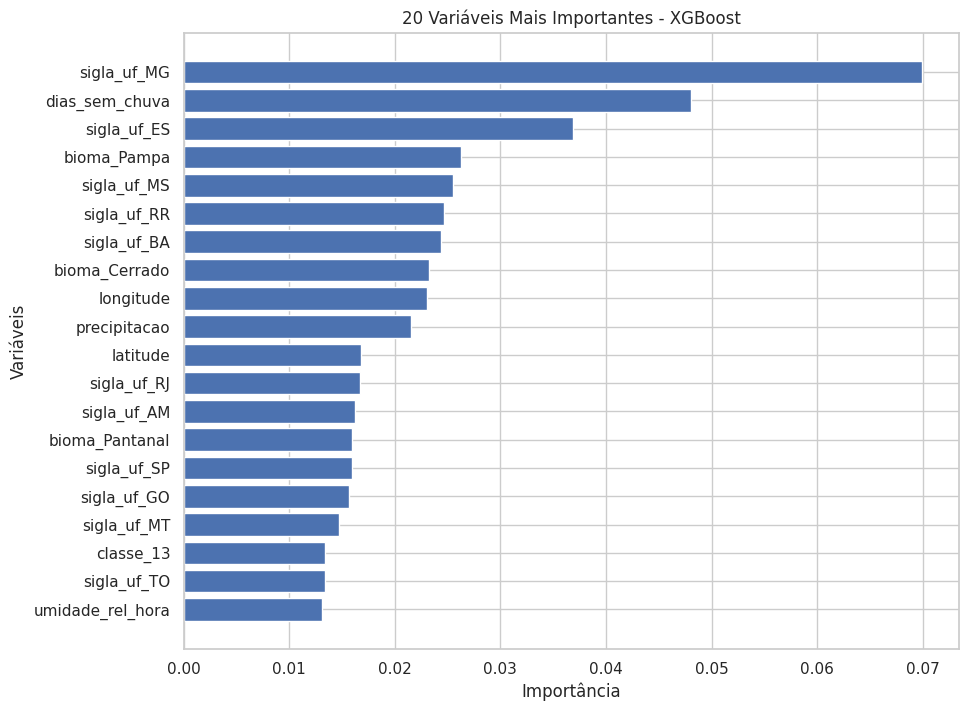

In [177]:
top20 = importancias.head(20)

plt.figure(figsize=(10,8))

plt.barh(
    top20["Variável"],
    top20["Importância"]
)

plt.xlabel("Importância")

plt.ylabel("Variáveis")

plt.title("20 Variáveis Mais Importantes - XGBoost")

plt.gca().invert_yaxis()

plt.show()

**Interpretação dos Resultados**

O gráfico apresenta as vinte variáveis que exerceram maior influência nas previsões do modelo XGBoost otimizado. Observa-se que fatores geográficos (como as variáveis de unidade da federação, latitude e longitude), meteorológicos (dias sem chuva, precipitação e umidade relativa do ar) e ambientais (biomas e classes de uso e cobertura do solo do MapBiomas) tiveram papel relevante na classificação do nível de risco de incêndios. Esses resultados são coerentes com a literatura, uma vez que a ocorrência de incêndios está diretamente relacionada às condições climáticas, à localização geográfica e às características da cobertura vegetal.

**Uma observação sobre sigla_uf**

Como foi aplicado One-Hot Encoding, cada estado passou a ser representado por uma variável binária independente. Dessa forma, o XGBoost conseguiu identificar que determinadas unidades da federação continham padrões relevantes para diferenciar os níveis de risco de incêndios. Isso não significa que esses estados sejam, isoladamente, os mais propensos a incêndios, mas que a localização geográfica contribuiu para melhorar a capacidade preditiva do modelo em conjunto com as demais variáveis.

### **16.3 Principais Variáveis Explicadas**



A análise da importância das variáveis mostrou que o modelo atribuiu maior relevância a atributos geográficos, meteorológicos e ambientais. Entre eles, destacaram-se a localização geográfica (representada pelas variáveis de unidade da federação, latitude e longitude), o número de dias sem chuva, a precipitação, a umidade relativa do ar e variáveis relacionadas aos biomas e ao uso do solo.

Esses resultados são coerentes com o problema de negócio, uma vez que a ocorrência de incêndios florestais depende diretamente das condições climáticas, da localização e das características da cobertura vegetal. Dessa forma, a importância atribuída pelo modelo às variáveis reforça sua capacidade de identificar padrões relevantes para a classificação do nível de risco de incêndios.

## **Conclusão da Etapa**

Nesta etapa foi realizada a interpretação do modelo XGBoost otimizado por meio da análise da importância das variáveis preditoras. Os resultados evidenciaram que fatores geográficos, meteorológicos e ambientais exerceram influência significativa na classificação do nível de risco de incêndios, destacando variáveis como dias sem chuva, precipitação, umidade relativa do ar, localização geográfica e características dos biomas.

A análise confirmou que a integração das diferentes bases de dados contribuiu para a construção de um modelo capaz de capturar padrões relevantes do fenômeno estudado. Além de apresentar bom desempenho preditivo, o modelo demonstrou ser interpretável, permitindo identificar os principais fatores associados ao risco de incêndios e fornecendo informações úteis para apoiar ações de monitoramento e prevenção.

## **17. Conclusão Geral**


O presente projeto teve como objetivo desenvolver um modelo de Machine Learning capaz de classificar o nível de risco de incêndios florestais a partir da integração de diferentes bases de dados ambientais, meteorológicas e geográficas.

Inicialmente, foi realizada a coleta, limpeza, tratamento e integração das bases de queimadas, dados meteorológicos, localização das estações e informações de uso e cobertura do solo provenientes do MapBiomas. Em seguida, foram conduzidas etapas de análise exploratória, engenharia de atributos, construção da variável-alvo e preparação dos dados para modelagem.

Foram avaliados diferentes algoritmos de classificação, incluindo Baseline, Regressão Logística, Random Forest, LightGBM e XGBoost. A comparação dos modelos demonstrou que os algoritmos baseados em árvores apresentaram desempenho superior ao modelo linear, sendo o XGBoost selecionado para a etapa de otimização dos hiperparâmetros.

Após a otimização por meio do RandomizedSearchCV, o modelo final alcançou **83,27% de acurácia** e **F1-score de 0,8116**, apresentando melhora consistente em relação ao modelo original. A análise da importância das variáveis evidenciou que fatores geográficos, meteorológicos e ambientais exerceram influência significativa nas previsões, confirmando a relevância da integração das diferentes fontes de dados.

De forma geral, os resultados demonstram que a utilização de técnicas de Machine Learning associadas à integração de múltiplas bases de dados constitui uma abordagem eficaz para a classificação do risco de incêndios, podendo contribuir para ações de monitoramento, planejamento e prevenção.


### **17.1 Limitações do Projeto**



Embora os resultados obtidos tenham sido satisfatórios, algumas limitações devem ser consideradas. A principal delas refere-se à disponibilidade temporal dos dados do MapBiomas, cuja versão utilizada possui informações até o ano de 2021, enquanto a base de queimadas corresponde ao ano de 2025. Para contornar essa diferença, foi utilizada a cobertura do solo mais recente disponível para todos os municípios.

Além disso, a classe "Médio" apresentou menor representatividade na base de dados, refletindo um maior grau de dificuldade para os modelos durante o processo de classificação. Apesar da melhora obtida após a otimização dos hiperparâmetros, essa classe permaneceu sendo o principal desafio do modelo.

### **17.2 Trabalhos Futuros**



Como trabalhos futuros, recomenda-se utilizar versões mais recentes da base MapBiomas, incorporar novas variáveis ambientais e meteorológicas, além de avaliar técnicas específicas para tratamento do desbalanceamento entre as classes, como métodos de reamostragem ou algoritmos especializados.

Também podem ser explorados outros modelos de Machine Learning e técnicas de interpretabilidade mais avançadas, como SHAP, permitindo compreender de forma ainda mais detalhada a influência de cada variável nas previsões do modelo.

### **17.3 Proposta de Validação em Ambiente Real (Teste A/B)**



Antes da adoção definitiva do modelo em ambiente de produção, recomenda-se a realização de um teste A/B para comparar o processo atual de classificação do risco de incêndios com o processo apoiado pelo modelo de Machine Learning desenvolvido neste projeto.

**Grupo A (Controle)**

Utilização do método atualmente empregado para monitoramento e classificação do risco de incêndios.

**Grupo B (Experimental)**

Utilização do modelo XGBoost otimizado como ferramenta de apoio à classificação do nível de risco.

**Indicadores de avaliação**

Durante o período de testes poderão ser monitorados indicadores como:

- acurácia das classificações realizadas;
- percentual de eventos corretamente identificados;
- tempo necessário para emissão das classificações;
- redução de falsos positivos e falsos negativos;
- estabilidade do modelo ao longo do tempo.

Ao término do período de avaliação, os resultados dos dois grupos deverão ser comparados para verificar se a utilização do modelo proporciona ganhos operacionais e melhoria na qualidade das previsões.